# Pre-processing the field data to traning data

## 1. Source Data: Vegetation Phytosociological

### 1.1 Load field data and coordinate them

In [13]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import re
import unicodedata
from difflib import SequenceMatcher

# -------------------------------------------------------------------
# INPUT PATHS
# -------------------------------------------------------------------

# 1. Load both shapefiles
old_input = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco"
    r"\Vegetation Cover and Food Availability Studies"
    r"\Vegetation Phytosociological Survey1015.shp"
)

new_input = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco"
    r"\Vegetation Cover and Food Availability Studies"
    r"\Phytosociological_habitat_Tamlelt_06102026.shp"
)


def resolve_shapefile(path):
    """Resolve a path that may be a .shp, shapefile basename, or folder."""
    
    if path.is_file():
        return path

    # Try adding .shp
    shp_version = path.with_suffix(".shp")
    if shp_version.is_file():
        return shp_version

    # If it is a folder, find shapefiles inside
    if path.is_dir():
        candidates = list(path.glob("*.shp"))

        if len(candidates) == 1:
            return candidates[0]

        elif len(candidates) > 1:
            print("Multiple shapefiles found:")
            for f in candidates:
                print("  ", f)
            raise ValueError("More than one shapefile found. Please choose one.")

    raise FileNotFoundError(f"Could not find shapefile: {path}")


old_path = resolve_shapefile(old_input)
new_path = resolve_shapefile(new_input)

print("OLD:", old_path)
print("NEW:", new_path)

old_gdf = gpd.read_file(old_path)
new_gdf = gpd.read_file(new_path)

print("\nLoaded successfully.")
print("Old records:", len(old_gdf))
print("New records:", len(new_gdf))

OLD: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Vegetation Phytosociological Survey1015.shp
NEW: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Phytosociological_habitat_Tamlelt_06102026.shp

Loaded successfully.
Old records: 1943
New records: 198


In [14]:
# 2. Inspect the two datasets

def inspect_gdf(gdf, name):
    print("=" * 80)
    print(name)
    print("=" * 80)

    print("Number of records:", len(gdf))
    print("CRS:", gdf.crs)
    print("Geometry types:")
    print(gdf.geometry.geom_type.value_counts(dropna=False))

    rows = []

    for col in gdf.columns:
        if col == gdf.geometry.name:
            continue

        s = gdf[col]

        samples = (
            s.dropna()
             .astype(str)
             .drop_duplicates()
             .head(5)
             .tolist()
        )

        rows.append({
            "field": col,
            "dtype": str(s.dtype),
            "missing": s.isna().sum(),
            "missing_%": round(s.isna().mean() * 100, 1),
            "unique": s.nunique(dropna=True),
            "sample_values": " | ".join(samples)
        })

    return pd.DataFrame(rows)


old_summary = inspect_gdf(old_gdf, "PREVIOUS-YEAR DATA")
display(old_summary)

new_summary = inspect_gdf(new_gdf, "2026 DATA")
display(new_summary)

PREVIOUS-YEAR DATA
Number of records: 1943
CRS: EPSG:4326
Geometry types:
Point    1943
Name: count, dtype: int64


,field,dtype,missing,missing_%,unique,sample_values
0,Station_ID,int64,0,0.0,1941,34883 | 100281 | 176637 | 74289 | 81553
1,Station_Na,object,0,0.0,1670,Maille 78SE | XA28NW4 | Maille 09NW | Maille 7...
2,Station_Da,object,0,0.0,310,12-Mar-08 | 21-Apr-15 | 17-Mar-09 | 3-Mar-08 |...
3,Latitude,float64,0,0.0,1923,32.3816 | 32.41656 | 32.50987 | 32.27989 | 33....
4,Longitude,float64,0,0.0,1931,-2.18346 | -1.7133 | -1.91196 | -2.2131 | -2.2...
5,Elevation,int64,0,0.0,921,1051 | 1212 | 1134 | 1039 | 1064
6,Precision,int64,0,0.0,10,5 | 10 | 1 | 0 | 14
7,Area_M2,int64,0,0.0,54,120 | 150 | 160 | 200 | 250
8,Exposure,object,518,26.7,11,No | None | NW | W | N
9,Slope_Clas,object,998,51.4,5,"[0;0,5°] | [0,5°;6°] | [6°;27°] | [27°;45°] | ..."


2026 DATA
Number of records: 198
CRS: EPSG:4326
Geometry types:
Point    198
Name: count, dtype: int64


,field,dtype,missing,missing_%,unique,sample_values
0,Station_ID,object,0,0.0,3,"No phytosociology relevé, only field observati..."
1,Station_Na,object,137,69.2,61,WA69NW6 | WA69NW1 | WC07NW2 | WC17NW1 | XA08NW2
2,Latitude,float64,0,0.0,197,32.44596 | 32.53156 | 32.52737 | 32.52411 | 32...
3,Longitude,float64,0,0.0,195,-2.5685 | -2.61676 | -2.58446 | -2.53548 | -2....
4,Area_M2,object,137,69.2,21,1500 | 750 | 2000 | 3500 | 7500
5,Exposure,object,137,69.2,11,- | E | Multi | SE | S
6,Slope_Clas,object,138,69.7,17,0 | 3 | 1 | NC | <1
7,Habitat,object,0,0.0,16,Cultivated field | Cultivated field (olive tre...
8,class,object,0,0.0,10,Cultivated field/fallow | Water body | Dune | ...
9,Habitat_Pi,object,137,69.2,3,N | O | Y


In [15]:
# print("PREVIOUS DATA")
# display(old_gdf.drop(columns="geometry").head(10))

# print("\n2026 DATA")
# display(new_gdf.drop(columns="geometry").head(10))

print("Historical class categories:")
print(
    old_gdf["class"]
    .value_counts(dropna=False)
    .to_string()
)

print("\n" + "=" * 70)

print("2026 class categories:")
print(
    new_gdf["class"]
    .value_counts(dropna=False)
    .to_string()
)


Historical class categories:
class
Grass steppe               593
Shrub steppe               531
Cultivated field/fallow    368
Wadi and gullies           366
Water body                  31
Dune                        31
Salty steppe                23

2026 class categories:
class
Grass steppe               45
Water body                 44
Shrub steppe               33
Cultivated field/fallow    20
Wadi and gullies           18
Salty steppe               13
Spreading area             12
Dune                        8
Bare rocky                  3
Open woodland               2


In [16]:
class_order = [
    "Grass steppe",
    "Shrub steppe",
    "Open woodland",
    "Salty steppe",
    "Spreading area",
    "Bare rocky",
    "Dune",
    "Wadi and gullies",
    "Cultivated field/fallow",
    "Water body"
]

In [17]:
def clean_class(series):
    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

old_gdf["class"] = clean_class(old_gdf["class"])
new_gdf["class"] = clean_class(new_gdf["class"])

In [18]:
class_map = {
    "Grass Steppe": "Grass steppe",
    "Shrub Steppe": "Shrub steppe",
    "Cultivated field / fallow": "Cultivated field/fallow",
    "Cultivated field/fallow": "Cultivated field/fallow",
    "Wadi & gullies": "Wadi and gullies",
    "Wadi and Gullies": "Wadi and gullies",
    "Water Body": "Water body",
    "Bare Rocky": "Bare rocky",
    "Open Woodland": "Open woodland",
    "Spreading Area": "Spreading area",
    "Salty Steppe": "Salty steppe"
}

old_gdf["class"] = old_gdf["class"].replace(class_map)
new_gdf["class"] = new_gdf["class"].replace(class_map)

In [19]:
print("Historical:")
print(old_gdf["class"].value_counts(dropna=False))

print("\n2026:")
print(new_gdf["class"].value_counts(dropna=False))

Historical:
class
Grass steppe               593
Shrub steppe               531
Cultivated field/fallow    368
Wadi and gullies           366
Water body                  31
Dune                        31
Salty steppe                23
Name: count, dtype: Int64

2026:
class
Grass steppe               45
Water body                 44
Shrub steppe               33
Cultivated field/fallow    20
Wadi and gullies           18
Salty steppe               13
Spreading area             12
Dune                        8
Bare rocky                  3
Open woodland               2
Name: count, dtype: Int64


In [21]:
# 3. Select only the fields we ultimately need
old_keep = [
    "Station_ID",
    "Station_Na",
    "Latitude",
    "Longitude",
    "Area_M2",
    "Exposure",
    "Slope_Clas",
    "Habitat_2_",
    "class",
    "geometry"
]

new_keep = [
    "Station_ID",
    "Station_Na",
    "Latitude",
    "Longitude",
    "Area_M2",
    "Exposure",
    "Slope_Clas",
    "class",
    "geometry"
]

old_clean = old_gdf[old_keep].copy()
new_clean = new_gdf[new_keep].copy()

In [22]:
new_phyto = new_clean[
    new_clean["Station_Na"].notna()
    & new_clean["Area_M2"].notna()
].copy()

print("All 2026 points:", len(new_clean))
print("2026 phytosociological relevés:", len(new_phyto))
print(
    "Other habitat/field observations:",
    len(new_clean) - len(new_phyto)
)

All 2026 points: 198
2026 phytosociological relevés: 61
Other habitat/field observations: 137


In [24]:
old_clean["Station_ID"] = (
    old_clean["Station_ID"]
    .astype("Int64")
    .astype(str)
)

new_phyto = new_phyto.reset_index(drop=True)

new_phyto["Station_ID"] = [
    f"2026_{i:03d}"
    for i in range(1, len(new_phyto) + 1)
]

In [33]:
len(new_clean)

198

In [35]:
old_clean["Area_M2"] = pd.to_numeric(
    old_clean["Area_M2"],
    errors="coerce"
)

new_clean["Area_M2"] = pd.to_numeric(
    new_clean["Area_M2"],
    errors="coerce"
)
print(len(new_clean))
print(old_clean["Area_M2"].describe())
print(new_clean["Area_M2"].describe())

198
count     1943.000000
mean      2765.347401
std       2334.307733
min        120.000000
25%       1253.000000
50%       2000.000000
75%       3500.000000
max      20000.000000
Name: Area_M2, dtype: float64
count      48.000000
mean     1808.333333
std      1421.325922
min       750.000000
25%      1000.000000
50%      1500.000000
75%      2000.000000
max      7500.000000
Name: Area_M2, dtype: float64


In [36]:
def clean_exposure(series):

    s = (
        series
        .astype("string")
        .str.strip()
        .str.upper()
    )

    replacements = {
        "-": pd.NA,
        "NAN": pd.NA,
        "NONE": pd.NA,
        "NULL": pd.NA
    }

    return s.replace(replacements)


old_clean["Exposure"] = clean_exposure(
    old_clean["Exposure"]
)

new_clean["Exposure"] = clean_exposure(
    new_clean["Exposure"]
)

print("Historical Exposure:")
print(old_clean["Exposure"].value_counts(dropna=False))

print("\n2026 Exposure:")
print(new_clean["Exposure"].value_counts(dropna=False))

Historical Exposure:
Exposure
<NA>       852
NO         261
S          168
N          130
W          112
E          108
SE          81
NE          80
NW          68
SW          60
SEVERAL     23
Name: count, dtype: Int64

2026 Exposure:
Exposure
<NA>     154
N         10
E          9
S          7
NE         6
MULTI      3
SE         3
NW         3
W          2
SW         1
Name: count, dtype: Int64


In [37]:
print("Historical slope classes:")
print(
    old_clean["Slope_Clas"]
    .value_counts(dropna=False)
    .to_string()
)

print("\n2026 slope values:")
print(
    new_clean["Slope_Clas"]
    .value_counts(dropna=False)
    .to_string()
)

Historical slope classes:
Slope_Clas
NaN          998
[0,5°;6°]    687
[0;0,5°]     159
[6°;27°]      64
[27°;45°]     32
[45°;70°]      3

2026 slope values:
Slope_Clas
NaN    138
0       17
1       12
3        7
15       3
8        3
12       2
4        2
9        2
40       2
<1       2
2        2
5        1
30       1
7        1
NC       1
25       1
10       1


In [39]:
final_fields = [
    "Station_ID",
    "Station_Na",
    "Latitude",
    "Longitude",
    "Area_M2",
    "Exposure",
    "Slope_Clas",
    "class",
    "geometry"
]

old_final = old_clean[final_fields].copy()
new_final = new_clean[final_fields].copy()

print(len(old_final))
print(len(new_final))

1943
198


In [40]:
# Then merge

merged = gpd.GeoDataFrame(
    pd.concat(
        [old_final, new_final],
        ignore_index=True
    ),
    geometry="geometry",
    crs=old_final.crs
)

print("Historical:", len(old_final))
print("2026:", len(new_final))
print("Merged:", len(merged))

Historical: 1943
2026: 198
Merged: 2141


In [41]:
output_dir = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco"
    r"\Vegetation Cover and Food Availability Studies"
)

output_shp = output_dir / "Phytosociological_Survey_Merged_2008_2026.shp"

merged.to_file(output_shp)

print("Shapefile saved:")
print(output_shp)

Shapefile saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Phytosociological_Survey_Merged_2008_2026.shp


In [42]:
# Class distribution
class_counts = (
    merged["class"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="n")
)

class_counts["percent"] = (
    class_counts["n"] / len(merged) * 100
).round(2)

display(class_counts)

,class,n,percent
0,Grass steppe,638,29.8
1,Shrub steppe,564,26.34
2,Cultivated field/fallow,388,18.12
3,Wadi and gullies,384,17.94
4,Water body,75,3.5
5,Dune,39,1.82
6,Salty steppe,36,1.68
7,Spreading area,12,0.56
8,Bare rocky,3,0.14
9,Open woodland,2,0.09


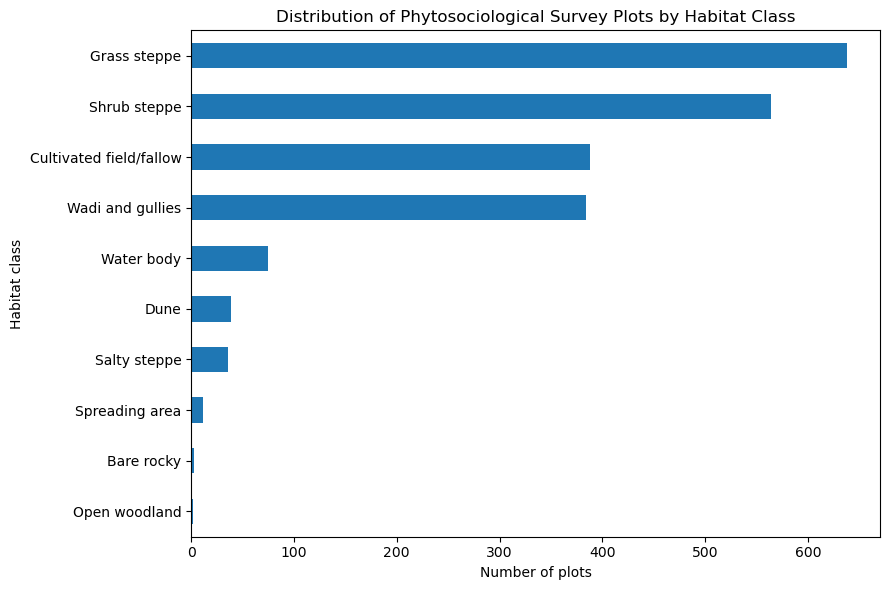

In [44]:
import matplotlib.pyplot as plt

plot_data = (
    merged["class"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))

plot_data.plot(kind="barh")

plt.xlabel("Number of plots")
plt.ylabel("Habitat class")
plt.title("Distribution of Phytosociological Survey Plots by Habitat Class")

plt.tight_layout()
plt.show()

In [45]:
area_numeric = pd.to_numeric(
    merged["Area_M2"],
    errors="coerce"
)

print(area_numeric.describe())

count     1991.000000
mean      2742.275239
std       2320.954758
min        120.000000
25%       1250.000000
50%       2000.000000
75%       3200.000000
max      20000.000000
Name: Area_M2, dtype: float64


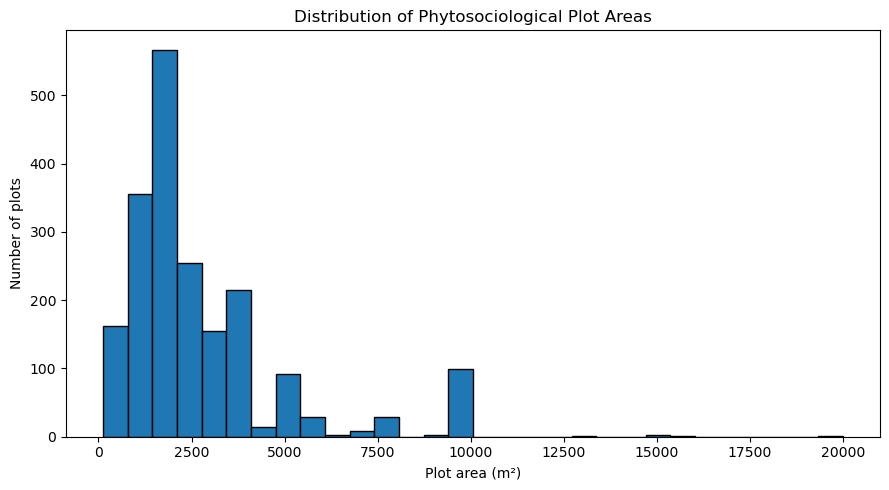

In [46]:
plt.figure(figsize=(9, 5))

plt.hist(
    area_numeric.dropna(),
    bins=30,
    edgecolor="black"
)

plt.xlabel("Plot area (m²)")
plt.ylabel("Number of plots")
plt.title("Distribution of Phytosociological Plot Areas")

plt.tight_layout()
plt.show()

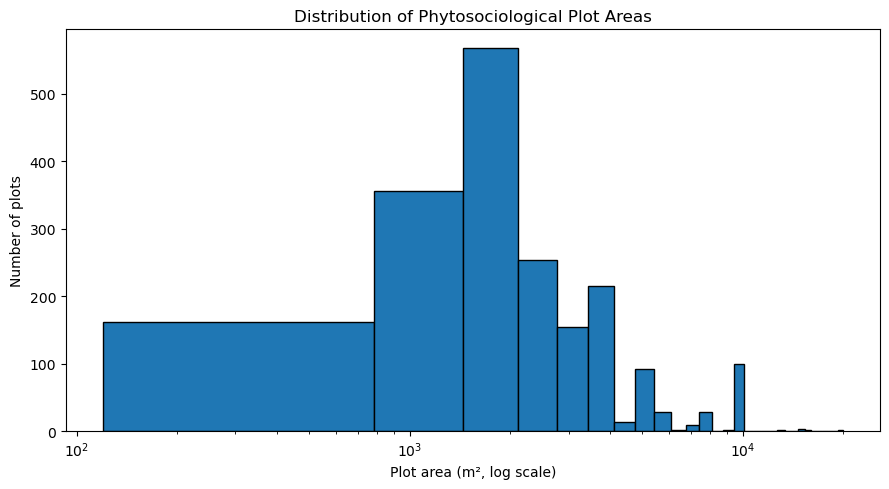

In [47]:
area_positive = area_numeric[
    area_numeric > 0
]

plt.figure(figsize=(9, 5))

plt.hist(
    area_positive,
    bins=30,
    edgecolor="black"
)

plt.xscale("log")

plt.xlabel("Plot area (m², log scale)")
plt.ylabel("Number of plots")
plt.title("Distribution of Phytosociological Plot Areas")

plt.tight_layout()
plt.show()

In [ ]:
# Explore the Class distributions
# 1 class sample-size distribution;
# 2 plot-area and equivalent-radius distributions;
# 3 plot area by habitat class;
# 4 spatial distribution map by habitat class.

,class,n,percent
0,Grass steppe,638,29.8
1,Shrub steppe,564,26.3
2,Cultivated field/fallow,388,18.1
3,Wadi and gullies,384,17.9
4,Water body,75,3.5
5,Dune,39,1.8
6,Salty steppe,36,1.7
7,Spreading area,12,0.6
8,Bare rocky,3,0.1
9,Open woodland,2,0.1


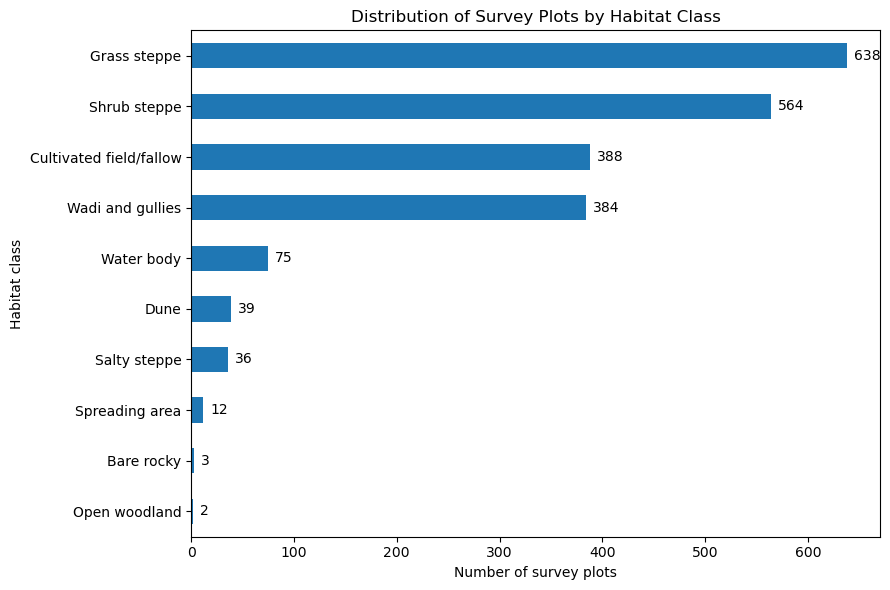

In [48]:
# 1. Class balance
import pandas as pd
import matplotlib.pyplot as plt

class_counts = (
    merged["class"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="n")
)

class_counts["percent"] = (
    class_counts["n"] / len(merged) * 100
).round(1)

display(class_counts)

plot_data = (
    merged["class"]
    .value_counts()
    .sort_values()
)

ax = plot_data.plot(
    kind="barh",
    figsize=(9, 6)
)

ax.set_xlabel("Number of survey plots")
ax.set_ylabel("Habitat class")
ax.set_title("Distribution of Survey Plots by Habitat Class")

# Add count labels
for i, value in enumerate(plot_data):
    ax.text(
        value + max(plot_data) * 0.01,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()
plt.show()

Valid area records: 1991
Missing area records: 150


count     1991.000000
mean      2742.275239
std       2320.954758
min        120.000000
5%         600.000000
10%        900.000000
25%       1250.000000
50%       2000.000000
75%       3200.000000
90%       5000.000000
95%      10000.000000
max      20000.000000
Name: Area_M2, dtype: float64

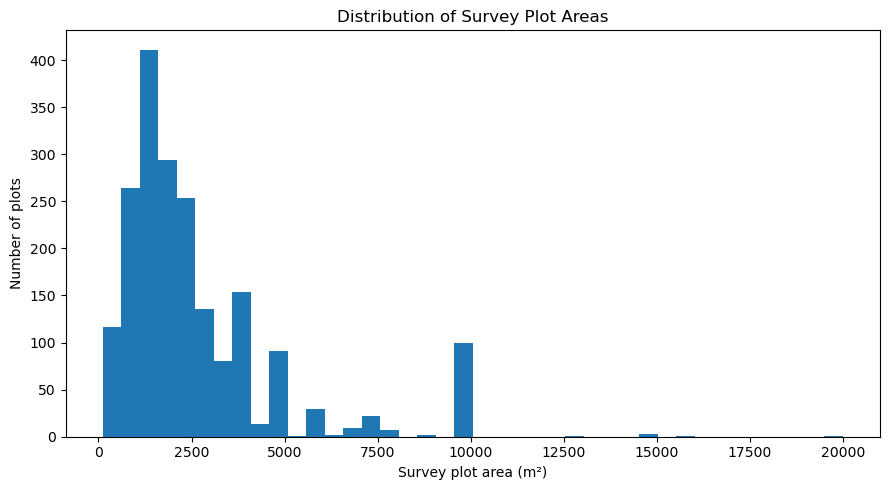

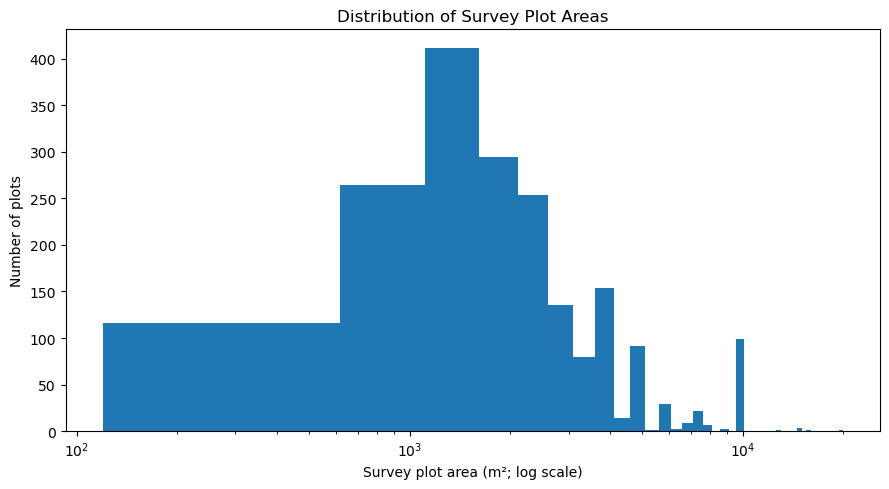

In [49]:
# 2. Analyze plot area
area = pd.to_numeric(
    merged["Area_M2"],
    errors="coerce"
)

print("Valid area records:", area.notna().sum())
print("Missing area records:", area.isna().sum())

display(area.describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
))

plt.figure(figsize=(9, 5))

plt.hist(
    area.dropna(),
    bins=40
)

plt.xlabel("Survey plot area (m²)")
plt.ylabel("Number of plots")
plt.title("Distribution of Survey Plot Areas")

plt.tight_layout()
plt.show()

area_positive = area[area > 0]

plt.figure(figsize=(9, 5))

plt.hist(
    area_positive,
    bins=40
)

plt.xscale("log")

plt.xlabel("Survey plot area (m²; log scale)")
plt.ylabel("Number of plots")
plt.title("Distribution of Survey Plot Areas")

plt.tight_layout()
plt.show()

count    1991.000000
mean       27.535738
std        10.711400
min         6.180387
5%         13.819766
10%        16.925688
25%        19.947114
50%        25.231325
75%        31.915382
90%        39.894228
95%        56.418958
max        79.788456
Name: EqRadius_m, dtype: float64

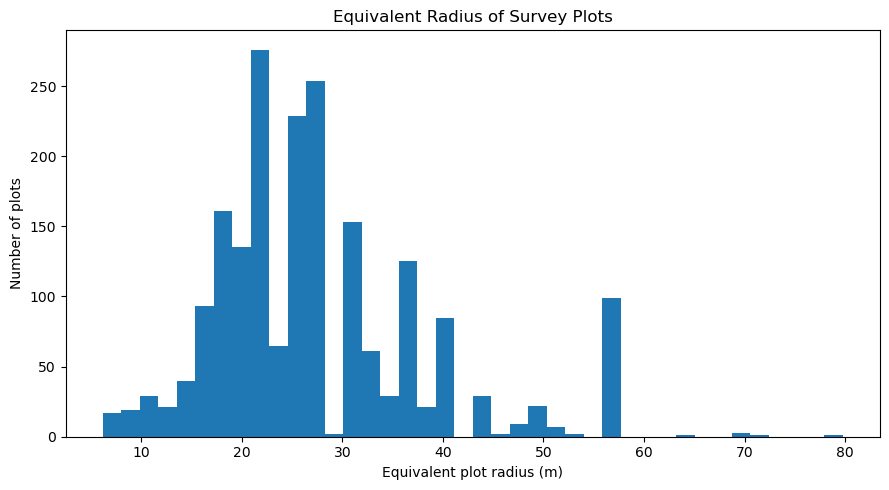

In [50]:
# 3. Calculate equivalent plot radius
import numpy as np

merged_analysis = merged.copy()

merged_analysis["Area_numeric"] = pd.to_numeric(
    merged_analysis["Area_M2"],
    errors="coerce"
)

merged_analysis["EqRadius_m"] = np.sqrt(
    merged_analysis["Area_numeric"] / np.pi
)

display(
    merged_analysis["EqRadius_m"].describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)

plt.figure(figsize=(9, 5))

plt.hist(
    merged_analysis["EqRadius_m"].dropna(),
    bins=40
)

plt.xlabel("Equivalent plot radius (m)")
plt.ylabel("Number of plots")
plt.title("Equivalent Radius of Survey Plots")

plt.tight_layout()
plt.show()

,n,median,mean,minimum,maximum
class,,,,,
Bare rocky,1,750.0,750.0,750.0,750.0
Salty steppe,23,800.0,1213.5,160.0,5000.0
Dune,32,1500.0,1759.4,200.0,5000.0
Spreading area,1,1500.0,1500.0,1500.0,1500.0
Water body,32,1550.0,2316.9,120.0,10000.0
Open woodland,2,1750.0,1750.0,1500.0,2000.0
Cultivated field/fallow,379,2000.0,2840.0,400.0,20000.0
Grass steppe,607,2000.0,2523.6,120.0,15000.0
Shrub steppe,546,2000.0,2941.1,200.0,10000.0


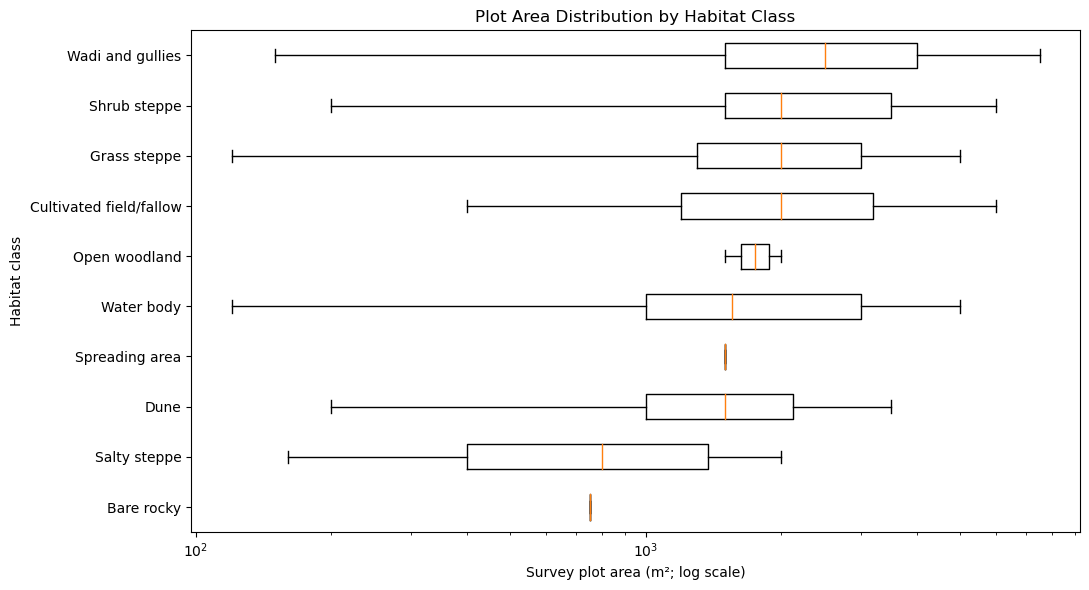

In [51]:
# 4. Area distribution by habitat class
area_by_class = (
    merged_analysis[
        merged_analysis["Area_numeric"].notna()
        & (merged_analysis["Area_numeric"] > 0)
    ]
    .groupby("class")["Area_numeric"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        minimum="min",
        maximum="max"
    )
    .sort_values("median")
)

display(area_by_class.round(1))

classes = (
    area_by_class
    .sort_values("median")
    .index
    .tolist()
)

data = [
    merged_analysis.loc[
        (merged_analysis["class"] == c)
        & (merged_analysis["Area_numeric"] > 0),
        "Area_numeric"
    ].dropna().values
    for c in classes
]

plt.figure(figsize=(11, 6))

plt.boxplot(
    data,
    labels=classes,
    vert=False,
    showfliers=False
)

plt.xscale("log")

plt.xlabel("Survey plot area (m²; log scale)")
plt.ylabel("Habitat class")
plt.title("Plot Area Distribution by Habitat Class")

plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


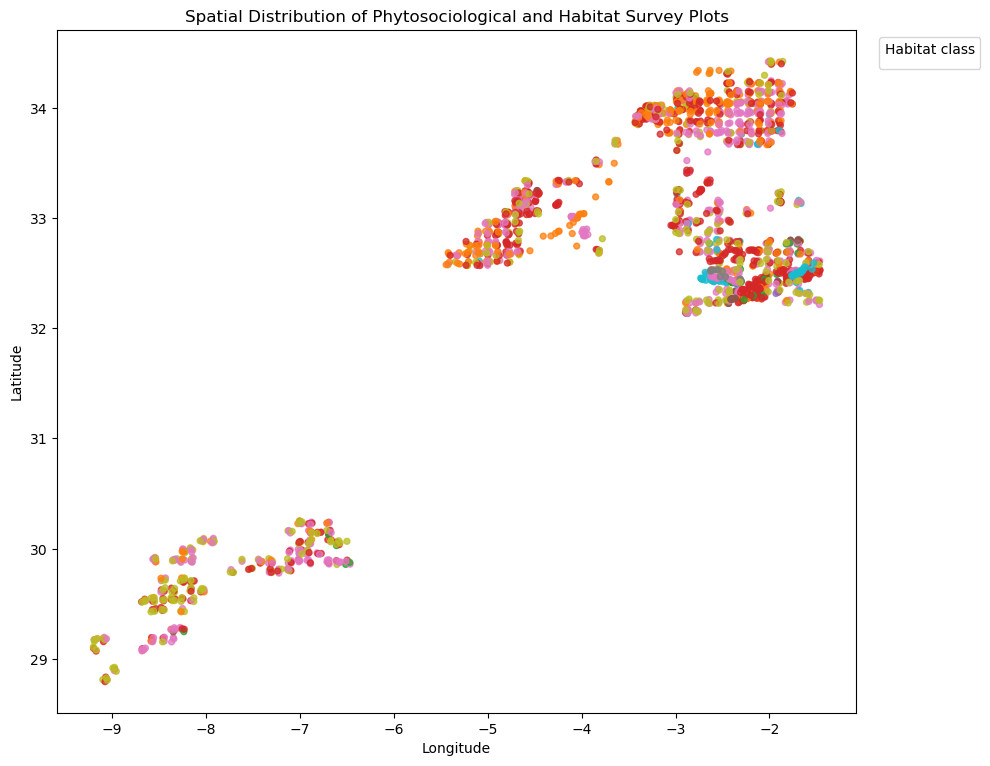

In [52]:
# 5. Spatial distribution map
fig, ax = plt.subplots(figsize=(10, 9))

merged.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=18,
    alpha=0.75
)

ax.set_title(
    "Spatial Distribution of Phytosociological and Habitat Survey Plots"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend(
    title="Habitat class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

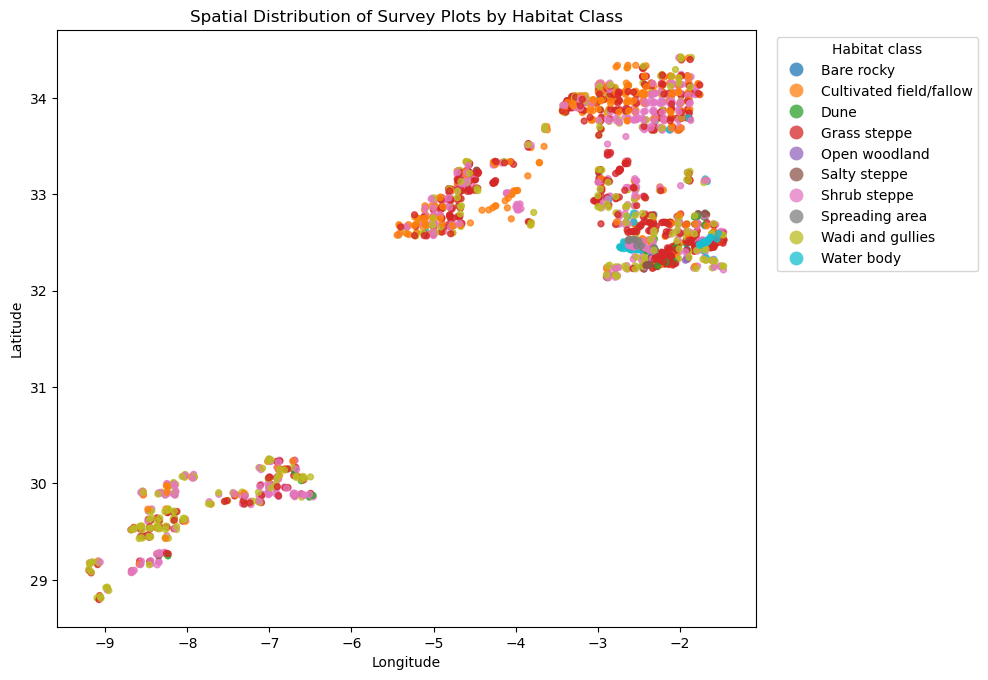

In [53]:
fig, ax = plt.subplots(figsize=(10, 9))

merged.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=18,
    alpha=0.75,
    legend_kwds={
        "title": "Habitat class",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Spatial Distribution of Survey Plots by Habitat Class"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

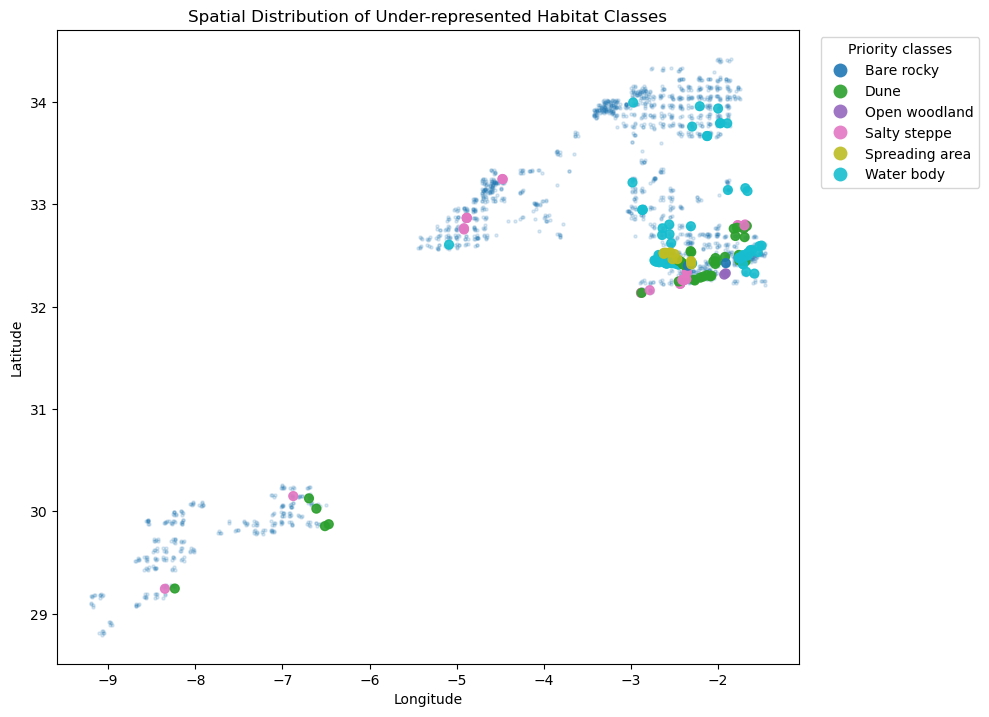

In [54]:
# Make a separate map for the rare classes
rare_classes = [
    "Open woodland",
    "Bare rocky",
    "Spreading area",
    "Salty steppe",
    "Dune",
    "Water body"
]

rare = merged[
    merged["class"].isin(rare_classes)
].copy()

fig, ax = plt.subplots(figsize=(10, 9))

# All observations in background
merged.plot(
    ax=ax,
    markersize=5,
    alpha=0.15
)

# Rare classes emphasized
rare.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=40,
    alpha=0.9,
    legend_kwds={
        "title": "Priority classes",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Spatial Distribution of Under-represented Habitat Classes"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [55]:
# calculate spatial spread numerically
spatial_summary = (
    merged
    .dropna(subset=["class"])
    .groupby("class")
    .agg(
        n=("class", "size"),
        min_lon=("Longitude", "min"),
        max_lon=("Longitude", "max"),
        min_lat=("Latitude", "min"),
        max_lat=("Latitude", "max")
    )
)

spatial_summary["lon_range"] = (
    spatial_summary["max_lon"]
    - spatial_summary["min_lon"]
)

spatial_summary["lat_range"] = (
    spatial_summary["max_lat"]
    - spatial_summary["min_lat"]
)

display(
    spatial_summary.sort_values("n")
)

,n,min_lon,max_lon,min_lat,max_lat,lon_range,lat_range
class,,,,,,,
Open woodland,2,-1.93021,-1.91263,32.31430,32.32704,0.01758,0.01274
Bare rocky,3,-2.34782,-1.91140,32.40133,32.42693,0.43642,0.02560
Spreading area,12,-2.62477,-2.30875,32.41419,32.52951,0.31602,0.11532
Salty steppe,36,-8.34942,-1.69026,29.24385,33.24879,6.65916,4.00494
Dune,39,-8.23597,-1.67088,29.24642,32.78990,6.56509,3.54348
Water body,75,-5.08866,-1.50188,32.32409,33.99611,3.58678,1.67202
Wadi and gullies,384,-9.20049,-1.46456,28.80747,34.42340,7.73593,5.61593
Cultivated field/fallow,388,-9.09849,-1.49979,29.07540,34.42340,7.59870,5.34800
Shrub steppe,564,-9.19276,-1.46386,28.89310,34.41509,7.72890,5.52199


In [56]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

eastern_path = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
    r"\Morocco two study areas\Eastern_Morocco_Working_Area.shp"
)

tata_path = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
    r"\Morocco two study areas\Tata_Morocco_Working_Area.shp"
)

eastern_boundary = gpd.read_file(eastern_path)
tata_boundary = gpd.read_file(tata_path)

print("Eastern Morocco CRS:", eastern_boundary.crs)
print("Tata CRS:", tata_boundary.crs)
print("Merged points CRS:", merged.crs)

Eastern Morocco CRS: EPSG:4326
Tata CRS: EPSG:4326
Merged points CRS: EPSG:4326


In [57]:
# Reproject points to Eastern Morocco boundary CRS
merged_em_crs = merged.to_crs(eastern_boundary.crs)

# Keep points intersecting the Eastern Morocco study area
eastern_points = gpd.sjoin(
    merged_em_crs,
    eastern_boundary[["geometry"]],
    how="inner",
    predicate="intersects"
)

# Remove spatial-join helper field
eastern_points = eastern_points.drop(
    columns=["index_right"],
    errors="ignore"
)

# Prevent duplicate points if boundary consists of overlapping polygons
eastern_points = eastern_points[
    ~eastern_points.index.duplicated(keep="first")
].copy()

print("All merged records:", len(merged))
print("Eastern Morocco records:", len(eastern_points))
print("Outside Eastern Morocco:", len(merged) - len(eastern_points))

All merged records: 2141
Eastern Morocco records: 1394
Outside Eastern Morocco: 747


In [58]:
em_class_counts = (
    eastern_points["class"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="n")
)

em_class_counts["percent"] = (
    em_class_counts["n"] /
    len(eastern_points) * 100
).round(1)

display(em_class_counts)

,class,n,percent
0,Grass steppe,463,33.2
1,Shrub steppe,345,24.7
2,Cultivated field/fallow,223,16.0
3,Wadi and gullies,204,14.6
4,Water body,74,5.3
5,Salty steppe,34,2.4
6,Dune,34,2.4
7,Spreading area,12,0.9
8,Bare rocky,3,0.2
9,Open woodland,2,0.1


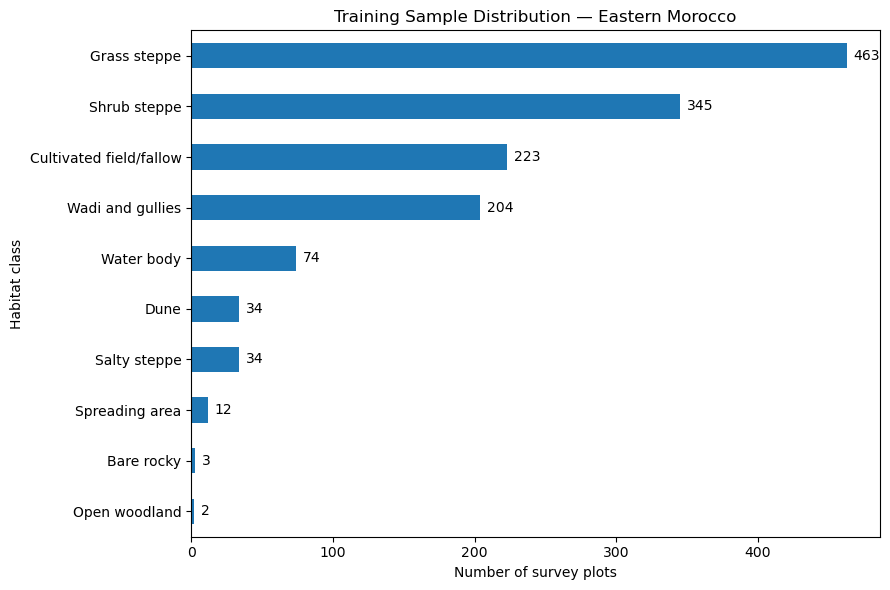

In [59]:
plot_data = (
    eastern_points["class"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))

plot_data.plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Number of survey plots")
ax.set_ylabel("Habitat class")
ax.set_title(
    "Training Sample Distribution — Eastern Morocco"
)

for i, n in enumerate(plot_data):
    ax.text(
        n + plot_data.max() * 0.01,
        i,
        str(n),
        va="center"
    )

plt.tight_layout()
plt.show()

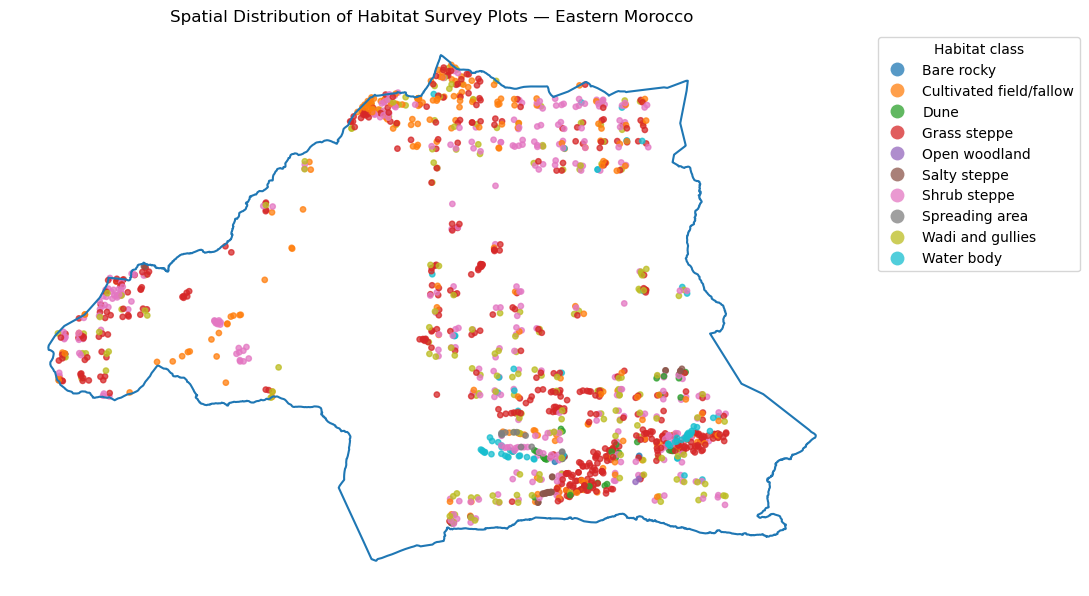

In [60]:
# Map Eastern Morocco alone
fig, ax = plt.subplots(figsize=(11, 9))

# Study-area boundary
eastern_boundary.boundary.plot(
    ax=ax,
    linewidth=1.5
)

# Survey points
eastern_points.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=15,
    alpha=0.75,
    legend_kwds={
        "title": "Habitat class",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Spatial Distribution of Habitat Survey Plots — Eastern Morocco"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [61]:
# Make the important rare-class map
priority_classes = [
    "Open woodland",
    "Bare rocky",
    "Spreading area",
    "Salty steppe",
    "Dune",
    "Water body"
]

em_priority = eastern_points[
    eastern_points["class"].isin(priority_classes)
].copy()

print(
    em_priority["class"]
    .value_counts()
)

class
Water body        74
Salty steppe      34
Dune              34
Spreading area    12
Bare rocky         3
Open woodland      2
Name: count, dtype: Int64


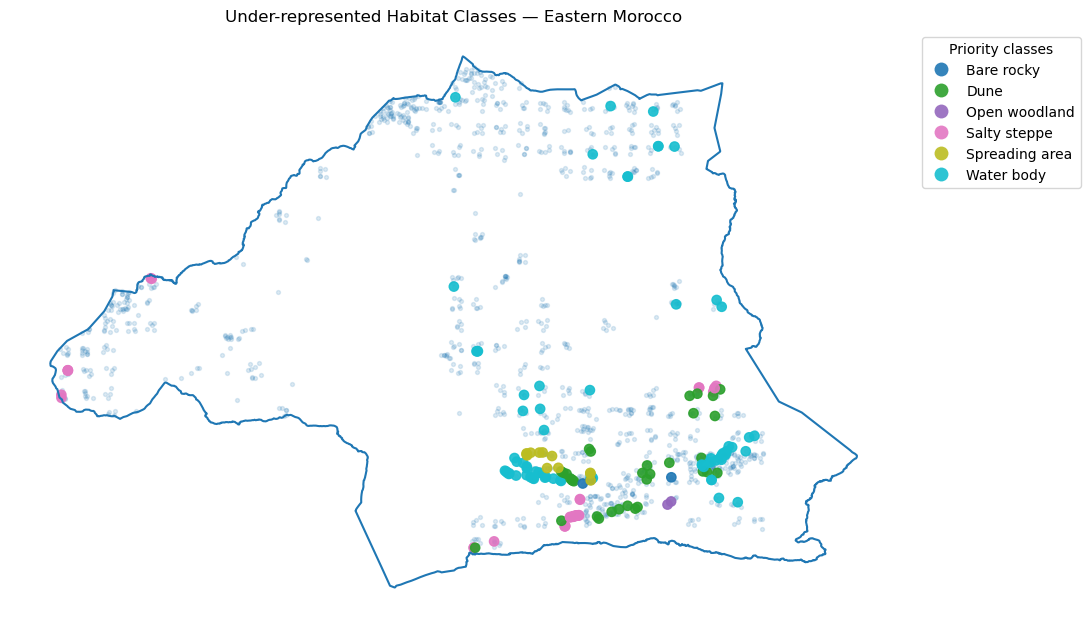

In [62]:
fig, ax = plt.subplots(figsize=(11, 9))

# Boundary
eastern_boundary.boundary.plot(
    ax=ax,
    linewidth=1.5
)

# All plots as faint background
eastern_points.plot(
    ax=ax,
    markersize=8,
    alpha=0.15
)

# Priority classes
em_priority.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=45,
    alpha=0.9,
    legend_kwds={
        "title": "Priority classes",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Under-represented Habitat Classes — Eastern Morocco"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [63]:
old_for_merge = old_clean.copy()
new_for_merge = new_clean.copy()

old_for_merge["Dataset"] = "Historical"
new_for_merge["Dataset"] = "2026"

merged_source = gpd.GeoDataFrame(
    pd.concat(
        [old_for_merge, new_for_merge],
        ignore_index=True,
        sort=False
    ),
    geometry="geometry",
    crs=old_for_merge.crs
)

merged_source_em = merged_source.to_crs(
    eastern_boundary.crs
)

eastern_source = gpd.sjoin(
    merged_source_em,
    eastern_boundary[["geometry"]],
    how="inner",
    predicate="intersects"
).drop(
    columns="index_right",
    errors="ignore"
)

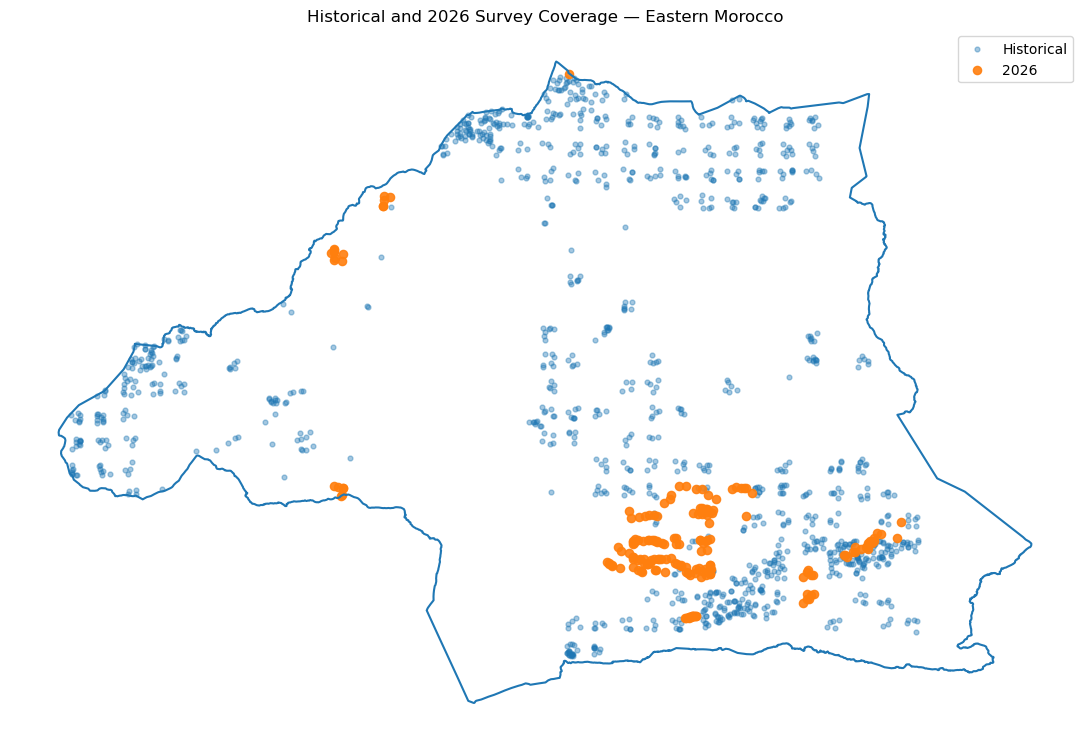

In [64]:
fig, ax = plt.subplots(figsize=(11, 9))

eastern_boundary.boundary.plot(
    ax=ax,
    linewidth=1.5
)

eastern_source[
    eastern_source["Dataset"] == "Historical"
].plot(
    ax=ax,
    markersize=12,
    alpha=0.4,
    label="Historical"
)

eastern_source[
    eastern_source["Dataset"] == "2026"
].plot(
    ax=ax,
    markersize=35,
    alpha=0.9,
    label="2026"
)

ax.legend()
ax.set_title(
    "Historical and 2026 Survey Coverage — Eastern Morocco"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [65]:
# Plot-area statistics for Eastern Morocco only
eastern_points["Area_numeric"] = pd.to_numeric(
    eastern_points["Area_M2"],
    errors="coerce"
)

display(
    eastern_points["Area_numeric"].describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)

em_area_summary = (
    eastern_points[
        eastern_points["Area_numeric"] > 0
    ]
    .groupby("class")["Area_numeric"]
    .agg(
        n_area="count",
        median_area="median",
        mean_area="mean",
        min_area="min",
        max_area="max"
    )
    .sort_values("median_area")
)

display(em_area_summary.round(1))

count     1246.000000
mean      2798.410915
std       2563.257893
min        120.000000
5%         500.000000
10%        750.000000
25%       1250.000000
50%       2000.000000
75%       3200.000000
90%       6000.000000
95%      10000.000000
max      16000.000000
Name: Area_numeric, dtype: float64

,n_area,median_area,mean_area,min_area,max_area
class,,,,,
Bare rocky,1,750.0,750.0,750.0,750.0
Salty steppe,21,750.0,1091.0,160.0,5000.0
Dune,27,1500.0,1566.7,200.0,5000.0
Spreading area,1,1500.0,1500.0,1500.0,1500.0
Water body,31,1600.0,2359.4,120.0,10000.0
Open woodland,2,1750.0,1750.0,1500.0,2000.0
Cultivated field/fallow,214,2000.0,3023.4,400.0,12800.0
Grass steppe,432,2000.0,2553.2,120.0,15000.0
Shrub steppe,327,2000.0,3191.7,200.0,10000.0


In [69]:
# eastern_points.head

In [68]:
for col in eastern_points.columns:
    if len(col) > 10:
        print(col, len(col))

Area_numeric 12


In [70]:
final_fields = [
    "Station_ID",
    "Station_Na",
    "Latitude",
    "Longitude",
    "Area_M2",
    "Exposure",
    "Slope_Clas",
    "class",
    "geometry"
]

eastern_final = eastern_points[final_fields].copy()

from pathlib import Path

output_em = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
    r"\Reneco\Vegetation Cover and Food Availability Studies"
    r"\Phytosociological_Survey_Eastern_Morocco_2008_2026.shp"
)

eastern_final.to_file(output_em)

print("Saved:")
print(output_em)
print("Records:", len(eastern_final))
print("Fields:", eastern_final.columns.tolist())

Saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Phytosociological_Survey_Eastern_Morocco_2008_2026.shp
Records: 1394
Fields: ['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'geometry']


In [71]:
output_gpkg = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
    r"\Reneco\Vegetation Cover and Food Availability Studies"
    r"\Phytosociological_Survey_Eastern_Morocco_2008_2026.gpkg"
)

eastern_points.to_file(
    output_gpkg,
    layer="Eastern_Morocco",
    driver="GPKG"
)

### 1.2 Creating supplymentary plots: field-plot footprint attach to Google Earth

In [73]:
import numpy as np
import pandas as pd
import geopandas as gpd

# Field footprint
# Estimate suitable UTM CRS
utm_crs = eastern_boundary.estimate_utm_crs()

print("Working CRS:", utm_crs)

em_pts = eastern_final.to_crs(utm_crs).copy()

em_pts["Area_num"] = pd.to_numeric(
    em_pts["Area_M2"],
    errors="coerce"
)

# Equivalent circular radius
em_pts["Field_R_m"] = np.sqrt(
    em_pts["Area_num"] / np.pi
)

Working CRS: EPSG:32630


In [74]:
display(
    em_pts["Field_R_m"].describe(
        percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

count    1246.000000
mean       27.482095
std        11.644962
min         6.180387
10%        15.450968
25%        19.947114
50%        25.231325
75%        31.915382
90%        43.701937
95%        56.418958
max        71.364965
Name: Field_R_m, dtype: float64

In [75]:
field_footprints = em_pts[
    em_pts["Field_R_m"].notna()
].copy()

field_footprints["geometry"] = (
    field_footprints.geometry.buffer(
        field_footprints["Field_R_m"]
    )
)

field_footprints = gpd.GeoDataFrame(
    field_footprints,
    geometry="geometry",
    crs=utm_crs
)

In [76]:
field_footprints.to_file(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Reneco\Vegetation Cover and Food Availability Studies"
    r"\Eastern_Morocco_Field_Footprints.gpkg",
    layer="field_footprints",
    driver="GPKG"
)

In [83]:
import fiona

fiona.supported_drivers["KML"] = "rw"

field_footprints_kml.to_file(
    output_kml,
    driver="KML",
    engine="fiona"
)

print("Saved:", output_kml)

Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Eastern_Morocco_Field_Footprints.kml


In [93]:
import fiona

print(fiona.supported_drivers)

with fiona.Env() as env:
    drivers = env.drivers()

print("KML:", drivers.get("KML"))
print("LIBKML:", drivers.get("LIBKML"))

{'DXF': 'rw', 'CSV': 'raw', 'OpenFileGDB': 'raw', 'ESRIJSON': 'r', 'ESRI Shapefile': 'raw', 'FlatGeobuf': 'raw', 'GeoJSON': 'raw', 'GeoJSONSeq': 'raw', 'GPKG': 'raw', 'GML': 'rw', 'OGR_GMT': 'rw', 'GPX': 'rw', 'Idrisi': 'r', 'MapInfo File': 'raw', 'DGN': 'raw', 'PCIDSK': 'raw', 'OGR_PDS': 'r', 'S57': 'r', 'SQLite': 'raw', 'TopoJSON': 'r', 'KML': 'rw', 'LIBKML': 'rw'}


In [92]:
from pathlib import Path
import geopandas as gpd
import fiona

output_kml = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Reneco\Vegetation Cover and Food Availability Studies"
    r"\Eastern_Morocco_Field_Footprints.kml"
)

# Make sure Fiona allows writing KML
fiona.supported_drivers["LIBKML"] = "rw"

# Google Earth / KML should use WGS84
field_footprints_kml = field_footprints.to_crs("EPSG:4326").copy()

# Remove empty geometries, if any
field_footprints_kml = field_footprints_kml[
    field_footprints_kml.geometry.notna()
    & ~field_footprints_kml.geometry.is_empty
].copy()

# Useful Google Earth label
field_footprints_kml["Name"] = (
    field_footprints_kml["Station_ID"]
    .fillna("Unknown")
    .astype(str)
)

# Useful popup description
field_footprints_kml["Description"] = (
    "Station: "
    + field_footprints_kml["Station_Na"].fillna("NA").astype(str)
    + " | Class: "
    + field_footprints_kml["class"].fillna("Unknown").astype(str)
    + " | Area: "
    + field_footprints_kml["Area_M2"].fillna("NA").astype(str)
    + " m2"
)

# Export
field_footprints_kml.to_file(
    output_kml,
    driver="LIBKML",
    engine="fiona"
)

print("KML saved:")
print(output_kml)
print("Number of polygons:", len(field_footprints_kml))
print("CRS:", field_footprints_kml.crs)

KML saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Eastern_Morocco_Field_Footprints.kml
Number of polygons: 1246
CRS: EPSG:4326


In [77]:
from shapely.geometry import box
import numpy as np

boundary_utm = eastern_boundary.to_crs(utm_crs)

xmin, ymin, xmax, ymax = boundary_utm.total_bounds

grid_size = 20_000   # 20 km

cells = []

for x in np.arange(xmin, xmax, grid_size):
    for y in np.arange(ymin, ymax, grid_size):
        cells.append(
            box(
                x,
                y,
                x + grid_size,
                y + grid_size
            )
        )

grid = gpd.GeoDataFrame(
    {"geometry": cells},
    crs=utm_crs
)

# Keep cells intersecting study area
grid = gpd.overlay(
    grid,
    boundary_utm[["geometry"]],
    how="intersection"
)

grid["grid_id"] = [
    f"G{i:03d}"
    for i in range(1, len(grid) + 1)
]

points_grid = gpd.sjoin(
    em_pts,
    grid[["grid_id", "geometry"]],
    how="left",
    predicate="within"
)

grid_counts = (
    points_grid
    .groupby("grid_id")
    .size()
    .rename("n")
)

grid = grid.merge(
    grid_counts,
    on="grid_id",
    how="left"
)

grid["n"] = grid["n"].fillna(0)

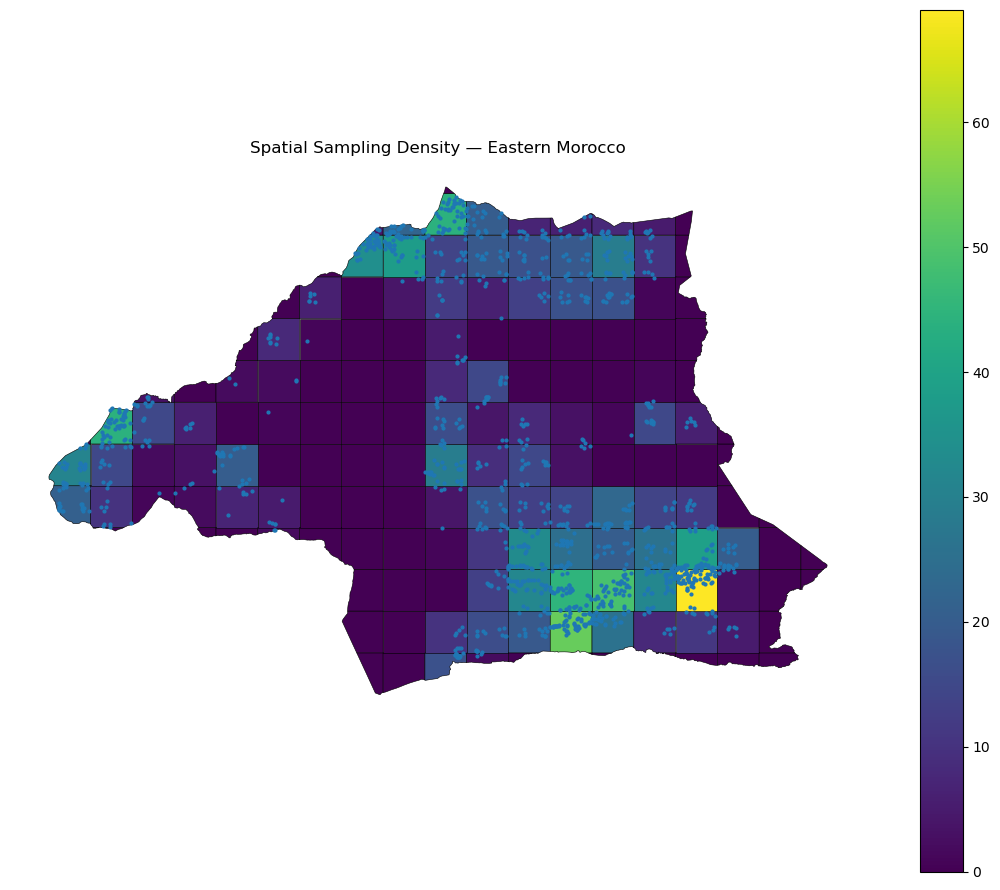

In [80]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 9))

grid.plot(
    ax=ax,
    column="n",
    legend=True,
    edgecolor="black",
    linewidth=0.4
)

em_pts.plot(
    ax=ax,
    markersize=4
)

ax.set_title(
    "Spatial Sampling Density — Eastern Morocco"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [81]:
class_grid = (
    points_grid
    .groupby(["grid_id", "class"])
    .size()
    .reset_index(name="n")
)

display(class_grid)

,grid_id,class,n
0,G001,Cultivated field/fallow,2
1,G001,Grass steppe,12
2,G001,Salty steppe,2
3,G001,Shrub steppe,2
4,G001,Wadi and gullies,3
...,...,...,...
317,G150,Cultivated field/fallow,4
318,G150,Grass steppe,10
319,G150,Shrub steppe,2
320,G150,Wadi and gullies,1


#### 2.2.2 20*20 Grid

In [97]:
# -------------------------------------------------------------
# 1. Assign survey points to grid cells
# -------------------------------------------------------------

points_grid = gpd.sjoin(
    em_pts[["class", "geometry"]],
    grid[["grid_id", "geometry"]],
    how="left",
    predicate="within"
)


# -------------------------------------------------------------
# 2. Number of survey points per grid cell
# -------------------------------------------------------------

total_counts = (
    points_grid
    .groupby("grid_id")
    .size()
    .rename("n_total")
)


# Number of habitat classes represented
class_number = (
    points_grid
    .groupby("grid_id")["class"]
    .nunique()
    .rename("n_classes")
)


# -------------------------------------------------------------
# 3. Counts for each habitat class within each cell
# -------------------------------------------------------------

class_counts = (
    points_grid
    .groupby(["grid_id", "class"])
    .size()
    .unstack(fill_value=0)
)


# -------------------------------------------------------------
# 4. Add statistics to grid
# -------------------------------------------------------------

grid_export = grid.copy()

grid_export = grid_export.merge(
    total_counts,
    left_on="grid_id",
    right_index=True,
    how="left"
)

grid_export = grid_export.merge(
    class_number,
    left_on="grid_id",
    right_index=True,
    how="left"
)

grid_export["n_total"] = (
    grid_export["n_total"]
    .fillna(0)
    .astype(int)
)

grid_export["n_classes"] = (
    grid_export["n_classes"]
    .fillna(0)
    .astype(int)
)

print(grid_export[
    ["grid_id", "n_total", "n_classes"]
].head())

for habitat in class_counts.columns:

    values = class_counts[habitat]

    grid_export[habitat] = (
        grid_export["grid_id"]
        .map(values)
        .fillna(0)
        .astype(int)
    )
    
# Google Earth requires WGS84
grid_kml = grid_export.to_crs("EPSG:4326").copy()

# Google Earth display name
grid_kml["Name"] = grid_kml["grid_id"].astype(str)

habitat_classes = [
    "Grass steppe",
    "Shrub steppe",
    "Cultivated field/fallow",
    "Wadi and gullies",
    "Water body",
    "Salty steppe",
    "Dune",
    "Spreading area",
    "Bare rocky",
    "Open woodland"
]


def make_description(row):

    text = (
        f"Grid ID: {row['grid_id']}\n"
        f"Total plots: {row['n_total']}\n"
        f"Classes represented: {row['n_classes']}\n\n"
        f"Class distribution:\n"
    )

    for habitat in habitat_classes:

        if habitat in row.index:

            n = row[habitat]

            if pd.notna(n) and n > 0:
                text += f"{habitat}: {int(n)}\n"

    return text


grid_kml["Description"] = grid_kml.apply(
    make_description,
    axis=1
)

output_grid_kml = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Reneco\Vegetation Cover and Food Availability Studies"
    r"\Eastern_Morocco_Training_Grid.kml"
)

grid_kml.to_file(
    output_grid_kml,
    driver="KML",
    engine="fiona"
)

print("Saved:")
print(output_grid_kml)
print("Grid cells:", len(grid_kml))

  grid_id  n_total  n_classes
0    G001       21          5
1    G002       31          5
2    G003        0          0
3    G004        0          0
4    G005       10          4
Saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Eastern_Morocco_Training_Grid.kml
Grid cells: 160


In [100]:
workdir = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Reneco\Vegetation Cover and Food Availability Studies"
)

grid_gpkg = workdir / "Eastern_Morocco_Training_Grid.gpkg"

grid_export.to_file(
    grid_gpkg,
    layer="grid_20km",
    driver="GPKG"
)

print("Saved analytical grid:")
print(grid_gpkg)

Saved analytical grid:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Eastern_Morocco_Training_Grid.gpkg


### 1.3 Preparting the traning polygons/footprints for vegetation plots

In [98]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import fiona

# ------------------------------------------------------------
# Working directory
# ------------------------------------------------------------

workdir = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Reneco\Vegetation Cover and Food Availability Studies"
)

# ------------------------------------------------------------
# Saved Eastern Morocco field points
# ------------------------------------------------------------

points_gpkg = (
    workdir /
    "Phytosociological_Survey_Eastern_Morocco_2008_2026.gpkg"
)

# Check layer names
print("Point GPKG layers:")
print(fiona.listlayers(str(points_gpkg)))

# If there is only one layer:
eastern_final = gpd.read_file(points_gpkg)

# Keep only the fields we actually need
point_fields = [
    "Station_ID",
    "Station_Na",
    "Latitude",
    "Longitude",
    "Area_M2",
    "Exposure",
    "Slope_Clas",
    "class",
    "geometry"
]

eastern_final = eastern_final[point_fields].copy()

print("\nEastern Morocco field points:")
print("Records:", len(eastern_final))
print("CRS:", eastern_final.crs)
print("Fields:", eastern_final.columns.tolist())

Point GPKG layers:
['Eastern_Morocco']

Eastern Morocco field points:
Records: 1394
CRS: EPSG:4326
Fields: ['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'geometry']


In [99]:
footprint_gpkg = (
    workdir /
    "Eastern_Morocco_Field_Footprints.gpkg"
)

print(fiona.listlayers(str(footprint_gpkg)))

field_footprints = gpd.read_file(
    footprint_gpkg,
    layer="field_footprints"
)

print("\nField footprints:")
print("Records:", len(field_footprints))
print("CRS:", field_footprints.crs)
print(field_footprints.columns.tolist())

['field_footprints']

Field footprints:
Records: 1246
CRS: EPSG:32630
['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'Area_num', 'Field_R_m', 'geometry']


In [101]:
# reload the exported grid, grid_export
field_grid = gpd.read_file(
    grid_gpkg,
    layer="grid_20km"
)

print("Grid cells:", len(field_grid))
print("CRS:", field_grid.crs)

Grid cells: 160
CRS: EPSG:32630


In [117]:
print(field_footprints.columns.tolist())

['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'Area_num', 'Field_R_m', 'geometry']


In [133]:
# generateing the traning polygon candidates from the field footprints
phyto_candidates = field_footprints.copy()

phyto_candidates["source"] = "PHYTOSOC"

phyto_candidates["field_sup"] = 1

phyto_candidates["geom_rule"] = "AREA_EQUIV_BUFFER"

phyto_candidates["qc_status"] = "UNREVIEWED"

phyto_candidates["use_status"] = "CANDIDATE"

phyto_candidates["confidence"] = pd.NA

phyto_candidates = phyto_candidates.reset_index(drop=True)

# sample_id: our training-data identifier
# Station_ID:original source identifier
phyto_candidates["sample_id"] = [
    f"PHY_{i:04d}"
    for i in range(1, len(phyto_candidates) + 1)
]

# calculate the polygon areas
phyto_candidates["poly_area"] = (
    phyto_candidates.geometry.area
)

phyto_candidates["Area_num"] = pd.to_numeric(
    phyto_candidates["Area_M2"],
    errors="coerce"
)

display(
    round(phyto_candidates[
        ["sample_id", "Area_num", "poly_area"]
    ].head(10),2)
)

,sample_id,Area_num,poly_area
0,PHY_0001,120.0,119.81
1,PHY_0002,120.0,119.81
2,PHY_0003,150.0,149.76
3,PHY_0004,150.0,149.76
4,PHY_0005,150.0,149.76
5,PHY_0006,160.0,159.74
6,PHY_0007,200.0,199.68
7,PHY_0008,200.0,199.68
8,PHY_0009,200.0,199.68
9,PHY_0010,200.0,199.68


In [134]:
# Estimate nominal Sentinel-2 pixel equivalents
# one 10m Sentinel-2 pixel ~ 100m2
phyto_candidates["S2_pix_eq"] = (
    phyto_candidates["poly_area"] / 100
)

display(
    round(phyto_candidates["S2_pix_eq"].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    ), 1)
)

count    1246.0
mean       27.9
std        25.6
min         1.2
10%         7.5
25%        12.5
50%        20.0
75%        31.9
90%        59.9
95%        99.8
max       159.7
Name: S2_pix_eq, dtype: float64

In [135]:
# Assign review rules automatically
# 1.for normal habitat: Area buffer -> inspect
# 2.for wadi and gullies: manual linear digitization
# 3.for tiny polygons/habitats:inspect and expand if homogeneous

# 1. Normal
phyto_candidates.loc[
    (phyto_candidates["S2_pix_eq"] >= 4)
    & (phyto_candidates["class"] != "Wadi and gullies"),
    "review_rule"
] = "CHECK_AND_KEEP_OR_REFINE"

# 2. Wadi and Gullies
phyto_candidates.loc[
    phyto_candidates["class"] == "Wadi and gullies",
    "review_rule"
] = "TRACE_LINEAR_VHR"

# 3. Tiny polygons
phyto_candidates.loc[
    (phyto_candidates["S2_pix_eq"] < 4)
    & (phyto_candidates["class"] != "Wadi and gullies"),
    "review_rule"
] = "EXPAND_IF_HOMOGENEOUS"

# summary
print(
    phyto_candidates["review_rule"]
    .value_counts()
)


review_rule
CHECK_AND_KEEP_OR_REFINE    1008
TRACE_LINEAR_VHR             190
EXPAND_IF_HOMOGENEOUS         48
Name: count, dtype: int64


In [136]:
print(phyto_candidates.columns.tolist())

['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'Area_num', 'Field_R_m', 'geometry', 'source', 'field_sup', 'geom_rule', 'qc_status', 'use_status', 'confidence', 'sample_id', 'poly_area', 'S2_pix_eq', 'review_rule']


In [137]:
# Attach grid_id to each footprint
candidate_centroids = phyto_candidates[
    ["sample_id", "geometry"]
].copy()

candidate_centroids["geometry"] = (
    candidate_centroids.geometry.centroid
)

if field_grid.crs != candidate_centroids.crs:
    grid_for_join = field_grid.to_crs(
        candidate_centroids.crs
    )
else:
    grid_for_join = field_grid.copy()
print(field_grid.columns.tolist())

['grid_id', 'n', 'n_total', 'n_classes', 'Bare rocky', 'Cultivated field/fallow', 'Dune', 'Grass steppe', 'Open woodland', 'Salty steppe', 'Shrub steppe', 'Spreading area', 'Wadi and gullies', 'Water body', 'geometry']


In [138]:
# Spatail join
candidate_grid = gpd.sjoin(
    candidate_centroids,
    grid_for_join[
        ["grid_id", "n_total", "n_classes", "geometry"]
    ],
    how="left",
    predicate="within"
)

candidate_grid = candidate_grid[
    ["sample_id", "grid_id", "n_total", "n_classes"]
]
print(candidate_grid.columns.tolist())
print('Before Spatial join:',phyto_candidates.columns.tolist())
phyto_candidates = phyto_candidates.merge(
    candidate_grid,
    on="sample_id",
    how="left"
)

print('After Spatial join:',phyto_candidates.columns.tolist())

['sample_id', 'grid_id', 'n_total', 'n_classes']
Before Spatial join: ['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'Area_num', 'Field_R_m', 'geometry', 'source', 'field_sup', 'geom_rule', 'qc_status', 'use_status', 'confidence', 'sample_id', 'poly_area', 'S2_pix_eq', 'review_rule']
After Spatial join: ['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'Area_num', 'Field_R_m', 'geometry', 'source', 'field_sup', 'geom_rule', 'qc_status', 'use_status', 'confidence', 'sample_id', 'poly_area', 'S2_pix_eq', 'review_rule', 'grid_id', 'n_total', 'n_classes']


In [139]:
print(field_grid.columns.tolist())
print(phyto_candidates.columns.tolist())

['grid_id', 'n', 'n_total', 'n_classes', 'Bare rocky', 'Cultivated field/fallow', 'Dune', 'Grass steppe', 'Open woodland', 'Salty steppe', 'Shrub steppe', 'Spreading area', 'Wadi and gullies', 'Water body', 'geometry']
['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'Area_num', 'Field_R_m', 'geometry', 'source', 'field_sup', 'geom_rule', 'qc_status', 'use_status', 'confidence', 'sample_id', 'poly_area', 'S2_pix_eq', 'review_rule', 'grid_id', 'n_total', 'n_classes']


In [140]:
# Attach class-specific plot count within each grid

class_columns = [
    'Bare rocky',
    'Cultivated field/fallow',
    'Dune',
    'Grass steppe',
    'Open woodland',
    'Salty steppe',
    'Shrub steppe',
    'Spreading area',
    'Wadi and gullies',
    'Water body'
]

# Convert grid class counts from wide to long format
grid_class_long = (
    field_grid[
        ["grid_id"] + class_columns
    ]
    .melt(
        id_vars="grid_id",
        var_name="class",
        value_name="grid_class_n"
    )
)

display(grid_class_long.head(5))
print(grid_class_long.columns.tolist())

,grid_id,class,grid_class_n
0,G001,Bare rocky,0
1,G002,Bare rocky,0
2,G003,Bare rocky,0
3,G004,Bare rocky,0
4,G005,Bare rocky,0


['grid_id', 'class', 'grid_class_n']


In [142]:
phyto_candidates_2 = phyto_candidates.copy()
print(phyto_candidates_2.columns.tolist())

['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'Area_num', 'Field_R_m', 'geometry', 'source', 'field_sup', 'geom_rule', 'qc_status', 'use_status', 'confidence', 'sample_id', 'poly_area', 'S2_pix_eq', 'review_rule', 'grid_id', 'n_total', 'n_classes']


In [143]:
# this box can not be run twice!!!!
phyto_candidates_2 = phyto_candidates_2.merge(
    grid_class_long,
    on=["grid_id", "class"],
    how="left"
)

phyto_candidates_2["grid_class_n"] = (
    phyto_candidates_2["grid_class_n"]
    .fillna(0)
    .astype(int)
)
print(phyto_candidates_2.columns.tolist())
# display(phyto_candidates.head(5))

['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'Area_num', 'Field_R_m', 'geometry', 'source', 'field_sup', 'geom_rule', 'qc_status', 'use_status', 'confidence', 'sample_id', 'poly_area', 'S2_pix_eq', 'review_rule', 'grid_id', 'n_total', 'n_classes', 'grid_class_n']


In [144]:
display(
    phyto_candidates_2[
        [
            "sample_id",
            "Station_ID",
            "class",
            "grid_id",
            "grid_class_n"
        ]
    ].head(10)
)

,sample_id,Station_ID,class,grid_id,grid_class_n
0,PHY_0001,34883,Grass steppe,G113,33
1,PHY_0002,100281,Water body,G137,12
2,PHY_0003,176637,Wadi and gullies,G126,4
3,PHY_0004,74289,Grass steppe,G100,23
4,PHY_0005,81553,Water body,G110,1
5,PHY_0006,94537,Salty steppe,G011,2
6,PHY_0007,107823,Wadi and gullies,G129,8
7,PHY_0008,75102,Wadi and gullies,G129,8
8,PHY_0009,103386,Wadi and gullies,G115,8
9,PHY_0010,121016,Salty steppe,G062,2


In [149]:
print(
    round(phyto_candidates_2["grid_class_n"]
    .describe(),0)
)

display(
    phyto_candidates_2[
        [
            "class",
            "grid_id",
            "grid_class_n"
        ]
    ]
    .sort_values(
        ["class", "grid_class_n"]
    )
    .head(5)
)

count    1246.0
mean        9.0
std         8.0
min         1.0
25%         4.0
50%         7.0
75%        12.0
max        33.0
Name: grid_class_n, dtype: float64


,class,grid_id,grid_class_n
1216,Bare rocky,G101,2
63,Cultivated field/fallow,G008,1
139,Cultivated field/fallow,G026,1
183,Cultivated field/fallow,G082,1
294,Cultivated field/fallow,G067,1


#### 1.4 Create a review priority

In [150]:
high_priority_classes = [
    "Bare rocky",
    "Open woodland",
    "Spreading area"
]

medium_priority_classes = [
    "Salty steppe",
    "Dune"
]

phyto_candidates["priority"] = "NORMAL"

In [151]:
phyto_candidates_2.loc[
    phyto_candidates_2["class"].isin(high_priority_classes),
    "priority"
] = "HIGH"

phyto_candidates_2.loc[
    phyto_candidates_2["class"].isin(medium_priority_classes),
    "priority"
] = "MEDIUM"

# Increase priority for spatial rarity:
phyto_candidates_2.loc[
    phyto_candidates_2["grid_class_n"] <= 2,
    "priority"
] = "HIGH"

# Wadi gets manual review:
phyto_candidates_2.loc[
    phyto_candidates_2["class"] == "Wadi and gullies",
    "priority"
] = "MANUAL"

In [152]:
display(
    phyto_candidates_2[
        [
            "sample_id",
            "Station_ID",
            "class",
            "Area_num",
            "S2_pix_eq",
            "grid_id",
            "grid_class_n",
            "review_rule",
            "priority"
        ]
    ]
    .sort_values(
        ["priority", "class", "grid_class_n"]
    )
    .head(5)
)

,sample_id,Station_ID,class,Area_num,S2_pix_eq,grid_id,grid_class_n,review_rule,priority
1216,PHY_1217,Phytosociology relevé,Bare rocky,750.0,7.487958,G101,2,CHECK_AND_KEEP_OR_REFINE,HIGH
63,PHY_0064,362559,Cultivated field/fallow,500.0,4.991972,G008,1,CHECK_AND_KEEP_OR_REFINE,HIGH
139,PHY_0140,362584,Cultivated field/fallow,800.0,7.987155,G026,1,CHECK_AND_KEEP_OR_REFINE,HIGH
183,PHY_0184,200028,Cultivated field/fallow,1000.0,9.983944,G082,1,CHECK_AND_KEEP_OR_REFINE,HIGH
294,PHY_0295,298847,Cultivated field/fallow,1250.0,12.479930,G067,1,CHECK_AND_KEEP_OR_REFINE,HIGH


In [153]:
# SAVE IT TO NEW LAYER
candidate_gpkg = (
    workdir /
    "Eastern_Morocco_Training_Data.gpkg"
)

phyto_candidates_2.to_file(
    candidate_gpkg,
    layer="phytosoc_candidates",
    driver="GPKG"
)

print("Saved:")
print(candidate_gpkg)
print("Layer: phytosoc_candidates")
print("Candidates:", len(phyto_candidates_2))

Saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Eastern_Morocco_Training_Data.gpkg
Layer: phytosoc_candidates
Candidates: 1246


In [155]:
# ============================================================
# STEP 0 — SETUP
# ============================================================

from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Main directories
# ------------------------------------------------------------

BASE = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data"
)

TRAIN_DIR = (
    BASE
    / r"Reneco\Vegetation Cover and Food Availability Studies"
)

ANTHRO_DIR = (
    BASE
    / r"Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation"
)

BUILDING_DIR = (
    BASE
    / r"Habitat mapping\build-up\hotosm_mar_buildings_polygons_shp"
)

# ------------------------------------------------------------
# Existing phytosociological footprints
# ------------------------------------------------------------

PHYTO_PATH = (
    TRAIN_DIR
    / "Eastern_Morocco_Field_Footprints.gpkg"
)

PHYTO_LAYER = "field_footprints"

# ------------------------------------------------------------
# 20 x 20 km grid
# ------------------------------------------------------------

GRID_PATH = (
    TRAIN_DIR
    / "Eastern_Morocco_Training_Grid.gpkg"
)

GRID_LAYER = "grid_20km"

# ------------------------------------------------------------
# Cultivated/fallow polygons
# ------------------------------------------------------------

ALBATEN_FARMS_PATH = (
    ANTHRO_DIR
    / "Al_Baten_occupation_Farms_20240621.shp"
)

BOUARFA_2024_PATH = (
    ANTHRO_DIR
    / "Bouarfa_anthropized_land_1_2024.shp"
)

# ------------------------------------------------------------
# HOT OSM buildings clipped to Eastern Morocco
# ------------------------------------------------------------

BUILDINGS_PATH = (
    BUILDING_DIR
    / "hotosm_mar_buildings_polygons_EM.shp"
)

# ------------------------------------------------------------
# Outputs
# ------------------------------------------------------------

OUTPUT_GPKG = (
    TRAIN_DIR
    / "Eastern_Morocco_Training_Candidates_2025.gpkg"
)

BUILT_REVIEW_GPKG = (
    TRAIN_DIR
    / "Eastern_Morocco_BuiltUp_Candidates_2025.gpkg"
)

# ------------------------------------------------------------
# Final 11-class system
# Use 0–10 for classifier IDs
# ------------------------------------------------------------

CLASS_DICT = {
    "Grass steppe": 0,
    "Shrub steppe": 1,
    "Wooded steppe": 2,
    "Bare rocky": 3,
    "Spreading area": 4,
    "Salty steppe": 5,
    "Dune": 6,
    "Wadi and gullies": 7,
    "Cultivated field/fallow": 8,
    "Water body": 9,
    "Built-up": 10
}

print("Setup complete.")

Setup complete.


In [156]:
# ============================================================
# STEP 1 — LOAD EXISTING FIELD FOOTPRINTS + GRID
# ============================================================

field_footprints = gpd.read_file(
    PHYTO_PATH,
    layer=PHYTO_LAYER
)

field_grid = gpd.read_file(
    GRID_PATH,
    layer=GRID_LAYER
)

print("Field footprints:", len(field_footprints))
print("Field footprint CRS:", field_footprints.crs)

print("\nGrid cells:", len(field_grid))
print("Grid CRS:", field_grid.crs)

print("\nField columns:")
print(field_footprints.columns.tolist())

print("\nGrid columns:")
print(field_grid.columns.tolist())

Field footprints: 1246
Field footprint CRS: EPSG:32630

Grid cells: 160
Grid CRS: EPSG:32630

Field columns:
['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'Area_num', 'Field_R_m', 'geometry']

Grid columns:
['grid_id', 'n', 'n_total', 'n_classes', 'Bare rocky', 'Cultivated field/fallow', 'Dune', 'Grass steppe', 'Open woodland', 'Salty steppe', 'Shrub steppe', 'Spreading area', 'Wadi and gullies', 'Water body', 'geometry']


In [157]:
# Use the field-footprint CRS as our common projected/metric CRS
work_crs = field_footprints.crs

field_grid = field_grid.to_crs(work_crs)

print("Working CRS:", work_crs)

Working CRS: EPSG:32630


In [158]:
# ============================================================
# STEP 2 — HELPER FUNCTIONS
# ============================================================

def clean_polygon_gdf(gdf, crs):
    """
    Basic geometry cleaning for polygon training sources.
    """

    gdf = gdf.to_crs(crs).copy()

    # Remove missing / empty geometries
    gdf = gdf[
        gdf.geometry.notna()
        & ~gdf.geometry.is_empty
    ].copy()

    # Repair simple invalid polygons
    invalid = ~gdf.geometry.is_valid

    if invalid.any():
        print("Repairing invalid geometries:", invalid.sum())

        gdf.loc[invalid, "geometry"] = (
            gdf.loc[invalid, "geometry"]
            .buffer(0)
        )

    # Remove anything still invalid/empty
    gdf = gdf[
        gdf.geometry.notna()
        & ~gdf.geometry.is_empty
        & gdf.geometry.is_valid
    ].copy()

    return gdf


def assign_grid(gdf, grid):
    """
    Assign each polygon to one 20-km grid based on an
    interior representative point.
    """

    temp = gdf.copy()

    pts = gdf[["geometry"]].copy()

    # Unlike centroid, representative_point is guaranteed
    # to fall inside the polygon
    pts["geometry"] = pts.geometry.representative_point()

    joined = gpd.sjoin(
        pts,
        grid[["grid_id", "geometry"]],
        how="left",
        predicate="within"
    )

    temp["grid_id"] = joined["grid_id"].values

    return temp


def get_source_id(gdf):
    """
    Find a reasonable source identifier.
    """

    candidates = [
        "Station_ID",
        "osm_id",
        "OBJECTID",
        "FID",
        "id"
    ]

    for col in candidates:
        if col in gdf.columns:
            return gdf[col].astype("string")

    return pd.Series(
        gdf.index.astype(str),
        index=gdf.index,
        dtype="string"
    )


def standardize_source(
    gdf,
    prefix,
    source,
    class_name=None,
    ref_year=None,
    field_sup=0,
    confidence=2,
    geom_rule="EXISTING_POLYGON"
):
    """
    Convert any polygon source into the common
    training-candidate schema.
    """

    out = clean_polygon_gdf(
        gdf,
        work_crs
    ).reset_index(drop=True)

    # -------------------------------------------
    # Class
    # -------------------------------------------

    if class_name is not None:
        out["class"] = class_name

    # Harmonize final terminology
    out["class"] = (
        out["class"]
        .astype("string")
        .str.strip()
        .replace({
            "Open woodland": "Wooded steppe"
        })
    )

    out["class_id"] = (
        out["class"]
        .map(CLASS_DICT)
    )

    # -------------------------------------------
    # Identifiers
    # -------------------------------------------

    out["source_id"] = get_source_id(out)

    out["sample_id"] = [
        f"{prefix}_{i:04d}"
        for i in range(1, len(out) + 1)
    ]

    # Independent site
    if "Station_ID" in out.columns:
        out["site_id"] = (
            prefix
            + "_"
            + out["Station_ID"]
              .fillna(out["sample_id"])
              .astype(str)
        )
    else:
        out["site_id"] = out["sample_id"]

    # -------------------------------------------
    # Provenance
    # -------------------------------------------

    out["source"] = source
    out["ref_year"] = ref_year
    out["field_sup"] = field_sup
    out["confidence"] = confidence
    out["geom_rule"] = geom_rule

    out["use_status"] = "CANDIDATE"
    out["qc_status"] = "UNREVIEWED"

    # -------------------------------------------
    # Geometry metrics
    # -------------------------------------------

    out["poly_area"] = out.geometry.area

    # -------------------------------------------
    # Grid
    # -------------------------------------------

    out = assign_grid(
        out,
        field_grid
    )

    return out

In [159]:
# ============================================================
# STEP 3 — PHYTOSOCIOLOGICAL CANDIDATES
# ============================================================

phyto = field_footprints.copy()

# Harmonize Open woodland if present
phyto["class"] = (
    phyto["class"]
    .astype("string")
    .str.strip()
    .replace({
        "Open woodland": "Wooded steppe"
    })
)

phyto["class_id"] = (
    phyto["class"]
    .map(CLASS_DICT)
)

phyto = phyto.reset_index(drop=True)

phyto["sample_id"] = [
    f"PHY_{i:04d}"
    for i in range(1, len(phyto) + 1)
]

phyto["source"] = "PHYTOSOC"

phyto["source_id"] = (
    phyto["Station_ID"]
    .astype("string")
)

phyto["site_id"] = (
    "PHY_"
    + phyto["Station_ID"]
      .astype("string")
)

phyto["ref_year"] = pd.NA
phyto["field_sup"] = 1

# Label is field-supported;
# polygon geometry still needs final QC
phyto["confidence"] = 2

phyto["geom_rule"] = "AREA_EQUIV_BUFFER"

phyto["use_status"] = "CANDIDATE"
phyto["qc_status"] = "UNREVIEWED"

phyto["poly_area"] = (
    phyto.geometry.area
)

# Re-assign grid robustly
phyto = assign_grid(
    phyto,
    field_grid
)

print("Phytosociological candidates:", len(phyto))

print(
    phyto["class"]
    .value_counts()
)

Phytosociological candidates: 1246
class
Grass steppe               432
Shrub steppe               327
Cultivated field/fallow    214
Wadi and gullies           190
Water body                  31
Dune                        27
Salty steppe                21
Wooded steppe                2
Bare rocky                   1
Spreading area               1
Name: count, dtype: Int64


In [205]:
# ============================================================
# FIELD POINTS THAT DID NOT GET AN Area_M2 FOOTPRINT
# ============================================================

eastern_points = gpd.read_file(
    points_gpkg
)

eastern_points["Area_num"] = pd.to_numeric(
    eastern_points["Area_M2"],
    errors="coerce"
)

point_only = eastern_points[
    eastern_points["Area_num"].isna()
    | (eastern_points["Area_num"] <= 0)
].copy()

print(
    "Field-labelled points without usable Area_M2:",
    len(point_only)
)

print(
    point_only["class"]
    .value_counts(dropna=False)
)

Field-labelled points without usable Area_M2: 148
class
Water body                 43
Grass steppe               31
Shrub steppe               18
Wadi and gullies           14
Salty steppe               13
Spreading area             11
Cultivated field/fallow     9
Dune                        7
Bare rocky                  2
Name: count, dtype: int64


In [160]:
# ============================================================
# STEP 4 — CULTIVATED/FALLOW POLYGON SOURCES
# ============================================================

albaten_farms_raw = gpd.read_file(
    ALBATEN_FARMS_PATH
)

bouarfa_2024_raw = gpd.read_file(
    BOUARFA_2024_PATH
)

print("Al Baten farm polygons:",
      len(albaten_farms_raw))

print("Bouarfa 2024 cultivated polygons:",
      len(bouarfa_2024_raw))

Al Baten farm polygons: 153
Bouarfa 2024 cultivated polygons: 606


In [161]:
# Standardize Al Baten:
albaten_farms = standardize_source(
    albaten_farms_raw,
    prefix="ABFARM",
    source="ALBATEN_FARMS_2024",
    class_name="Cultivated field/fallow",
    ref_year=2024,
    field_sup=0,
    confidence=3,
    geom_rule="EXISTING_CULTIVATED_POLYGON"
)

print("Al Baten ready:", len(albaten_farms))

# Standardize Bouarfa:
bouarfa_cultivated = standardize_source(
    bouarfa_2024_raw,
    prefix="BOUCULT",
    source="BOUARFA_ANTHRO_2024",
    class_name="Cultivated field/fallow",
    ref_year=2024,
    field_sup=0,
    confidence=3,
    geom_rule="EXISTING_CULTIVATED_POLYGON"
)

print("Bouarfa ready:", len(bouarfa_cultivated))

Al Baten ready: 153
Bouarfa ready: 606


In [162]:
# Merge the two cultivated sources:
cultivated_candidates = gpd.GeoDataFrame(
    pd.concat(
        [
            albaten_farms,
            bouarfa_cultivated
        ],
        ignore_index=True
    ),
    geometry="geometry",
    crs=work_crs
)

print(
    "Total additional cultivated polygons:",
    len(cultivated_candidates)
)

print(
    cultivated_candidates["source"]
    .value_counts()
)

Total additional cultivated polygons: 759
source
BOUARFA_ANTHRO_2024    606
ALBATEN_FARMS_2024     153
Name: count, dtype: int64


In [163]:
# quick look and review
training_stage1 = gpd.GeoDataFrame(
    pd.concat(
        [
            phyto,
            cultivated_candidates
        ],
        ignore_index=True
    ),
    geometry="geometry",
    crs=work_crs
)

print(
    "Training candidates before Built-up:",
    len(training_stage1)
)

Training candidates before Built-up: 2005


In [164]:
# # ============================================================
# STEP 5 — HOT OSM BUILDINGS
# ============================================================

buildings = gpd.read_file(
    BUILDINGS_PATH
)

buildings = clean_polygon_gdf(
    buildings,
    work_crs
)

print("Raw Eastern Morocco buildings:",
      len(buildings))

print("\nBuilding type distribution:")

print(
    buildings["building"]
    .fillna("unknown")
    .astype(str)
    .str.lower()
    .value_counts()
    .head(30)
)

Raw Eastern Morocco buildings: 2584

Building type distribution:
building
yes              2516
ruins              14
house              13
roof               10
mosque              8
train_station       4
hotel               4
hut                 3
residential         2
apartments          2
shed                2
commercial          2
school              1
public              1
retail              1
hospital            1
Name: count, dtype: int64


In [166]:
# # ============================================================
# STEP 6 — FILTER BUILDING TYPES
# ============================================================

buildings["building_clean"] = (
    buildings["building"]
    .fillna("yes")
    .astype(str)
    .str.lower()
    .str.strip()
)

EXCLUDE_BUILDING_TYPES = {
    "ruins",
    "construction",
    "demolished",
    "destroyed",
    "abandoned",
    "greenhouse"
}

buildings_clean = buildings[
    ~buildings["building_clean"]
    .isin(EXCLUDE_BUILDING_TYPES)
].copy()

buildings_clean["bldg_area"] = (
    buildings_clean.geometry.area
)

print("Buildings after filtering:",
      len(buildings_clean))

display(
    round(buildings_clean["bldg_area"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    ),1)
)

Buildings after filtering: 2570


count     2570.0
mean       250.9
std       1124.8
min          2.2
10%         35.8
25%         70.9
50%        131.7
75%        238.0
90%        440.6
95%        670.5
max      50582.8
Name: bldg_area, dtype: float64

In [168]:
# ============================================================
# STEP 6 — FILTER BUILDING TYPES
# ============================================================

buildings["building_clean"] = (
    buildings["building"]
    .fillna("yes")
    .astype(str)
    .str.lower()
    .str.strip()
)

EXCLUDE_BUILDING_TYPES = {
    "ruins",
    "construction",
    "demolished",
    "destroyed",
    "abandoned",
    "greenhouse"
}

buildings_clean = buildings[
    ~buildings["building_clean"]
    .isin(EXCLUDE_BUILDING_TYPES)
].copy()

buildings_clean["bldg_area"] = (
    buildings_clean.geometry.area
)

print("Buildings after filtering:",
      len(buildings_clean))

display(
    round(buildings_clean["bldg_area"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    ),1)
)

Buildings after filtering: 2570


count     2570.0
mean       250.9
std       1124.8
min          2.2
10%         35.8
25%         70.9
50%        131.7
75%        238.0
90%        440.6
95%        670.5
max      50582.8
Name: bldg_area, dtype: float64

In [178]:
# ============================================================
# STEP 7 — CREATE BUILT-UP CLUSTERS
# ============================================================

BUILDING_BUFFER_M = 10

building_buffers = buildings_clean[
    ["geometry"]
].copy()

building_buffers["geometry"] = (
    building_buffers.geometry.buffer(
        BUILDING_BUFFER_M
    )
)

# Dissolve overlapping buffers
cluster_union = (
    building_buffers
    .dissolve()
    .explode(index_parts=False)
    .reset_index(drop=True)
)

built_clusters = gpd.GeoDataFrame(
    cluster_union,
    geometry="geometry",
    crs=work_crs
)

built_clusters["cluster_id"] = [
    f"BC_{i:04d}"
    for i in range(
        1,
        len(built_clusters) + 1
    )
]

built_clusters["cluster_area"] = (
    built_clusters.geometry.area
)

print("Initial building clusters:",
      len(built_clusters))

Initial building clusters: 1123


In [179]:
# ============================================================
# STEP 8 — BUILDING DENSITY
# ============================================================

# Use building representative points
bldg_pts = buildings_clean[
    ["bldg_area", "geometry"]
].copy()

bldg_pts["geometry"] = (
    bldg_pts.geometry.representative_point()
)

bldg_cluster_join = gpd.sjoin(
    bldg_pts,
    built_clusters[
        ["cluster_id", "geometry"]
    ],
    how="left",
    predicate="within"
)

cluster_stats = (
    bldg_cluster_join
    .groupby("cluster_id")
    .agg(
        bldg_count=("bldg_area", "size"),
        bldg_area_sum=("bldg_area", "sum")
    )
    .reset_index()
)

built_clusters = built_clusters.merge(
    cluster_stats,
    on="cluster_id",
    how="left"
)

built_clusters["bldg_count"] = (
    built_clusters["bldg_count"]
    .fillna(0)
    .astype(int)
)

built_clusters["bldg_area_sum"] = (
    built_clusters["bldg_area_sum"]
    .fillna(0)
)

built_clusters["building_density"] = (
    built_clusters["bldg_area_sum"]
    / built_clusters["cluster_area"]
)

display(
    round(built_clusters[
        [
            "cluster_id",
            "cluster_area",
            "bldg_count",
            "bldg_area_sum",
            "building_density"
        ]
    ]
    .sort_values(
        "building_density",
        ascending=False
    )
    .head(5),1)
)

,cluster_id,cluster_area,bldg_count,bldg_area_sum,building_density
735,BC_0736,96096.0,4,78924.9,0.8
842,BC_0843,9180.6,1,5816.1,0.6
1112,BC_1113,12350.9,2,7642.0,0.6
1066,BC_1067,5703.8,1,3145.7,0.6
13,BC_0014,5923.0,1,3234.1,0.5


In [180]:
# ============================================================
# STEP 9 — FILTER BUILT-UP CANDIDATES
# ============================================================

MIN_CLUSTER_AREA = 900       # ~30 x 30 m
MAX_CLUSTER_AREA = 50_000    # 5 ha; larger areas need review
MIN_BUILDING_DENSITY = 0.20
MIN_BUILDINGS = 2

built_good = built_clusters[
    (built_clusters["cluster_area"]
        >= MIN_CLUSTER_AREA)
    &
    (built_clusters["cluster_area"]
        <= MAX_CLUSTER_AREA)
    &
    (built_clusters["building_density"]
        >= MIN_BUILDING_DENSITY)
    &
    (
        (built_clusters["bldg_count"]
            >= MIN_BUILDINGS)
        |
        (built_clusters["bldg_area_sum"]
            >= 400)
    )
].copy()

print(
    "Built-up clusters passing initial filters:",
    len(built_good)
)

Built-up clusters passing initial filters: 245


In [181]:
# Large clusters are not discarded permanently. Keep them for manual inspection:
built_large_review = built_clusters[
    built_clusters["cluster_area"]
    > MAX_CLUSTER_AREA
].copy()

print(
    "Large settlement clusters reserved for review:",
    len(built_large_review)
)

Large settlement clusters reserved for review: 2


In [183]:
# ============================================================
# STEP 10 — ASSIGN GRID
# ============================================================

built_good = assign_grid(
    built_good,
    field_grid
)

print(
    built_good["grid_id"]
    .value_counts(dropna=False)
    .sort_index().head()
)

grid_id
G001    20
G002    16
G004     5
G005     3
G006     1
Name: count, dtype: int64


In [184]:
# ============================================================
# STEP 11 — REPRESENTATIVE BUILT-UP SAMPLING
# ============================================================

built_good["selection_score"] = (
    built_good["building_density"]
    * np.log1p(
        built_good["bldg_area_sum"]
    )
)

BUILTUP_PER_GRID = 3

built_selected = (
    built_good
    .sort_values(
        [
            "grid_id",
            "selection_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "grid_id",
        group_keys=False
    )
    .head(BUILTUP_PER_GRID)
    .copy()
)

print(
    "Representative Built-up clusters selected:",
    len(built_selected)
)

print(
    "20-km grids represented:",
    built_selected["grid_id"]
    .nunique()
)
# which gives up to three good Built-up sites in every grid cell where suitable building clusters occur.

Representative Built-up clusters selected: 107
20-km grids represented: 53


In [185]:
# ============================================================
# STEP 12 — STANDARDIZE BUILT-UP CANDIDATES
# ============================================================

built_selected = (
    built_selected
    .reset_index(drop=True)
)

built_selected["sample_id"] = [
    f"BLD_{i:04d}"
    for i in range(
        1,
        len(built_selected) + 1
    )
]

built_selected["site_id"] = (
    built_selected["cluster_id"]
)

built_selected["source_id"] = (
    built_selected["cluster_id"]
)

built_selected["class"] = "Built-up"

built_selected["class_id"] = (
    CLASS_DICT["Built-up"]
)

built_selected["source"] = (
    "HOT_OSM_BUILDINGS"
)

built_selected["ref_year"] = 2025

built_selected["field_sup"] = 0

# Candidate geometries still deserve quick VHR QC
built_selected["confidence"] = 2

built_selected["geom_rule"] = (
    "OSM_BUILDING_CLUSTER"
)

built_selected["use_status"] = (
    "CANDIDATE"
)

built_selected["qc_status"] = (
    "UNREVIEWED"
)

built_selected["poly_area"] = (
    built_selected.geometry.area
)

print(
    built_selected[
        [
            "sample_id",
            "grid_id",
            "bldg_count",
            "building_density",
            "poly_area"
        ]
    ].head()
)

  sample_id grid_id  bldg_count  building_density    poly_area
0  BLD_0001    G001           1          0.546014  5923.026986
1  BLD_0002    G001           1          0.523966  5019.527735
2  BLD_0003    G001           1          0.457505  5729.324097
3  BLD_0004    G002           4          0.325082  5074.223220
4  BLD_0005    G002           1          0.345478  2987.205646


In [186]:
# ============================================================
# STEP 13 — COMMON TRAINING SCHEMA
# ============================================================

FINAL_FIELDS = [
    "sample_id",
    "site_id",
    "source_id",
    "class",
    "class_id",
    "source",
    "ref_year",
    "field_sup",
    "confidence",
    "geom_rule",
    "grid_id",
    "use_status",
    "qc_status",
    "poly_area",
    "geometry"
]


def select_final_fields(gdf):

    out = gdf.copy()

    for col in FINAL_FIELDS:
        if col not in out.columns:
            out[col] = pd.NA

    return out[FINAL_FIELDS].copy()


phyto_std = select_final_fields(
    phyto
)

cultivated_std = select_final_fields(
    cultivated_candidates
)

built_std = select_final_fields(
    built_selected
)

In [187]:
# ============================================================
# STEP 14 — MERGE TRAINING CANDIDATES
# ============================================================

training_candidates = gpd.GeoDataFrame(
    pd.concat(
        [
            phyto_std,
            cultivated_std,
            built_std
        ],
        ignore_index=True
    ),
    geometry="geometry",
    crs=work_crs
)

print(
    "Total training candidate polygons:",
    len(training_candidates)
)

Total training candidate polygons: 2112


In [189]:
# ============================================================
# STEP 15 — SOURCE SUMMARY
# ============================================================

source_summary = (
    training_candidates
    .groupby(
        ["source", "class"]
    )
    .agg(
        n_polygons=("sample_id", "size"),
        n_grids=("grid_id", "nunique"),
        total_area_m2=("poly_area", "sum"),
        median_area_m2=("poly_area", "median")
    )
    .reset_index()
)

display(round(source_summary,1))

,source,class,n_polygons,n_grids,total_area_m2,median_area_m2
0,ALBATEN_FARMS_2024,Cultivated field/fallow,153,4,13978636.4,32514.4
1,BOUARFA_ANTHRO_2024,Cultivated field/fallow,606,11,43600642.9,33383.3
2,HOT_OSM_BUILDINGS,Built-up,107,53,484485.2,2717.3
3,PHYTOSOC,Bare rocky,1,1,748.8,748.8
4,PHYTOSOC,Cultivated field/fallow,214,63,645961.2,1996.8
5,PHYTOSOC,Dune,27,12,42232.1,1497.6
6,PHYTOSOC,Grass steppe,432,67,1101199.1,1996.8
7,PHYTOSOC,Salty steppe,21,9,22873.2,748.8
8,PHYTOSOC,Shrub steppe,327,72,1042024.2,1996.8
9,PHYTOSOC,Spreading area,1,1,1497.6,1497.6


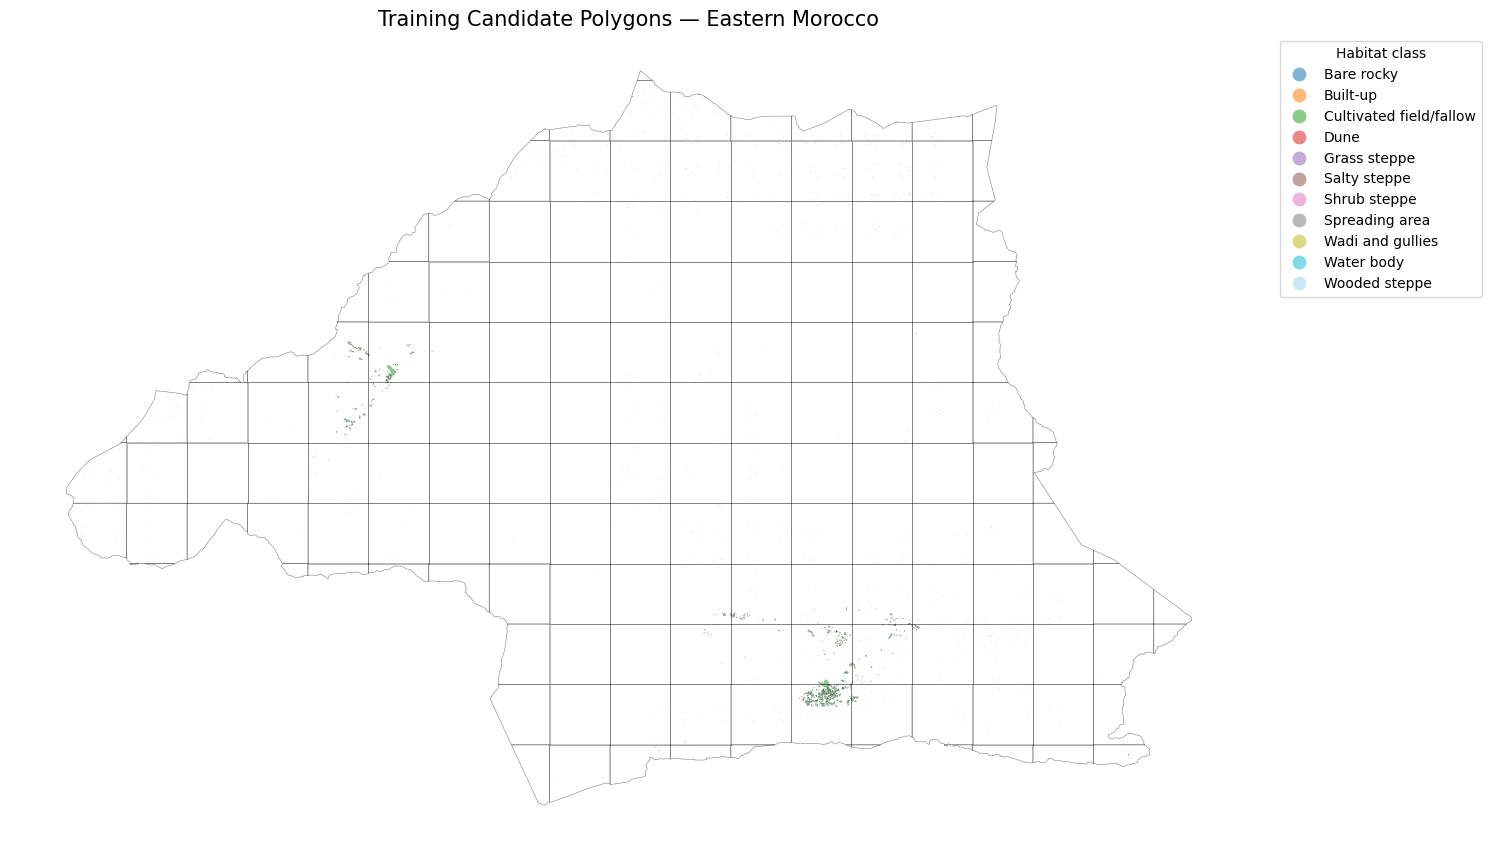

In [196]:
# ============================================================
# STEP 15B — MAP MERGED TRAINING CANDIDATES BY CLASS:Spatial distribution
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 11))

# 20 x 20 km grid
field_grid.boundary.plot(
    ax=ax,
    linewidth=0.4,
    color='black',
    alpha=0.5
)

# All candidate polygons
training_candidates.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    alpha=0.55,
    edgecolor="black",
    linewidth=0.15,
    cmap="tab20",
    legend_kwds={
        "title": "Habitat class",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Training Candidate Polygons — Eastern Morocco",
    fontsize=15
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

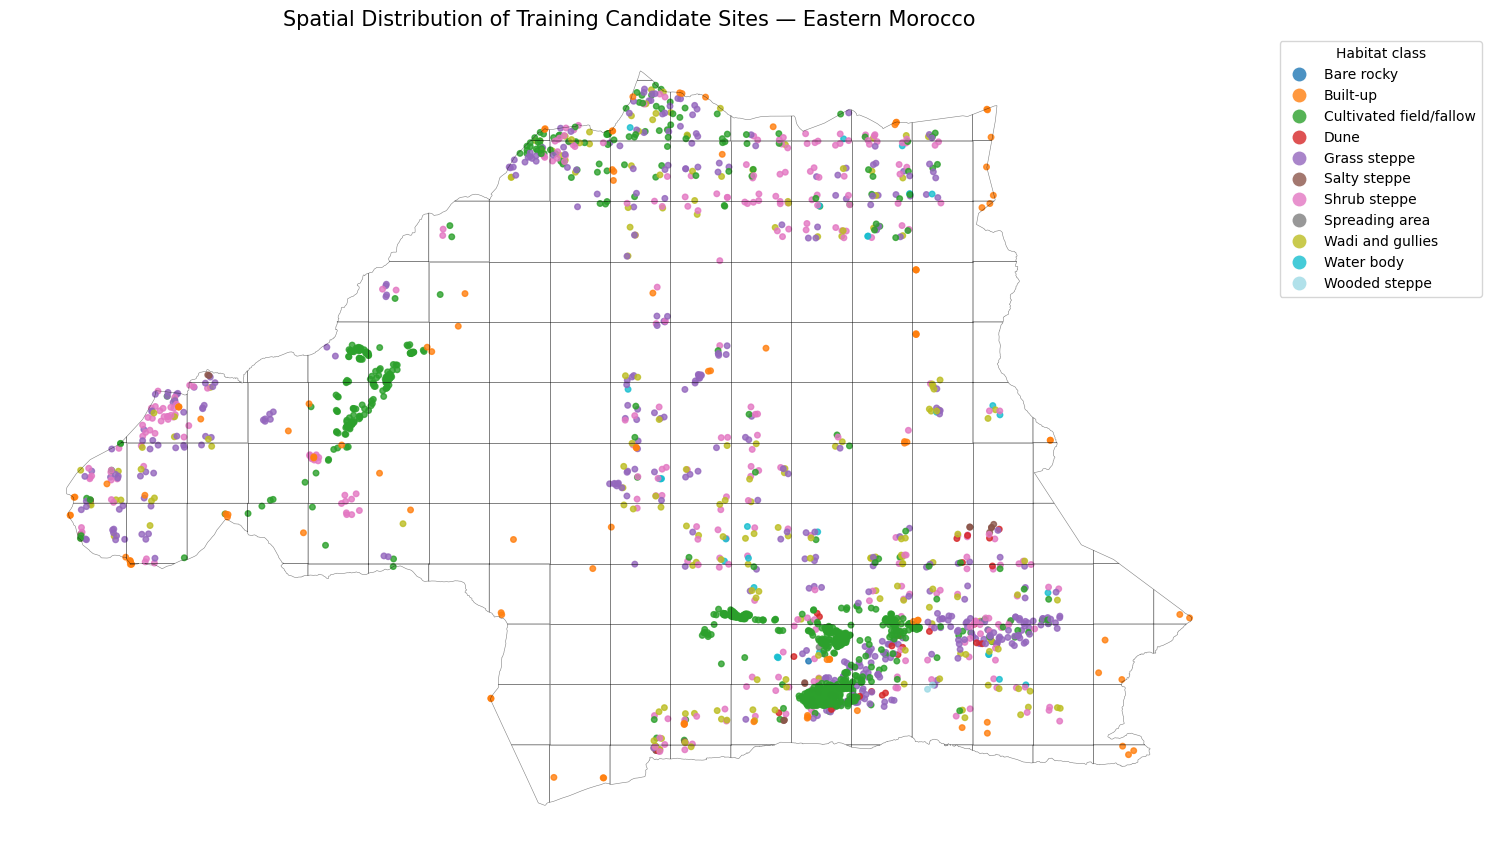

In [199]:
# ============================================================
# STEP 15C — MAP INDEPENDENT TRAINING LOCATIONS
# ============================================================

training_locations = training_candidates.copy()

training_locations["geometry"] = (
    training_locations.geometry.representative_point()
)

fig, ax = plt.subplots(figsize=(15, 11))

field_grid.boundary.plot(
    ax=ax,
    linewidth=0.4,
    color='black',
    alpha=0.5
)

training_locations.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=16,
    alpha=0.8,
    cmap="tab20",
    legend_kwds={
        "title": "Habitat class",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Spatial Distribution of Training Candidate Sites — Eastern Morocco",
    fontsize=15
)

ax.set_axis_off()

plt.tight_layout()
plt.show()



In [191]:
# ============================================================
# STEP 16 — CLASS SUMMARY
# ============================================================

class_summary = (
    training_candidates
    .groupby("class")
    .agg(
        n_polygons=("sample_id", "size"),
        n_sites=("site_id", "nunique"),
        n_grids=("grid_id", "nunique"),
        total_area_m2=("poly_area", "sum"),
        median_area_m2=("poly_area", "median")
    )
    .sort_values(
        "n_polygons",
        ascending=False
    )
)

display(round(class_summary,1))

,n_polygons,n_sites,n_grids,total_area_m2,median_area_m2
class,,,,,
Cultivated field/fallow,973,966,68,58225240.5,22101.7
Grass steppe,432,419,67,1101199.1,1996.8
Shrub steppe,327,316,72,1042024.2,1996.8
Wadi and gullies,190,189,64,548168.4,2496.0
Built-up,107,107,53,484485.2,2717.3
Water body,31,31,19,73022.6,1597.4
Dune,27,27,12,42232.1,1497.6
Salty steppe,21,21,9,22873.2,748.8
Wooded steppe,2,1,1,3494.4,1747.2


In [192]:
# ============================================================
# STEP 17 — SANITY CHECKS
# ============================================================

print(
    "Duplicate sample IDs:",
    training_candidates[
        "sample_id"
    ].duplicated().sum()
)

print(
    "Missing class IDs:",
    training_candidates[
        "class_id"
    ].isna().sum()
)

print(
    "Missing grid IDs:",
    training_candidates[
        "grid_id"
    ].isna().sum()
)

print(
    "Invalid geometries:",
    (~training_candidates.geometry.is_valid)
    .sum()
)

print(
    "Empty geometries:",
    training_candidates.geometry.is_empty
    .sum()
)

Duplicate sample IDs: 0
Missing class IDs: 0
Missing grid IDs: 0
Invalid geometries: 0
Empty geometries: 0


In [202]:
# ============================================================
# STEP 18 — CROSS-CLASS OVERLAP CHECK
# ============================================================

training_candidates["conflict_flag"] = 0

sindex = training_candidates.sindex

conflict_ids = set()
conflict_records = []

MIN_OVERLAP_M2 = 25

for i, row in training_candidates.iterrows():

    geom_i = row.geometry

    possible = sindex.query(
        geom_i,
        predicate="intersects"
    )

    for j in possible:

        if j <= i:
            continue

        row_j = training_candidates.iloc[j]

        # Same class is not a classification conflict
        if row["class"] == row_j["class"]:
            continue

        overlap = geom_i.intersection(
            row_j.geometry
        )

        if overlap.is_empty:
            continue

        overlap_area = overlap.area

        if overlap_area >= MIN_OVERLAP_M2:

            conflict_ids.add(
                row["sample_id"]
            )

            conflict_ids.add(
                row_j["sample_id"]
            )

            conflict_records.append({
                "sample_1": row["sample_id"],
                "class_1": row["class"],
                "source_1": row["source"],

                "sample_2": row_j["sample_id"],
                "class_2": row_j["class"],
                "source_2": row_j["source"],

                "overlap_m2": overlap_area
            })


training_candidates.loc[
    training_candidates["sample_id"]
    .isin(conflict_ids),
    "conflict_flag"
] = 1


conflicts = pd.DataFrame(
    conflict_records
)

print(
    "Candidate polygons involved in conflicts:",
    len(conflict_ids)
)

print(
    "Cross-class overlap pairs:",
    len(conflicts)
)

display(
    conflicts
    .sort_values(
        "overlap_m2",
        ascending=False
    )
    .head(30).round(1)
)

# ============================================================
# ADD CONFLICT OVERLAP RATIOS
# ============================================================

area_lookup = (
    training_candidates
    .set_index("sample_id")["poly_area"]
)

conflicts["area_1_m2"] = (
    conflicts["sample_1"]
    .map(area_lookup)
)

conflicts["area_2_m2"] = (
    conflicts["sample_2"]
    .map(area_lookup)
)

conflicts["overlap_pct_1"] = (
    conflicts["overlap_m2"]
    / conflicts["area_1_m2"]
    * 100
)

conflicts["overlap_pct_2"] = (
    conflicts["overlap_m2"]
    / conflicts["area_2_m2"]
    * 100
)

display(
    conflicts[
        [
            "sample_1",
            "class_1",
            "source_1",
            "sample_2",
            "class_2",
            "source_2",
            "overlap_m2",
            "overlap_pct_1",
            "overlap_pct_2"
        ]
    ]
    .sort_values(
        "overlap_m2",
        ascending=False
    )
    .round(1)
)

Candidate polygons involved in conflicts: 19
Cross-class overlap pairs: 10


,sample_1,class_1,source_1,sample_2,class_2,source_2,overlap_m2
9,PHY_0842,Grass steppe,PHYTOSOC,BOUCULT_0083,Cultivated field/fallow,BOUARFA_ANTHRO_2024,2715.2
8,PHY_0775,Grass steppe,PHYTOSOC,BOUCULT_0049,Cultivated field/fallow,BOUARFA_ANTHRO_2024,2310.7
5,PHY_0488,Grass steppe,PHYTOSOC,BOUCULT_0068,Cultivated field/fallow,BOUARFA_ANTHRO_2024,1435.6
2,PHY_0326,Grass steppe,PHYTOSOC,BOUCULT_0334,Cultivated field/fallow,BOUARFA_ANTHRO_2024,1184.1
0,PHY_0271,Grass steppe,PHYTOSOC,BOUCULT_0426,Cultivated field/fallow,BOUARFA_ANTHRO_2024,1045.3
7,PHY_0769,Grass steppe,PHYTOSOC,BOUCULT_0297,Cultivated field/fallow,BOUARFA_ANTHRO_2024,558.7
6,PHY_0531,Shrub steppe,PHYTOSOC,PHY_0683,Wadi and gullies,PHYTOSOC,205.5
3,PHY_0487,Grass steppe,PHYTOSOC,BOUCULT_0442,Cultivated field/fallow,BOUARFA_ANTHRO_2024,182.1
4,PHY_0487,Grass steppe,PHYTOSOC,BOUCULT_0066,Cultivated field/fallow,BOUARFA_ANTHRO_2024,144.8
1,PHY_0293,Shrub steppe,PHYTOSOC,BOUCULT_0258,Cultivated field/fallow,BOUARFA_ANTHRO_2024,56.3


,sample_1,class_1,source_1,sample_2,class_2,source_2,overlap_m2,overlap_pct_1,overlap_pct_2
9,PHY_0842,Grass steppe,PHYTOSOC,BOUCULT_0083,Cultivated field/fallow,BOUARFA_ANTHRO_2024,2715.2,90.7,2.1
8,PHY_0775,Grass steppe,PHYTOSOC,BOUCULT_0049,Cultivated field/fallow,BOUARFA_ANTHRO_2024,2310.7,92.6,0.5
5,PHY_0488,Grass steppe,PHYTOSOC,BOUCULT_0068,Cultivated field/fallow,BOUARFA_ANTHRO_2024,1435.6,89.9,4.1
2,PHY_0326,Grass steppe,PHYTOSOC,BOUCULT_0334,Cultivated field/fallow,BOUARFA_ANTHRO_2024,1184.1,91.2,3.8
0,PHY_0271,Grass steppe,PHYTOSOC,BOUCULT_0426,Cultivated field/fallow,BOUARFA_ANTHRO_2024,1045.3,87.2,1.1
7,PHY_0769,Grass steppe,PHYTOSOC,BOUCULT_0297,Cultivated field/fallow,BOUARFA_ANTHRO_2024,558.7,22.4,3.8
6,PHY_0531,Shrub steppe,PHYTOSOC,PHY_0683,Wadi and gullies,PHYTOSOC,205.5,10.3,8.2
3,PHY_0487,Grass steppe,PHYTOSOC,BOUCULT_0442,Cultivated field/fallow,BOUARFA_ANTHRO_2024,182.1,11.4,0.6
4,PHY_0487,Grass steppe,PHYTOSOC,BOUCULT_0066,Cultivated field/fallow,BOUARFA_ANTHRO_2024,144.8,9.1,0.2
1,PHY_0293,Shrub steppe,PHYTOSOC,BOUCULT_0258,Cultivated field/fallow,BOUARFA_ANTHRO_2024,56.3,4.5,2.5


In [203]:
# ============================================================
# EXPORT CONFLICT FEATURES FOR MANUAL REVIEW
# ============================================================

conflict_ids = set(
    conflicts["sample_1"]
).union(
    set(conflicts["sample_2"])
)

conflict_features = training_candidates[
    training_candidates["sample_id"]
    .isin(conflict_ids)
].copy()

conflict_features.to_file(
    OUTPUT_GPKG,
    layer="conflicts_review",
    driver="GPKG"
)

print(
    "Conflict polygons exported:",
    len(conflict_features)
)

Conflict polygons exported: 19


In [ ]:
# ============================================================
# STEP 19 — SAVE MASTER TRAINING CANDIDATES
# ============================================================

training_candidates.to_file(
    OUTPUT_GPKG,
    layer="training_candidates",
    driver="GPKG"
)

print("Saved:")
print(OUTPUT_GPKG)

print(
    "Total candidates:",
    len(training_candidates)
)

# Save the Built-up review layer separately:
built_good.to_file(
    BUILT_REVIEW_GPKG,
    layer="builtup_all_candidates",
    driver="GPKG"
)

built_selected.to_file(
    BUILT_REVIEW_GPKG,
    layer="builtup_selected",
    driver="GPKG"
)

print(
    "Built-up review dataset saved:"
)

print(BUILT_REVIEW_GPKG)

In [ ]:
training_review = (
    training_candidates.copy()
)

In [ ]:
# After that review, your actual final training layer becomes simply:
# ============================================================
# FINAL — AFTER MANUAL QC
# ============================================================

training_final = training_review[
    training_review["use_status"]
    .isin(["TRAIN", "ACCEPT"])
].copy()

print(
    "Final accepted training polygons:",
    len(training_final)
)

# and save
training_final.to_file(
    TRAIN_DIR / "Eastern_Morocco_Training_Final_2025.gpkg",
    layer="training_final",
    driver="GPKG"
)

# 2. Anthropization polygons
- cd: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation
- Al Baten occupation farms_20240621: Al_Baten_occupation_Farms_20240621.shp
- Bouarfa anthropized-land (2015-2024): Bouarfa_anthropized_land.shp; Bouarfa_anthropized_land_1_cultivated.shp
- Bouarfa anthropized land 2024 subset: Bouarfa_anthropized_land_1_2024.shp
- 0r the same datasets for Bouarfa: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Anthropization_2015_2025\Anthropization_2015_2025.shp

# 3. Building reference data
- cd: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_buildings_polygons_shp
- entire Morocco: hotosm_mar_buildings_polygons_shp.shp
- clipped to Eatern: hotosm_mar_buildings_polygons_EM.shp
- ref: https://data.humdata.org/dataset/hotosm_moz_buildings

### 2.1 Anthropization polygons
- **Al_Baten_occupation_Farms_20240621.shp**
- **Bouarfa_anthropized_land_1_2024.shp**
 
```text
Al Baten occupation_Farms_20240621 → Cultivated field/fallow
Bouarfa 2024 subset → Cultivated field/fallow
full 2015–2024/2025 Bouarfa datasets → archive/anthropogenic-pressure analysis only, not additional RF training



In [390]:
# 1. Load and inspect just these two datasets
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


ANTHRO_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation"
)

ALBATEN_PATH = (
    ANTHRO_DIR
    / "Al_Baten_occupation_Farms_20240621.shp"
)

BOUARFA_PATH = (
    ANTHRO_DIR
    / "Bouarfa_anthropized_land_1_2024.shp"
)


albaten_raw = gpd.read_file(ALBATEN_PATH)
bouarfa_raw = gpd.read_file(BOUARFA_PATH)

In [392]:
# # Inspect only the useful attributes:
# print("=" * 70)
# print("AL BATEN FARMS")

# for col in [
#     "status",
#     "Bassin",
#     "class",
#     "Habitat"
# ]:
#     if col in albaten_raw.columns:

#         print(f"\nFIELD: {col}")

#         print(
#             albaten_raw[col]
#             .value_counts(dropna=False)
#         )


# print("\n" + "=" * 70)
# print("BOUARFA 2024")

# for col in [
#     "Type",
#     "class",
#     "Year"
# ]:
#     if col in bouarfa_raw.columns:

#         print(f"\nFIELD: {col}")

#         print(
#             bouarfa_raw[col]
#             .value_counts(dropna=False)
#         )

In [393]:
# 2. Keep only useful provenance fields
# For Al Baten:
ALBATEN_KEEP = [
    "status",
    "Bassin",
    "class",
    "Habitat",
    "geometry"
]

albaten = (
    albaten_raw[
        [c for c in ALBATEN_KEEP
         if c in albaten_raw.columns]
    ]
    .copy()
)

# For Bouarfa:
BOUARFA_KEEP = [
    "Type",
    "Year",
    "class",
    "geometry"
]

bouarfa = (
    bouarfa_raw[
        [c for c in BOUARFA_KEEP
         if c in bouarfa_raw.columns]
    ]
    .copy()
)

In [394]:
# 3. Project both to the common training CRS
albaten = (
    albaten
    .to_crs(field_grid.crs)
    .copy()
)

bouarfa = (
    bouarfa
    .to_crs(field_grid.crs)
    .copy()
)

In [395]:
# 4. Geometry QC
def clean_polygon_layer(gdf):

    out = gdf.copy()

    keep = out.geometry.apply(
        lambda g:
            g is not None
            and not g.is_empty
    )

    out = out[keep].copy()

    invalid = ~out.geometry.is_valid

    if invalid.any():

        out.loc[
            invalid,
            "geometry"
        ] = (
            out.loc[
                invalid,
                "geometry"
            ]
            .buffer(0)
        )

    keep = out.geometry.apply(
        lambda g:
            g is not None
            and not g.is_empty
            and g.is_valid
    )

    out = (
        out[keep]
        .copy()
        .reset_index(drop=True)
    )

    return out

In [396]:
albaten = clean_polygon_layer(
    albaten
)

bouarfa = clean_polygon_layer(
    bouarfa
)

print(
    "Al Baten:",
    len(albaten),
    "polygons"
)

print(
    "Bouarfa:",
    len(bouarfa),
    "polygons"
)

print(
    "\nAl Baten geometry:"
)

print(
    albaten.geometry
    .geom_type
    .value_counts()
)

print(
    "\nBouarfa geometry:"
)

print(
    bouarfa.geometry
    .geom_type
    .value_counts()
)

Al Baten: 153 polygons
Bouarfa: 606 polygons

Al Baten geometry:
Polygon    153
Name: count, dtype: int64

Bouarfa geometry:
Polygon    606
Name: count, dtype: int64


In [397]:
# 5. Recalculate area
albaten[
    "source_area_m2"
] = (
    albaten.geometry.area
)

bouarfa[
    "source_area_m2"
] = (
    bouarfa.geometry.area
)

In [398]:
print("AL BATEN")

display(
    albaten[
        "source_area_m2"
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    ).round(1)
)


print("\nBOUARFA")

display(
    bouarfa[
        "source_area_m2"
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    ).round(1)
)

AL BATEN


count        153.0
mean       91363.6
std       346258.3
min          370.6
10%         2434.9
25%         9165.3
50%        32514.4
75%        85712.7
90%       151423.6
95%       191907.0
max      4087026.3
Name: source_area_m2, dtype: float64


BOUARFA


count        606.0
mean       71948.3
std       156081.9
min          493.5
10%         6301.5
25%        15611.0
50%        33383.3
75%        81026.5
90%       177108.8
95%       241058.1
max      3178258.8
Name: source_area_m2, dtype: float64

In [399]:
# 6. Preserve their original attributes but assign the final class explicitly
# For Al Baten:
albaten["class_raw"] = (
    albaten["class"]
    .astype("string")
    if "class" in albaten.columns
    else pd.NA
)

albaten["class"] = (
    "Cultivated field/fallow"
)

# For Bouarfa:
bouarfa["class_raw"] = (
    bouarfa["class"]
    .astype("string")
    if "class" in bouarfa.columns
    else pd.NA
)

bouarfa["class"] = (
    "Cultivated field/fallow"
)

albaten["class_id"] = (
    CLASS_DICT[
        "Cultivated field/fallow"
    ]
)

bouarfa["class_id"] = (
    CLASS_DICT[
        "Cultivated field/fallow"
    ]
)

In [400]:
# 7. Add source metadata
# Al Baten:
albaten = (
    albaten
    .reset_index(drop=True)
)

albaten["sample_id"] = [
    f"ABF_{i:04d}"
    for i in range(
        1,
        len(albaten) + 1
    )
]

albaten["source_id"] = (
    albaten["sample_id"]
)

albaten["site_id"] = (
    albaten["sample_id"]
)

albaten["source"] = (
    "ALBATEN_FARMS_2024"
)

albaten["ref_year"] = 2024

albaten["field_sup"] = 0

albaten["confidence"] = 3

albaten["geom_rule"] = (
    "EXISTING_CULTIVATED_POLYGON"
)

albaten["qc_status"] = (
    "FINAL_READY"
)

albaten["use_status"] = (
    "TRAIN"
)

albaten["poly_area"] = (
    albaten.geometry.area
)

In [401]:
# Bouarfa
bouarfa = (
    bouarfa
    .reset_index(drop=True)
)

bouarfa["sample_id"] = [
    f"BOU_{i:04d}"
    for i in range(
        1,
        len(bouarfa) + 1
    )
]

bouarfa["source_id"] = (
    bouarfa["sample_id"]
)

bouarfa["site_id"] = (
    bouarfa["sample_id"]
)

bouarfa["source"] = (
    "BOUARFA_ANTHRO_2024"
)

bouarfa["ref_year"] = 2024

bouarfa["field_sup"] = 0

bouarfa["confidence"] = 3

bouarfa["geom_rule"] = (
    "EXISTING_CULTIVATED_POLYGON"
)

bouarfa["qc_status"] = (
    "FINAL_READY"
)

bouarfa["use_status"] = (
    "TRAIN"
)

bouarfa["poly_area"] = (
    bouarfa.geometry.area
)

In [402]:
# 8. Assign 20-km grid
albaten = assign_grid(
    albaten,
    field_grid
)

bouarfa = assign_grid(
    bouarfa,
    field_grid
)

print(
    "Al Baten grids:",
    albaten["grid_id"]
    .nunique()
)

print(
    "Bouarfa grids:",
    bouarfa["grid_id"]
    .nunique()
)

Al Baten grids: 4
Bouarfa grids: 11


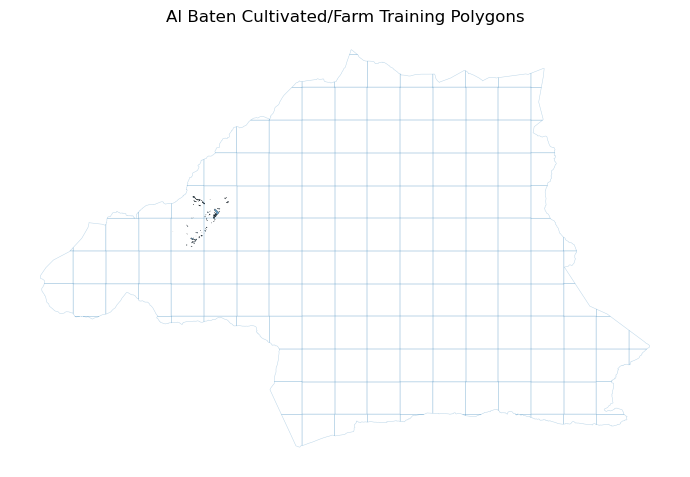

In [404]:
# 9. Visualize the two cultivation datasets
fig, ax = plt.subplots(
    figsize=(7, 5)
)

field_grid.boundary.plot(
    ax=ax,
    linewidth=0.35,
    alpha=0.30
)

albaten.plot(
    ax=ax,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.25
)

ax.set_title(
    "Al Baten Cultivated/Farm Training Polygons"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

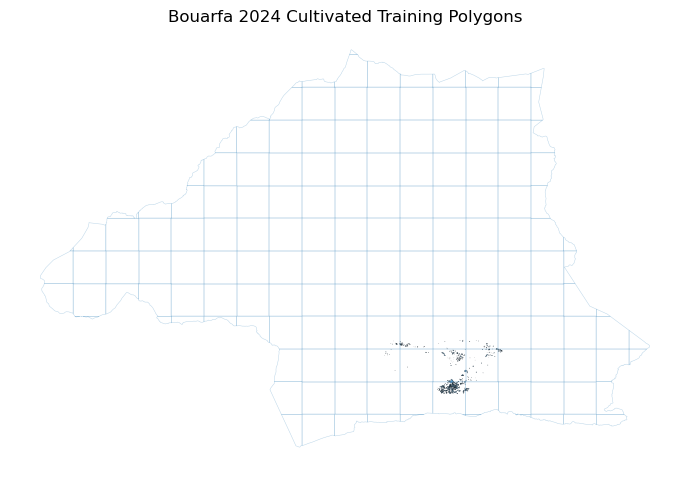

In [405]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

field_grid.boundary.plot(
    ax=ax,
    linewidth=0.35,
    alpha=0.30
)

bouarfa.plot(
    ax=ax,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.20
)

ax.set_title(
    "Bouarfa 2024 Cultivated Training Polygons"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [406]:
# 10. Combined cultivation summary
cultivated_training = (
    gpd.GeoDataFrame(
        pd.concat(
            [
                albaten,
                bouarfa
            ],
            ignore_index=True
        ),
        geometry="geometry",
        crs=field_grid.crs
    )
)

cult_summary = (
    cultivated_training
    .groupby("source")
    .agg(
        n_polygons=(
            "sample_id",
            "size"
        ),

        n_sites=(
            "site_id",
            "nunique"
        ),

        n_grids=(
            "grid_id",
            "nunique"
        ),

        total_area_m2=(
            "poly_area",
            "sum"
        ),

        median_area_m2=(
            "poly_area",
            "median"
        )
    )
)

display(
    cult_summary.round(1)
)

,n_polygons,n_sites,n_grids,total_area_m2,median_area_m2
source,,,,,
ALBATEN_FARMS_2024,153,153,4,13978636.4,32514.4
BOUARFA_ANTHRO_2024,606,606,11,43600642.9,33383.3


In [407]:
# 11. Export the reviewed cultivation source
CULT_OUT = (
    ANTHRO_DIR
    / "Eastern_Morocco_Cultivated_Training_2024.gpkg"
)

if CULT_OUT.exists():
    CULT_OUT.unlink()

albaten.to_file(
    CULT_OUT,
    layer="albaten_farms_2024",
    driver="GPKG"
)

bouarfa.to_file(
    CULT_OUT,
    layer="bouarfa_cultivated_2024",
    driver="GPKG"
)

cultivated_training.to_file(
    CULT_OUT,
    layer="cultivated_combined",
    driver="GPKG"
)

cult_summary.to_csv(
    CULT_OUT.with_name(
        "Eastern_Morocco_Cultivated_Training_2024_summary.csv"
    )
)

print("Saved:")
print(CULT_OUT)

Saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Eastern_Morocco_Cultivated_Training_2024.gpkg


### 3.1 HOT OSM BUILDINGS

In [374]:
# ============================================================
# HOT OSM BUILDINGS — FINAL PREPROCESSING
# ============================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Clean and project the building footprints
build = (
    build_raw[
        [
            "building",
            "osm_id",
            "Area_M2",
            "geometry"
        ]
    ]
    .copy()
)

# Project to the same metric CRS as the training grid
build = build.to_crs(
    field_grid.crs
)

# Clean building tag
build["building"] = (
    build["building"]
    .astype("string")
    .str.lower()
    .str.strip()
)

# Remove obvious ruins only
build = (
    build[
        build["building"] != "ruins"
    ]
    .copy()
)

# Geometry QC
geom_ok = build.geometry.apply(
    lambda g:
        g is not None
        and not g.is_empty
        and g.is_valid
)

build = (
    build[geom_ok]
    .copy()
)

# Recalculate area from projected geometry
build["bldg_area_m2"] = (
    build.geometry.area
)

print(
    "Usable building footprints:",
    len(build)
)

display(
    build["bldg_area_m2"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    ).round(1)
)

Usable building footprints: 2570


count     2570.0
mean       250.9
std       1124.8
min          2.2
10%         35.8
25%         70.9
50%        131.7
75%        238.0
90%        440.6
95%        670.5
max      50582.8
Name: bldg_area_m2, dtype: float64

In [375]:
# 2. Make 10 m neighborhood clusters
BUILDING_BUFFER_M = 10

build_buffered = (
    build[
        [
            "osm_id",
            "bldg_area_m2",
            "geometry"
        ]
    ]
    .copy()
)

build_buffered["geometry"] = (
    build_buffered.geometry
    .buffer(BUILDING_BUFFER_M)
)

cluster_union = (
    build_buffered.geometry
    .unary_union
)

clusters = gpd.GeoDataFrame(
    geometry=[cluster_union],
    crs=build.crs
)

clusters = (
    clusters
    .explode(
        index_parts=False
    )
    .reset_index(drop=True)
)

clusters["cluster_id"] = [
    f"BLDCL_{i:05d}"
    for i in range(
        1,
        len(clusters) + 1
    )
]

clusters["cluster_area_m2"] = (
    clusters.geometry.area
)

print(
    "Initial clusters:",
    len(clusters)
)

Initial clusters: 1123


In [376]:
# 3. Calculate actual building density
build_pts = (
    build[
        [
            "osm_id",
            "bldg_area_m2",
            "geometry"
        ]
    ]
    .copy()
)

build_pts["geometry"] = (
    build_pts.geometry
    .representative_point()
)

joined = gpd.sjoin(
    build_pts,
    clusters[
        [
            "cluster_id",
            "geometry"
        ]
    ],
    how="inner",
    predicate="within"
)

In [377]:
# Summarize:
cluster_stats = (
    joined
    .groupby("cluster_id")
    .agg(
        n_buildings=(
            "osm_id",
            "size"
        ),
        bldg_area_sum=(
            "bldg_area_m2",
            "sum"
        )
    )
    .reset_index()
)

clusters = (
    clusters
    .merge(
        cluster_stats,
        on="cluster_id",
        how="left"
    )
)

clusters[
    [
        "n_buildings",
        "bldg_area_sum"
    ]
] = (
    clusters[
        [
            "n_buildings",
            "bldg_area_sum"
        ]
    ]
    .fillna(0)
)

clusters["building_density"] = (
    clusters["bldg_area_sum"]
    /
    clusters["cluster_area_m2"]
)

In [378]:
# 4. Select Sentinel-2-usable clusters
MIN_CLUSTER_AREA = 900
MAX_CLUSTER_AREA = 50000

MIN_BUILDING_DENSITY = 0.20

MIN_BUILDINGS = 2
MIN_BUILDING_AREA = 400

built_candidates = (
    clusters[
        (
            clusters["cluster_area_m2"]
            >= MIN_CLUSTER_AREA
        )
        &
        (
            clusters["cluster_area_m2"]
            <= MAX_CLUSTER_AREA
        )
        &
        (
            clusters["building_density"]
            >= MIN_BUILDING_DENSITY
        )
        &
        (
            (
                clusters["n_buildings"]
                >= MIN_BUILDINGS
            )
            |
            (
                clusters["bldg_area_sum"]
                >= MIN_BUILDING_AREA
            )
        )
    ]
    .copy()
)

print(
    "Suitable Built-up candidate clusters:",
    len(built_candidates)
)

Suitable Built-up candidate clusters: 245


In [379]:
# 5. Assign spatial grid and choose representative sites
built_candidates = assign_grid(
    built_candidates,
    field_grid
)

# Score clusters:
built_candidates["selection_score"] = (
    built_candidates[
        "building_density"
    ]
    *
    np.log1p(
        built_candidates[
            "bldg_area_sum"
        ]
    )
)

# Rank within each 20-km cell:
built_candidates["grid_rank"] = (
    built_candidates
    .groupby("grid_id")[
        "selection_score"
    ]
    .rank(
        method="first",
        ascending=False
    )
)

# Keep up to 3 per grid:
MAX_PER_GRID = 3

built_selected = (
    built_candidates[
        built_candidates["grid_rank"]
        <= MAX_PER_GRID
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Selected Built-up polygons:",
    len(built_selected)
)

print(
    "20-km grids represented:",
    built_selected[
        "grid_id"
    ]
    .nunique()
)



Selected Built-up polygons: 107
20-km grids represented: 53


In [380]:
# 6. Add final metadata
built_selected["sample_id"] = [
    f"BLD_{i:04d}"
    for i in range(
        1,
        len(built_selected) + 1
    )
]

built_selected["site_id"] = (
    built_selected["cluster_id"]
)

built_selected["source_id"] = (
    built_selected["cluster_id"]
)

built_selected["class_raw"] = (
    "Built-up"
)

built_selected["class"] = (
    "Built-up"
)

built_selected["class_id"] = (
    CLASS_DICT["Built-up"]
)

built_selected["source"] = (
    "HOT_OSM_BUILDINGS"
)

built_selected["ref_year"] = 2025

built_selected["field_sup"] = 0

built_selected["confidence"] = 2

built_selected["geom_rule"] = (
    "OSM_BUILDING_CLUSTER"
)

built_selected["qc_status"] = (
    "FINAL_READY"
)

built_selected["use_status"] = (
    "TRAIN"
)

built_selected["poly_area"] = (
    built_selected.geometry.area
)

In [384]:
# 7. Quick diagnostic summary
display(
    built_selected[
        [
            "cluster_area_m2",
            "n_buildings",
            "bldg_area_sum",
            "building_density",
            "selection_score"
        ]
    ]
    .describe().round(1)
)

print(
    built_selected[
        "n_buildings"
    ]
    .value_counts()
    .sort_index()
    .head(20)
)

,cluster_area_m2,n_buildings,bldg_area_sum,building_density,selection_score
count,107.0,107.0,107.0,107.0,107.0
mean,4527.9,2.8,1688.4,0.3,2.5
std,5821.9,7.7,2222.8,0.1,0.9
min,1280.2,1.0,272.1,0.2,1.2
25%,2109.7,1.0,600.9,0.3,1.8
50%,2717.3,1.0,936.3,0.3,2.3
75%,4749.6,2.0,1938.0,0.4,2.9
max,41832.4,65.0,16274.6,0.6,5.5


n_buildings
1     66
2     23
3      9
4      3
6      1
10     2
13     1
48     1
65     1
Name: count, dtype: int64


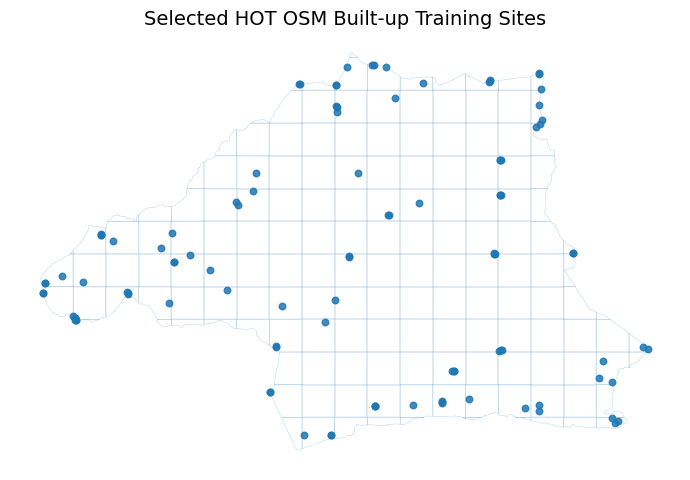

In [386]:
# 8. Visualize the selected set
built_pts = (
    built_selected.copy()
)

built_pts["geometry"] = (
    built_pts.geometry
    .representative_point()
)

fig, ax = plt.subplots(
    figsize=(7, 5)
)

field_grid.boundary.plot(
    ax=ax,
    linewidth=0.35,
    alpha=0.30
)

built_pts.plot(
    ax=ax,
    markersize=22,
    alpha=0.85
)

ax.set_title(
    "Selected HOT OSM Built-up Training Sites",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()


In [387]:
# 9. Export using the filename expected by the master merge
BUILD_OUT = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\build-up"
    r"\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg"
)

if BUILD_OUT.exists():
    BUILD_OUT.unlink()

    built_candidates.to_file(
    BUILD_OUT,
    layer="builtup_all_candidates",
    driver="GPKG"
)

built_selected.to_file(
    BUILD_OUT,
    layer="builtup_selected",
    driver="GPKG"
)

print("Saved:")
print(BUILD_OUT)

print(
    "\nSelected:",
    len(built_selected),
    "polygons"
)

print(
    "Spatial coverage:",
    built_selected["grid_id"].nunique(),
    "20-km grids"
)

Saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg

Selected: 107 polygons
Spatial coverage: 53 20-km grids


## Pre-processing for other datasources
```text
1. Trophic survey
   → field-supported candidate polygons

2. Hayat points
   → field-supported candidate polygons

3. Tamlelt interpreted polygons
   → polygon interiors

4. Al Baten ORIGINAL interpreted polygons
   → polygon interiors
   → retire 500-m buffer layer from primary training       - 

5. Waterways
   ├── lines → support Wadi geometry
   └── polygons → candidate Water after 2025 optical QC


In [220]:
import geopandas as gpd
import shapely

print("GeoPandas:", gpd.__version__)
print("Shapely:", shapely.__version__)

GeoPandas: 0.13.2
Shapely: 2.0.1


In [225]:
%pip install --upgrade "geopandas==1.1.4" "shapely>=2.0"

Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 0.14.0 Requires-Python >=3.9; 0.14.1 Requires-Python >=3.9; 0.14.2 Requires-Python >=3.9; 0.14.3 Requires-Python >=3.9; 0.14.4 Requires-Python >=3.9; 1.0.0 Requires-Python >=3.9; 1.0.0a1 Requires-Python >=3.9; 1.0.0rc1 Requires-Python >=3.9; 1.0.1 Requires-Python >=3.9; 1.1.0 Requires-Python >=3.10; 1.1.1 Requires-Python >=3.10; 1.1.2 Requires-Python >=3.10; 1.1.3 Requires-Python >=3.10; 1.1.4 Requires-Python >=3.10
ERROR: Could not find a version that satisfies the requirement geopandas==1.1.4 (from versions: 0.1.dev0, 0.1.0, 0.1.1, 0.2, 0.2.1, 0.3.0, 0.4.0, 0.4.1, 0.5.0, 0.5.1, 0.6.0rc1, 0.6.0, 0.6.1, 0.6.2, 0.6.3, 0.7.0, 0.8.0, 0.8.1, 0.8.2, 0.9.0, 0.10.0, 0.10.1, 0.10.2, 0.11.0, 0.11.1, 0.12.0, 0.12.1, 0.12.2, 0.13.0, 0.13.1, 0.13.2)
ERROR: No matching distribution found for geopandas==1.1.4


### `al_baten_habitat_mapping_polygon.shp`

### Workflow Pipeline

1. **Start from the original expert-interpreted habitat map**
2. **Standardize habitat classes** to the final 11-class legend
3. **Explode multipart features** into individual spatial habitat patches
4. **Separate habitat types by geometry and treatment**
   - **Areal habitats**: Grass steppe, Bare rocky, Spreading area, Salty steppe, Cultivated/fallow, etc.
   - **Linear habitats**: Wadi and gullies
   - **Built-up**: handled separately using the HOT building dataset

5. **Process areal habitats**
   - Remove a **15 m internal boundary zone** to reduce mixed and boundary pixels
   - Remove very small or narrow remnants
   - Select spatially separated **40 × 40 m training polygons** from homogeneous interiors
   - Limit the number of samples contributed by each large source polygon

6. **Process Wadi and gullies separately**
   - Retain the **original interpreted Wadi polygon geometry** without inward erosion
   - Use HOT OSM waterway lines only as **sampling guides**
   - Select representative locations along the drainage network with spatial separation
   - Create local review windows around selected locations
   - Extract short Wadi segments directly from the **original interpreted polygon boundaries**

7. **Combine the selected areal and Wadi candidate polygons**
8. **Assign provenance and spatial metadata**
   - `sample_id`
   - `site_id`
   - `source_id`
   - `class`
   - `class_id`
   - `grid_id`
   - `geom_rule`
   - `confidence`
   - `qc_status`
   - `use_status`

9. **Evaluate class balance and spatial representation**
10. **Check cross-class overlaps and potential conflicts**
11. **Review all candidates in ArcGIS/VHR imagery**
   - Confirm habitat class
   - Refine or reshape polygon boundaries where necessary
   - Exclude mixed or uncertain samples

12. **Retain accepted polygons and merge them into `training_candidates`**

### Compact Workflow

```text
Original expert-interpreted habitat map
                ↓
      Standardize habitat classes
                ↓
        Explode multipart features
                ↓
      Separate geometry treatments
        ↙                       ↘
  AREAL HABITATS              WADI / GULLIES
        ↓                           ↓
15 m inward edge removal     OSM waterway-guided
        ↓                    location selection
Remove small remnants              ↓
        ↓                    Spatial thinning
40 × 40 m interior patches         ↓
        ↓                    Local review windows
Spatial separation                  ↓
        ↓                    Extract original Wadi
        ↓                    polygon segments
        └────────────┬──────────────┘
                     ↓
           Combined candidates
                     ↓
       Class + spatial + conflict QC
                     ↓
            ArcGIS / VHR review
                     ↓
        Accepted training polygons
                     ↓
          Merge with `training_candidates`

### AREAL HABITATS

In [241]:
# ============================================================
# AL BATEN TRAINING POLYGON WORKFLOW
# STEP 1 — SETUP
# ============================================================

from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from shapely.geometry import Point, box


# ------------------------------------------------------------
# Input
# ------------------------------------------------------------

ALBATEN_PATH = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles"
    r"\habitat_mapping\al_baten_habitat_mapping_polygon.shp"
)

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

ALBATEN_OUT = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\Al_Baten_Training_2025.gpkg"
)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

EDGE_BUFFER_M = 15

PATCH_SIZE_M = 40

# Source polygon needs sufficient homogeneous interior
MIN_SAFE_AREA_M2 = 2500

# Minimum separation among training patches
MIN_SEPARATION_M = 300

# Avoid one enormous interpreted polygon dominating
MAX_PATCHES_PER_PART = 5

RANDOM_SEED = 42

In [242]:
# ============================================================
# STEP 2 — LOAD
# ============================================================

albaten_raw = gpd.read_file(
    ALBATEN_PATH
)

albaten_raw = albaten_raw.to_crs(
    work_crs
).copy()

print("Original records:", len(albaten_raw))
print("CRS:", albaten_raw.crs)

print("\nColumns:")
print(albaten_raw.columns.tolist())

print("\nOriginal habitat classes:")
print(
    albaten_raw["Habitat"]
    .value_counts(dropna=False)
)

Original records: 9
CRS: EPSG:32630

Columns:
['Habitat', 'digitaliza', 'imagery', 'Shape_Leng', 'Shape_Area', 'geometry']

Original habitat classes:
Habitat
Alfah-grass steppe                  1
Alluvial silt plain                 1
Building                            1
Flooded wadi                        1
Perennial herbaceous cultivation    1
Reg                                 1
Salty steppe                        1
Tree farming                        1
Wadi                                1
Name: count, dtype: int64


In [244]:
albaten_raw = albaten_raw.reset_index(drop=True)

albaten_raw["orig_id"] = [
    f"AB_ORIG_{i:03d}"
    for i in range(1, len(albaten_raw) + 1)
]

display(albaten_raw)

,Habitat,digitaliza,imagery,Shape_Leng,Shape_Area,geometry,orig_id
0,Alfah-grass steppe,1/3000,DigitalGlobe - Worldview 2 - provided by ESRI ...,7.857130e+05,6449.127971,"MULTIPOLYGON (((396089.065 3669999.868, 396059...",AB_ORIG_001
1,Alluvial silt plain,1/10000,DigitalGlobe - Worldview 2 - provided by ESRI ...,2.072938e+06,10448.112991,"MULTIPOLYGON (((405385.934 3660015.070, 405358...",AB_ORIG_002
2,Building,1/10000,DigitalGlobe - Worldview 2 - provided by ESRI ...,7.356394e+02,3.334135,"POLYGON ((408087.149 3660267.146, 408066.512 3...",AB_ORIG_003
3,Flooded wadi,1/10000,DigitalGlobe - Worldview 2 - provided by ESRI ...,6.153990e+03,48.023174,"POLYGON ((429999.995 3681499.348, 429978.505 3...",AB_ORIG_004
4,Perennial herbaceous cultivation,1/10000,DigitalGlobe - Worldview 2 - provided by ESRI ...,4.400838e+03,14.054830,"MULTIPOLYGON (((422852.703 3678727.628, 422885...",AB_ORIG_005
5,Reg,1/10000,DigitalGlobe - Worldview 2 - provided by ESRI ...,3.178305e+06,37217.558475,"MULTIPOLYGON (((405616.994 3660000.000, 405570...",AB_ORIG_006
6,Salty steppe,1/10000,DigitalGlobe - Worldview 2 - provided by ESRI ...,2.016110e+04,30.009071,"MULTIPOLYGON (((402267.634 3669317.969, 402286...",AB_ORIG_007
7,Tree farming,1/10000,DigitalGlobe - Worldview 2 - provided by ESRI ...,7.189958e+04,594.316157,"MULTIPOLYGON (((408416.092 3660061.758, 408406...",AB_ORIG_008
8,Wadi,1/10000,DigitalGlobe - Worldview 2 - provided by ESRI ...,5.855284e+05,1064.918975,"MULTIPOLYGON (((405072.049 3660784.509, 405100...",AB_ORIG_009


In [245]:
# ============================================================
# STEP 3 — CLASS HARMONIZATION
# ============================================================

ALBATEN_CLASS_MAP = {
    "Alfah-grass steppe":"Grass steppe",
    "Perennial herbaceous cultivation":"Grass steppe",
    "Alluvial silt plain":"Spreading area",
    "Reg":"Bare rocky",
    "Salty steppe":"Salty steppe",
    "Tree farming":"Cultivated field/fallow",
    "Wadi":"Wadi and gullies",
    "Flooded wadi":"Wadi and gullies",
    "Building":"Built-up"
}

albaten_raw["class"] = (
    albaten_raw["Habitat"]
    .map(ALBATEN_CLASS_MAP)
)

In [246]:
unmapped = (
    albaten_raw[
        albaten_raw["class"].isna()
    ]["Habitat"]
    .value_counts(dropna=False)
)

print("Unmapped Al Baten labels:")
print(unmapped)

Unmapped Al Baten labels:
Series([], Name: count, dtype: int64)


In [247]:
# ============================================================
# STEP 4 — SEPARATE SPECIAL CLASSES
# ============================================================

albaten_builtup = albaten_raw[
    albaten_raw["class"] == "Built-up"
].copy()

albaten_wadi = albaten_raw[
    albaten_raw["class"] == "Wadi and gullies"
].copy()

albaten_areal = albaten_raw[
    albaten_raw["class"].notna()
    &
    ~albaten_raw["class"].isin(
        [
            "Built-up",
            "Wadi and gullies"
        ]
    )
].copy()

print("Areal habitat records:",len(albaten_areal))
print("Wadi records:",len(albaten_wadi))
print("Built-up records excluded:",len(albaten_builtup))

Areal habitat records: 6
Wadi records: 2
Built-up records excluded: 1


In [248]:
# ============================================================
# STEP 5 — EXPLODE INTO INDIVIDUAL HABITAT PATCHES
# ============================================================

albaten_parts = (
    albaten_areal
    .explode(index_parts=False)
    .reset_index(drop=True)
)

albaten_parts["part_id"] = [
    f"AB_PART_{i:05d}"
    for i in range(1, len(albaten_parts) + 1)
]

albaten_parts["part_area_m2"] = (
    albaten_parts.geometry.area
)

print(
    "Individual areal habitat patches:",
    len(albaten_parts)
)

print("\nPatches by class:")

print(
    albaten_parts["class"]
    .value_counts()
)

Individual areal habitat patches: 4374

Patches by class:
class
Bare rocky                 2578
Spreading area              965
Grass steppe                720
Cultivated field/fallow      63
Salty steppe                 48
Name: count, dtype: int64


In [251]:
# ============================================================
# STEP 6 — SAFE INTERIORS: apply the 15-m inward buffer
# ============================================================

albaten_safe = albaten_parts.copy()

n_before = len(albaten_safe)

print(
    "Before edge removal:",
    n_before
)

albaten_safe["geometry"] = (
    albaten_safe.geometry
    .buffer(-EDGE_BUFFER_M)
)

Before edge removal: 4374


In [252]:
geom_ok = (
    albaten_safe.geometry.apply(
        lambda g:
            g is not None
            and not g.is_empty
            and g.is_valid
    )
)

albaten_safe = (
    albaten_safe[
        geom_ok
    ]
    .copy()
)

albaten_safe["safe_area_m2"] = (
    albaten_safe.geometry.area
)

n_after = len(albaten_safe)

print(
    "After edge removal:",
    n_after
)

print(
    "Removed because empty/invalid:",
    n_before - n_after
)

print(
    f"Survival rate: "
    f"{n_after / n_before * 100:.1f}%"
)

After edge removal: 2466
Removed because empty/invalid: 1908
Survival rate: 56.4%


In [253]:
# ============================================================
# STEP 7 — CLASS-LEVEL EDGE-REMOVAL DIAGNOSTIC
# ============================================================

before_class = (
    albaten_parts["class"]
    .value_counts()
    .rename("n_before")
)

after_class = (
    albaten_safe["class"]
    .value_counts()
    .rename("n_after")
)

edge_summary = pd.concat(
    [
        before_class,
        after_class
    ],
    axis=1
).fillna(0)

edge_summary["n_removed"] = (
    edge_summary["n_before"]
    -
    edge_summary["n_after"]
)

edge_summary["retained_pct"] = (
    edge_summary["n_after"]
    /
    edge_summary["n_before"]
    * 100
)

display(
    edge_summary
    .round(1)
)

,n_before,n_after,n_removed,retained_pct
class,,,,
Bare rocky,2578,1486,1092,57.6
Spreading area,965,597,368,61.9
Grass steppe,720,295,425,41.0
Cultivated field/fallow,63,61,2,96.8
Salty steppe,48,27,21,56.2


In [254]:
# ============================================================
# STEP 8 — MINIMUM INTERIOR SIZE
# ============================================================

albaten_safe["safe_area_m2"] = (
    albaten_safe.geometry.area
)

albaten_usable = albaten_safe[
    albaten_safe["safe_area_m2"]
    >= MIN_SAFE_AREA_M2
].copy()

print(
    "Safe interiors before area filter:",
    len(albaten_safe)
)

print(
    "Usable source patches:",
    len(albaten_usable)
)

print(
    "Removed by minimum-area filter:",
    len(albaten_safe)
    -
    len(albaten_usable)
)

print("\nUsable patches by class:")

print(
    albaten_usable["class"]
    .value_counts()
)

Safe interiors before area filter: 2466
Usable source patches: 870
Removed by minimum-area filter: 1596

Usable patches by class:
class
Bare rocky                 523
Spreading area             209
Grass steppe                82
Cultivated field/fallow     48
Salty steppe                 8
Name: count, dtype: int64


In [255]:
# ============================================================
# STEP 9 — SAMPLE QUOTA PER SOURCE PATCH
# small habitat patch        → 1 training polygon
# medium patch               → 2
# large patch                → 3
# very large patch           → max 5
# ============================================================

def samples_for_area(area_m2):

    if area_m2 < 50_000:
        return 1

    elif area_m2 < 250_000:
        return 2

    elif area_m2 < 1_000_000:
        return 3

    else:
        return MAX_PATCHES_PER_PART

In [256]:
# ============================================================
# STEP 10 — RANDOM SPATIALLY SEPARATED TRAINING PATCHES
# ============================================================

def sample_square_patches(
    polygon,
    n,
    patch_size=40,
    min_distance=300,
    max_attempts=10000,
    seed=42
):

    rng = np.random.default_rng(seed)

    minx, miny, maxx, maxy = (
        polygon.bounds
    )

    half = patch_size / 2

    selected_centers = []
    selected_squares = []

    attempts = 0

    while (
        len(selected_squares) < n
        and attempts < max_attempts
    ):

        x = rng.uniform(
            minx,
            maxx
        )

        y = rng.uniform(
            miny,
            maxy
        )

        center = Point(x, y)

        # Center must be within safe habitat
        if not polygon.contains(center):

            attempts += 1
            continue

        square = box(
            x - half,
            y - half,
            x + half,
            y + half
        )

        # Entire training polygon must lie
        # inside the safe interpreted habitat
        if not polygon.covers(square):

            attempts += 1
            continue

        # Maintain spacing between samples
        if selected_centers:

            too_close = any(
                center.distance(existing)
                <
                min_distance

                for existing
                in selected_centers
            )

            if too_close:

                attempts += 1
                continue

        selected_centers.append(
            center
        )

        selected_squares.append(
            square
        )

        attempts += 1

    return selected_squares

In [257]:
# ============================================================
# STEP 11 — GENERATE AL BATEN TRAINING PATCHES
# ============================================================

training_records = []

for idx, row in albaten_usable.iterrows():

    n_samples = samples_for_area(
        row["safe_area_m2"]
    )

    squares = sample_square_patches(
        polygon=row.geometry,
        n=n_samples,
        patch_size=PATCH_SIZE_M,
        min_distance=MIN_SEPARATION_M,
        seed=RANDOM_SEED + idx
    )

    for j, geom in enumerate(
        squares,
        start=1
    ):

        training_records.append({

            "orig_id":
                row["orig_id"],

            "part_id":
                row["part_id"],

            "Habitat":
                row["Habitat"],

            "class":
                row["class"],

            "source_part_area_m2":
                row["part_area_m2"],

            "safe_area_m2":
                row["safe_area_m2"],

            "patch_no":
                j,

            "geometry":
                geom
        })


albaten_train = gpd.GeoDataFrame(
    training_records,
    geometry="geometry",
    crs=work_crs
)

print(
    "Generated Al Baten training polygons:",
    len(albaten_train)
)

print("\nTraining polygons by class:")

print(
    albaten_train["class"]
    .value_counts()
)

Generated Al Baten training polygons: 789

Training polygons by class:
class
Bare rocky                 487
Spreading area             160
Grass steppe                86
Cultivated field/fallow     54
Salty steppe                 2
Name: count, dtype: int64


In [258]:
# ============================================================
# STEP 12 — SAMPLING SUCCESS
# This is useful for narrow/irregular habitats.
# ============================================================

sampled_parts = set(
    albaten_train["part_id"]
)

albaten_usable[
    "sample_generated"
] = (
    albaten_usable["part_id"]
    .isin(sampled_parts)
)

print(
    albaten_usable[
        "sample_generated"
    ]
    .value_counts()
)

sample_generated
True     536
False    334
Name: count, dtype: int64


In [259]:
sampling_success = (
    albaten_usable
    .groupby("class")
    ["sample_generated"]
    .agg(
        n_parts="size",
        n_sampled="sum"
    )
)

sampling_success[
    "success_pct"
] = (
    sampling_success["n_sampled"]
    /
    sampling_success["n_parts"]
    * 100
)

display(
    sampling_success.round(1)
)

,n_parts,n_sampled,success_pct
class,,,
Bare rocky,523,326,62.3
Cultivated field/fallow,48,41,85.4
Grass steppe,82,50,61.0
Salty steppe,8,2,25.0
Spreading area,209,117,56.0


In [260]:
# ============================================================
# STEP 13 — STANDARD METADATA
# ============================================================

albaten_train = (
    albaten_train
    .reset_index(drop=True)
)

albaten_train["sample_id"] = [
    f"ABTR_{i:05d}"
    for i in range(
        1,
        len(albaten_train) + 1
    )
]

# Each disconnected interpreted patch is an
# independent source site
albaten_train["site_id"] = (
    albaten_train["part_id"]
)

albaten_train["source_id"] = (
    albaten_train["part_id"]
)

albaten_train["class_id"] = (
    albaten_train["class"]
    .map(CLASS_DICT)
)

albaten_train["source"] = (
    "ALBATEN_INTERPRETED_MAP"
)

albaten_train["ref_year"] = pd.NA

albaten_train["field_sup"] = 0

albaten_train["confidence"] = 3

albaten_train["geom_rule"] = (
    "INTERPRETED_MAP_40M_PATCH"
)

albaten_train["qc_status"] = (
    "UNREVIEWED"
)

albaten_train["use_status"] = (
    "CANDIDATE"
)

albaten_train["poly_area"] = (
    albaten_train.geometry.area
)

In [261]:
albaten_train = assign_grid(
    albaten_train,
    field_grid
)

In [262]:
# ============================================================
# STEP 14 — SUMMARY
# ============================================================

albaten_summary = (
    albaten_train
    .groupby("class")
    .agg(

        n_polygons=(
            "sample_id",
            "size"
        ),

        n_sites=(
            "site_id",
            "nunique"
        ),

        n_grids=(
            "grid_id",
            "nunique"
        ),

        total_area_m2=(
            "poly_area",
            "sum"
        ),

        median_area_m2=(
            "poly_area",
            "median"
        )
    )
    .sort_values(
        "n_polygons",
        ascending=False
    )
)

display(
    albaten_summary.round(1)
)

,n_polygons,n_sites,n_grids,total_area_m2,median_area_m2
class,,,,,
Bare rocky,487,326,4,779200.0,1600.0
Spreading area,160,117,4,256000.0,1600.0
Grass steppe,86,50,4,137600.0,1600.0
Cultivated field/fallow,54,41,3,86400.0,1600.0
Salty steppe,2,2,1,3200.0,1600.0


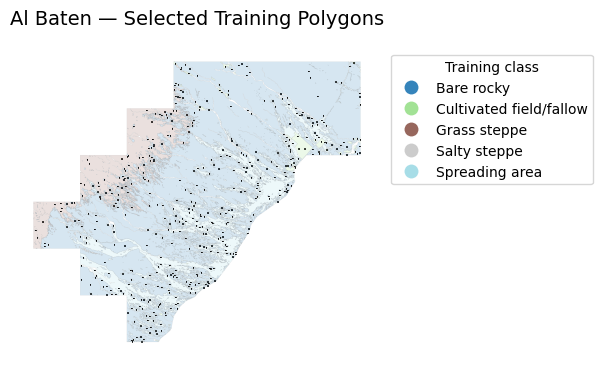

In [300]:
# ============================================================
# STEP 15 — VISUALIZE
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)

# Original interpreted map
albaten_areal.plot(
    ax=ax,
    column="class",
    categorical=True,
    cmap="tab20",
    alpha=0.18,
    edgecolor="gray",
    linewidth=0.2
)

# Selected training polygons
albaten_train.plot(
    ax=ax,
    column="class",
    categorical=True,
    cmap="tab20",
    alpha=0.90,
    edgecolor="black",
    linewidth=0.6,
    legend=True,
    legend_kwds={
        "title":
            "Training class",

        "bbox_to_anchor":
            (1.02, 1),

        "loc":
            "upper left"
    }
)

ax.set_title(
    "Al Baten — Selected Training Polygons",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()

plt.show()

In [264]:
# ============================================================
# STEP 16 — EXPORT FOR ARCGIS REVIEW
# ============================================================

# Main candidate training polygons
albaten_train.to_file(
    ALBATEN_OUT,
    layer="training_patches",
    driver="GPKG"
)

# Safe interpreted interiors
albaten_safe.to_file(
    ALBATEN_OUT,
    layer="safe_interiors",
    driver="GPKG"
)

# Usable source patches
albaten_usable.to_file(
    ALBATEN_OUT,
    layer="usable_source_patches",
    driver="GPKG"
)

# Wadi polygons for separate review
if len(albaten_wadi) > 0:

    albaten_wadi.to_file(
        ALBATEN_OUT,
        layer="wadi_review",
        driver="GPKG"
    )

print("Saved:")
print(ALBATEN_OUT)

Saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\Al_Baten_Training_2025.gpkg


### WADI / GULLIES
1. **Input Data Integration**
   - Original interpreted Wadi polygon
   - HOT OSM waterway centerlines
2. **Intersect lines with Wadi polygons**
3. **Sample locations along drainage network**
4. **Apply constraints:**
   - Minimum spatial separation
   - Local spatial stratification
5. **Create local review windows**
6. **Clip ORIGINAL Wadi polygon** around each selected location
7. **Generate short local Wadi polygon segments**
8. **ArcGIS / VHR review** + trace/refine edges
9. **Final Wadi training polygons**


- HOT OSM line
    - determines WHERE to sample
- Original expert Wadi polygon
    - determines WHAT the habitat boundary is
- VHR/ArcGIS review
    - determines whether the local segment is actually clean

In [266]:
# ============================================================
# WADI WORKFLOW
# STEP 1 — EXTRACT ORIGINAL WADI POLYGONS
# ============================================================

wadi_source = albaten_raw[
    albaten_raw["Habitat"].isin(
        [
            "Wadi",
            "Flooded wadi"
        ]
    )
].copy()

print(
    "Original Wadi records:",
    len(wadi_source)
)

print(
    wadi_source["Habitat"]
    .value_counts()
)

Original Wadi records: 2
Habitat
Flooded wadi    1
Wadi            1
Name: count, dtype: int64


In [267]:
if "orig_id" not in wadi_source.columns:

    wadi_source = (
        wadi_source
        .reset_index(drop=True)
    )

    wadi_source["orig_id"] = [
        f"AB_WADI_ORIG_{i:03d}"
        for i in range(
            1,
            len(wadi_source) + 1
        )
    ]

In [270]:
# ============================================================
# STEP 2 — EXPLODE INTO INDIVIDUAL WADI COMPONENTS
# ============================================================

wadi_parts = (
    wadi_source
    .explode(
        index_parts=False
    )
    .reset_index(drop=True)
)

wadi_parts["wadi_part_id"] = [
    f"AB_WADI_PART_{i:05d}"
    for i in range(
        1,
        len(wadi_parts) + 1
    )
]

wadi_parts["part_area_m2"] = (
    wadi_parts.geometry.area
)

print(
    "Individual Wadi polygon components:",
    len(wadi_parts)
)

display(
    wadi_parts["part_area_m2"]
    .describe().round(1)
)

Individual Wadi polygon components: 96


count         96.0
mean      115860.9
std       280579.3
min          173.2
25%         5322.3
50%        14168.9
75%        47290.4
max      1632324.4
Name: part_area_m2, dtype: float64

In [271]:
# ============================================================
# STEP 3 — LOAD WATERWAY GUIDE LINES
# ============================================================

from pathlib import Path
import geopandas as gpd

water_dir = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\waterbody"
)

hot_lines = gpd.read_file(
    water_dir /
    "hotosm_mar_waterways_lines_EM.shp"
)

hot_lines = hot_lines.to_crs(
    work_crs
).copy()

print(
    "HOT waterway lines:",
    len(hot_lines)
)

print(
    hot_lines.columns.tolist()
)

HOT waterway lines: 1787
['width', 'tunnel', 'natural', 'osm_id', 'Length', 'class', 'geometry']


In [273]:
if "waterway" in hot_lines.columns:

    artificial_types = {
        "canal",
        "ditch",
        "drain"
    }

    hot_lines["waterway_clean"] = (
        hot_lines["waterway"]
        .astype("string")
        .str.lower()
        .str.strip()
    )

    hot_lines_nat = hot_lines[
        ~hot_lines["waterway_clean"]
        .isin(artificial_types)
    ].copy()

else:

    hot_lines_nat = (
        hot_lines.copy()
    )

In [274]:
# ============================================================
# STEP 4 — WATERWAY GUIDES INSIDE INTERPRETED WADI
# ============================================================

wadi_union = (
    wadi_parts.geometry
    .unary_union
)

wadi_mask = gpd.GeoDataFrame(
    {
        "mask_id": [1]
    },
    geometry=[wadi_union],
    crs=work_crs
)

wadi_guides = gpd.overlay(
    hot_lines_nat,
    wadi_mask,
    how="intersection",
    keep_geom_type=False
)

In [275]:
wadi_guides = (
    wadi_guides
    .explode(
        index_parts=False
    )
    .reset_index(drop=True)
)

# Keep actual lines only
wadi_guides = wadi_guides[
    wadi_guides.geometry.geom_type
    .isin(
        [
            "LineString"
        ]
    )
].copy()

wadi_guides["guide_id"] = [
    f"WG_{i:05d}"
    for i in range(
        1,
        len(wadi_guides) + 1
    )
]

wadi_guides["guide_length_m"] = (
    wadi_guides.geometry.length
)

print(
    "Waterway guide segments inside "
    "interpreted Wadi polygons:",
    len(wadi_guides)
)

Waterway guide segments inside interpreted Wadi polygons: 212


In [276]:
MIN_GUIDE_LENGTH_M = 50

wadi_guides = wadi_guides[
    wadi_guides["guide_length_m"]
    >= MIN_GUIDE_LENGTH_M
].copy()

print(
    "Usable guide lines:",
    len(wadi_guides)
)

Usable guide lines: 172


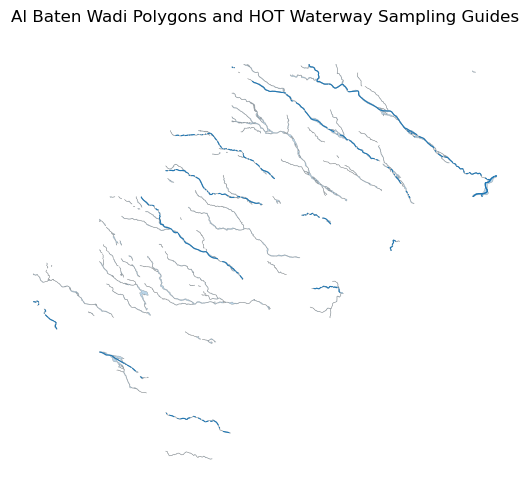

In [278]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(6, 5)
)

wadi_parts.plot(
    ax=ax,
    alpha=0.30,
    edgecolor="black",
    linewidth=0.3
)

wadi_guides.plot(
    ax=ax,
    linewidth=0.8
)

ax.set_title(
    "Al Baten Wadi Polygons and HOT Waterway Sampling Guides"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [279]:
# ============================================================
# STEP 6 — GENERATE CANDIDATE ANCHOR LOCATIONS
# using 300 m spacing
# ============================================================

POINT_SPACING_M = 300

def sample_points_along_line(
    line,
    spacing=300
):

    length = line.length

    if length <= 0:
        return []

    # For short segments, use midpoint
    if length < spacing:

        return [
            line.interpolate(
                0.5,
                normalized=True
            )
        ]

    # Start half-spacing from end
    distances = np.arange(
        spacing / 2,
        length,
        spacing
    )

    return [
        line.interpolate(d)
        for d in distances
    ]

# Generate candidates:
candidate_records = []

for idx, row in wadi_guides.iterrows():

    pts = sample_points_along_line(
        row.geometry,
        spacing=POINT_SPACING_M
    )

    for p in pts:

        candidate_records.append(
            {
                "guide_id":
                    row["guide_id"],

                "guide_length_m":
                    row["guide_length_m"],

                "geometry":
                    p
            }
        )


wadi_candidate_pts = (
    gpd.GeoDataFrame(
        candidate_records,
        geometry="geometry",
        crs=work_crs
    )
)

print(
    "Initial Wadi candidate locations:",
    len(wadi_candidate_pts)
)

Initial Wadi candidate locations: 293


In [280]:
# ============================================================
# STEP 7 — SPATIAL THINNING
# Initial distance: 300 m
# Remove locations that are too close to each other
# Because OSM lines are often split into many short segments, 
# otherwise can get several points clustered around junctions.
# ============================================================

MIN_SITE_DISTANCE_M = 300

def thin_points(
    gdf,
    min_distance=300
):

    # Longer guide segments first
    gdf_sorted = (
        gdf
        .sort_values(
            "guide_length_m",
            ascending=False
        )
        .copy()
    )

    selected_idx = []
    selected_xy = []

    for idx, row in gdf_sorted.iterrows():

        x = row.geometry.x
        y = row.geometry.y

        if len(selected_xy) == 0:

            selected_idx.append(idx)
            selected_xy.append((x, y))
            continue

        xy = np.array(selected_xy)

        distances = np.sqrt(
            (xy[:, 0] - x) ** 2
            +
            (xy[:, 1] - y) ** 2
        )

        if distances.min() >= min_distance:

            selected_idx.append(idx)
            selected_xy.append((x, y))

    return (
        gdf_sorted
        .loc[selected_idx]
        .copy()
    )

In [281]:
wadi_thinned_pts = thin_points(
    wadi_candidate_pts,
    min_distance=MIN_SITE_DISTANCE_M
)

print(
    "After 300-m spatial thinning:",
    len(wadi_thinned_pts)
)

After 300-m spatial thinning: 146


In [282]:
# ============================================================
# STEP 8 — LOCAL 2-km SAMPLING GRID
# use a 2 × 2 km local grid
# ============================================================

from shapely.geometry import box

LOCAL_GRID_M = 2000

minx, miny, maxx, maxy = (
    wadi_parts.total_bounds
)

cells = []

cell_no = 1

for x in np.arange(
    minx,
    maxx,
    LOCAL_GRID_M
):

    for y in np.arange(
        miny,
        maxy,
        LOCAL_GRID_M
    ):

        cells.append(
            {
                "local_grid":
                    f"ABG_{cell_no:03d}",

                "geometry":
                    box(
                        x,
                        y,
                        x + LOCAL_GRID_M,
                        y + LOCAL_GRID_M
                    )
            }
        )

        cell_no += 1


albaten_local_grid = (
    gpd.GeoDataFrame(
        cells,
        geometry="geometry",
        crs=work_crs
    )
)

In [283]:
wadi_thinned_pts = (
    gpd.sjoin(
        wadi_thinned_pts,
        albaten_local_grid[
            [
                "local_grid",
                "geometry"
            ]
        ],
        how="left",
        predicate="within"
    )
    .drop(
        columns="index_right",
        errors="ignore"
    )
)

In [284]:
MAX_PER_LOCAL_GRID = 2

wadi_selected_pts = (
    wadi_thinned_pts
    .sort_values(
        [
            "local_grid",
            "guide_length_m"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "local_grid",
        group_keys=False
    )
    .head(
        MAX_PER_LOCAL_GRID
    )
    .copy()
)

wadi_selected_pts = (
    wadi_selected_pts
    .reset_index(drop=True)
)

wadi_selected_pts[
    "sample_id"
] = [
    f"ABW_{i:04d}"
    for i in range(
        1,
        len(wadi_selected_pts) + 1
    )
]

print(
    "Final selected Wadi locations:",
    len(wadi_selected_pts)
)

print(
    "Local 2-km cells represented:",
    wadi_selected_pts[
        "local_grid"
    ].nunique()
)

Final selected Wadi locations: 89
Local 2-km cells represented: 54


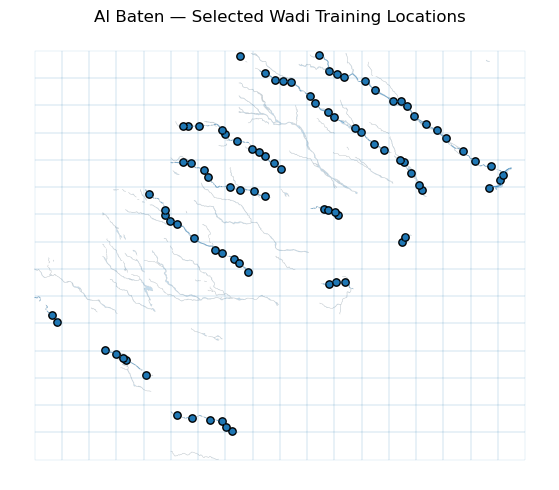

In [286]:
# ============================================================
# STEP 9 — VISUALIZE SELECTED LOCATIONS
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)

wadi_parts.plot(
    ax=ax,
    alpha=0.25,
    edgecolor="gray",
    linewidth=0.25
)

wadi_guides.plot(
    ax=ax,
    linewidth=0.6,
    alpha=0.5
)

wadi_selected_pts.plot(
    ax=ax,
    markersize=28,
    edgecolor="black"
)

albaten_local_grid.boundary.plot(
    ax=ax,
    linewidth=0.3,
    alpha=0.25
)

ax.set_title(
    "Al Baten — Selected Wadi Training Locations"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [287]:
# ============================================================
# STEP 10 — REVIEW WINDOWS
# ============================================================

WINDOW_SIZE_M = 200
HALF_WINDOW = WINDOW_SIZE_M / 2

wadi_windows = (
    wadi_selected_pts.copy()
)

wadi_windows["geometry"] = (
    wadi_windows.geometry.apply(
        lambda p:
        box(
            p.x - HALF_WINDOW,
            p.y - HALF_WINDOW,
            p.x + HALF_WINDOW,
            p.y + HALF_WINDOW
        )
    )
)

wadi_windows = gpd.GeoDataFrame(
    wadi_windows,
    geometry="geometry",
    crs=work_crs
)

In [288]:
# ============================================================
# STEP 11 — LINK ANCHORS TO ORIGINAL WADI COMPONENT
# ============================================================

anchor_source = gpd.sjoin(
    wadi_selected_pts,
    wadi_parts[
        [
            "wadi_part_id",
            "orig_id",
            "Habitat",
            "geometry"
        ]
    ],
    how="left",
    predicate="intersects"
)

anchor_source = (
    anchor_source
    .drop(
        columns="index_right",
        errors="ignore"
    )
)

In [289]:
print(
    "Locations without matching Wadi polygon:",
    anchor_source[
        "wadi_part_id"
    ].isna().sum()
)

Locations without matching Wadi polygon: 0


In [290]:
# ============================================================
# STEP 12 — CREATE DRAFT LOCAL WADI POLYGONS
# Extract local Wadi segments from the ORIGINAL polygon
# ============================================================

wadi_part_lookup = (
    wadi_parts
    .set_index(
        "wadi_part_id"
    )
)

In [291]:
def polygon_parts_from_geometry(
    geom
):

    if (
        geom is None
        or geom.is_empty
    ):
        return []

    if geom.geom_type == "Polygon":

        return [geom]

    if geom.geom_type == "MultiPolygon":

        return list(
            geom.geoms
        )

    if geom.geom_type == "GeometryCollection":

        polygons = []

        for g in geom.geoms:

            if g.geom_type == "Polygon":

                polygons.append(g)

            elif g.geom_type == "MultiPolygon":

                polygons.extend(
                    list(g.geoms)
                )

        return polygons

    return []

In [292]:
draft_records = []

for _, row in anchor_source.iterrows():

    part_id = row["wadi_part_id"]

    if pd.isna(part_id):
        continue

    source_geom = (
        wadi_part_lookup
        .loc[part_id]
        .geometry
    )

    point_geom = row.geometry

    window_geom = box(
        point_geom.x - HALF_WINDOW,
        point_geom.y - HALF_WINDOW,
        point_geom.x + HALF_WINDOW,
        point_geom.y + HALF_WINDOW
    )

    clipped = (
        source_geom
        .intersection(
            window_geom
        )
    )

    pieces = (
        polygon_parts_from_geometry(
            clipped
        )
    )

    if len(pieces) == 0:
        continue

    # Prefer polygon containing the anchor;
    # otherwise use the nearest polygon piece
    containing = [
        p
        for p in pieces
        if p.buffer(0.5).contains(
            point_geom
        )
    ]

    if containing:

        selected_geom = max(
            containing,
            key=lambda g: g.area
        )

    else:

        selected_geom = min(
            pieces,
            key=lambda g:
                g.distance(
                    point_geom
                )
        )

    draft_records.append(
        {
            "sample_id":
                row["sample_id"],

            "wadi_part_id":
                part_id,

            "orig_id":
                row["orig_id"],

            "Habitat":
                row["Habitat"],

            "guide_id":
                row["guide_id"],

            "local_grid":
                row["local_grid"],

            "geometry":
                selected_geom
        }
    )

In [294]:
wadi_draft = gpd.GeoDataFrame(
    draft_records,
    geometry="geometry",
    crs=work_crs
)

wadi_draft[
    "poly_area"
] = (
    wadi_draft.geometry.area
)

print(
    "Draft local Wadi polygons:",
    len(wadi_draft)
)

display(
    wadi_draft["poly_area"]
    .describe().round(1)
)

Draft local Wadi polygons: 89


count       89.0
mean     12381.8
std       7067.2
min       2573.8
25%       6657.1
50%      11365.1
75%      16573.4
max      35179.6
Name: poly_area, dtype: float64

In [295]:
# ============================================================
# STEP 13 — Remove tiny drafts
# For Sentinel-2/10m, extremely tiny local segments won't be useful.
# ============================================================

MIN_WADI_AREA_M2 = 400

wadi_draft = wadi_draft[
    wadi_draft["poly_area"]
    >= MIN_WADI_AREA_M2
].copy()

print(
    "Usable Wadi draft polygons:",
    len(wadi_draft)
) #remained the same numbers

Usable Wadi draft polygons: 89


In [296]:
# ============================================================
# STEP 14 — STANDARD METADATA
# ============================================================

wadi_draft[
    "class"
] = (
    "Wadi and gullies"
)

wadi_draft[
    "class_id"
] = (
    CLASS_DICT[
        "Wadi and gullies"
    ]
)

wadi_draft[
    "site_id"
] = (
    wadi_draft[
        "sample_id"
    ]
)

wadi_draft[
    "source_id"
] = (
    wadi_draft[
        "wadi_part_id"
    ]
)

wadi_draft[
    "source"
] = (
    "ALBATEN_INTERPRETED_MAP"
)

wadi_draft[
    "ref_year"
] = pd.NA

wadi_draft[
    "field_sup"
] = 0

# Needs VHR review
wadi_draft[
    "confidence"
] = 2

wadi_draft[
    "geom_rule"
] = (
    "INTERPRETED_WADI_LOCAL_SEGMENT"
)

wadi_draft[
    "qc_status"
] = (
    "UNREVIEWED"
)

wadi_draft[
    "use_status"
] = (
    "CANDIDATE"
)

In [297]:
wadi_draft = assign_grid(
    wadi_draft,
    field_grid
)

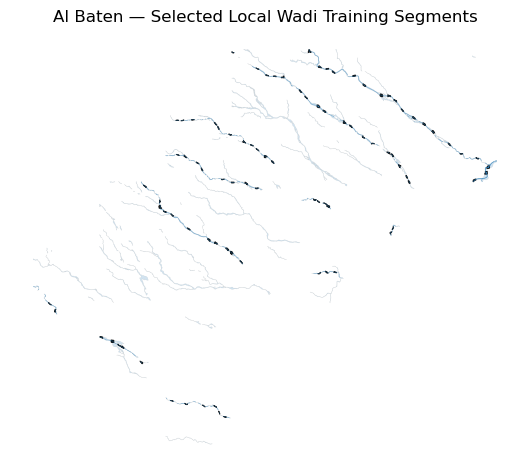

In [298]:
# ============================================================
# STEP 15 — VISUALIZE DRAFT WADI TRAINING SEGMENTS
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)

# Original interpreted Wadi
wadi_parts.plot(
    ax=ax,
    alpha=0.20,
    edgecolor="gray",
    linewidth=0.25
)

# OSM line reference
wadi_guides.plot(
    ax=ax,
    linewidth=0.5,
    alpha=0.45
)

# Selected local Wadi polygons
wadi_draft.plot(
    ax=ax,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.7
)

ax.set_title(
    "Al Baten — Selected Local Wadi Training Segments"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [299]:
# ============================================================
# STEP 16 — EXPORT FOR ARCGIS REVIEW
# ============================================================

ALBATEN_WADI_OUT = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping"
    r"\Al_Baten_Wadi_Training_2025.gpkg"
)

wadi_parts.to_file(
    ALBATEN_WADI_OUT,
    layer="original_wadi_parts",
    driver="GPKG"
)

wadi_guides.to_file(
    ALBATEN_WADI_OUT,
    layer="osm_wadi_guides",
    driver="GPKG"
)

wadi_selected_pts.to_file(
    ALBATEN_WADI_OUT,
    layer="selected_locations",
    driver="GPKG"
)

wadi_windows.to_file(
    ALBATEN_WADI_OUT,
    layer="review_windows",
    driver="GPKG"
)

wadi_draft.to_file(
    ALBATEN_WADI_OUT,
    layer="draft_wadi_segments",
    driver="GPKG"
)

print(
    "Saved:",
    ALBATEN_WADI_OUT
)

Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\Al_Baten_Wadi_Training_2025.gpkg


### Polyline: Waterway
- **final decision**
1. Use **hotosm_mar_waterways_lines_EM.shp** as the single waterway-line reference dataset.
2. Do not **merge OSM_AF_Waterways_EM.shp** into it.
3. Keep **OSM_AF_Waterways_EM.shp** only as an archived/cross-check layer.

- cd: "C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\waterbody
- "hotosm_mar_waterways_lines_EM.shp", 1787 rows
- "hotosm_mar_waterways_polygons_EM.shp", 318 rows
- "OSM_AF_Waterways_EM.shp", 1767 rows, I was wondering how this dataset overlap with hotosm_mar_waterways_lines_EM.shp

- Two OSM-derived waterway line datasets were compared spatially. Because the OSM_AF network was almost completely represented by the HOT OSM network within a 10-m tolerance, the HOT OSM dataset was retained as the canonical drainage reference to avoid duplicate features.

In [216]:
from pathlib import Path
import geopandas as gpd

water_dir = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\waterbody"
)

hot_lines = gpd.read_file(
    water_dir / "hotosm_mar_waterways_lines_EM.shp"
)

osm_af = gpd.read_file(
    water_dir / "OSM_AF_Waterways_EM.shp"
)

print("HOT:", len(hot_lines), hot_lines.crs)
print("OSM_AF:", len(osm_af), osm_af.crs)

print("\nHOT columns:")
print(hot_lines.columns.tolist())

print("\nOSM_AF columns:")
print(osm_af.columns.tolist())

hot_lines = hot_lines.to_crs(work_crs).copy()
osm_af = osm_af.to_crs(work_crs).copy()
print("HOT:", len(hot_lines), hot_lines.crs)
print("OSM_AF:", len(osm_af), osm_af.crs)

HOT: 1787 EPSG:4326
OSM_AF: 1767 EPSG:9707

HOT columns:
['width', 'tunnel', 'natural', 'osm_id', 'Length', 'class', 'geometry']

OSM_AF columns:
['FID_Polyli', 'Name', 'FolderPath', 'Length', 'class', 'geometry']
HOT: 1787 EPSG:32630
OSM_AF: 1767 EPSG:32630


In [226]:
# compare the two datasets geometrically
TOLERANCE_M = 10

af_buffer_union = (
    hot_lines.geometry
    .buffer(TOLERANCE_M)
    # .union_all()
    .unary_union
)

hot_lines["overlap_pct"] = (
    osm_af.geometry
    .intersection(af_buffer_union)
    .length
    /
    hot_lines.geometry.length
    * 100
)

print(
    hot_lines["overlap_pct"]
    .describe(
        percentiles=[
            0.1,
            0.25,
            0.5,
            0.75,
            0.9,
            0.95
        ]
    ).round(1)
)

for threshold in [50, 80, 90, 95]:

    pct = (
        hot_lines["overlap_pct"]
        .ge(threshold)
        .mean()
        * 100
    )

    print(
        f"HOT lines with >= {threshold}% "
        f"geometric match: {pct:.1f}%"
    )

# --------------------------------------------------
# Reciprocal comparison:
# OSM_AF against HOT
# --------------------------------------------------

hot_buffer_union = (
    hot_lines.geometry
    .buffer(TOLERANCE_M)
    .unary_union
)

osm_af["overlap_pct"] = (
    osm_af.geometry
    .intersection(hot_buffer_union)
    .length
    /
    osm_af.geometry.length
    * 100
)

print("\nOSM_AF vs HOT:")
print(
    osm_af["overlap_pct"].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)

count      1767.0
mean       2291.3
std       14537.5
min           0.0
10%           5.4
25%          24.1
50%          99.4
75%         483.1
90%        2038.0
95%        5421.3
max      284690.4
Name: overlap_pct, dtype: float64
HOT lines with >= 50% geometric match: 60.4%
HOT lines with >= 80% geometric match: 52.4%
HOT lines with >= 90% geometric match: 51.0%
HOT lines with >= 95% geometric match: 50.3%

OSM_AF vs HOT:
count    1767.000000
mean       99.631384
std         5.738897
min         0.000000
10%       100.000000
25%       100.000000
50%       100.000000
75%       100.000000
90%       100.000000
95%       100.000000
max       100.000000
Name: overlap_pct, dtype: float64


### Water_polygon
- Attention: Don't use all 318 polygons as Water automatically
- This deserves separate analysis.

water_poly = gpd.read_file(
    water_dir /
    "hotosm_mar_waterways_polygons_EM.shp"
)

print("Records:", len(water_poly))
print(water_poly.columns.tolist())

for col in water_poly.columns:

    if col != "geometry":

        n_unique = water_poly[col].nunique(
            dropna=True
        )

        if n_unique <= 30:

            print("\n", col)

            print(
                water_poly[col]
                .value_counts(dropna=False)
            )

## The rest three datasets
- Use:
**hayat_training_std**
**trophic_training_std**
- or simply:
**field_supplement_combined**


- **Trophic_survey_data_114_station_habitat_26_Eastern_Morocco.shp**
- **Phytosociologicalsurveys_fromHayat_edited.shp**
- also clean/hormilize the Telmet data: **C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\MO_EA_habitat_tamlelt_Merge**

### Tamlelt data to review

```text
Original 275 expert-interpreted polygons
               ↓
     standardize `class`
               ↓
     explode 4 MultiPolygons
               ↓
      separate Wadi
        ↙             ↘
 AREAL HABITATS       WADI
        ↓              ↓
 15 m interior      keep original
 boundary removal   geometry/reference
        ↓
 remove only tiny
 remnants
        ↓
 keep interpreted
 interior polygons
        ↓
 cap pixels later
 during RF sampling

In [343]:
# ============================================================
# TAMLELT FINAL PREPROCESSING FOR PILOT TRAINING
# ============================================================

from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Load
# ------------------------------------------------------------

TAMLELT_PATH = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping"
    r"\MO_EA_habitat_tamlelt_Merge.shp"
)

tamlelt_raw = gpd.read_file(
    TAMLELT_PATH
)

print("Rows:", len(tamlelt_raw))
print("CRS:", tamlelt_raw.crs)

print(
    tamlelt_raw["class"]
    .value_counts(dropna=False)
)

Rows: 275
CRS: EPSG:32630
class
Wadi and gullies    169
Bare rocky           92
Spreading area        7
Water body            4
Sand                  3
Name: count, dtype: int64


In [344]:
# Step 2 — Keep useful fields
TAMLELT_KEEP = [
    "class",
    "geometry"
]

tamlelt = tamlelt_raw[
    [
        c for c in TAMLELT_KEEP
        if c in tamlelt_raw.columns
    ]
].copy()

In [345]:
# Step 3 — Harmonize the class field
tamlelt["class_raw"] = (
    tamlelt["class"]
    .astype("string")
    .str.strip()
)

TAMLELT_CLASS_MAP = {
    "Wadi and gullies":
        "Wadi and gullies",

    "Bare rocky":
        "Bare rocky",

    "Spreading area":
        "Spreading area",

    "Water body":
        "Water body",

    "Sand":
        "Dune"
}

tamlelt["class"] = (
    tamlelt["class_raw"]
    .map(TAMLELT_CLASS_MAP)
)

In [346]:
print(
    "Unmapped records:",
    tamlelt["class"].isna().sum()
)

print(
    "\nFinal classes:"
)

print(
    tamlelt["class"]
    .value_counts()
)

Unmapped records: 0

Final classes:
class
Wadi and gullies    169
Bare rocky           92
Spreading area        7
Water body            4
Dune                  3
Name: count, dtype: int64


In [347]:
# Step 4 — Project to the common working CRS
tamlelt = (
    tamlelt
    .to_crs(work_crs) #EPSG:32630
    .copy()
)

In [348]:
# Step 5 — Preserve original feature IDs before exploding
tamlelt = (
    tamlelt
    .reset_index(drop=True)
)

tamlelt["orig_id"] = [
    f"TAM_ORIG_{i:04d}"
    for i in range(
        1,
        len(tamlelt) + 1
    )
]

In [349]:
tamlelt_parts = (
    tamlelt
    .explode(
        index_parts=False
    )
    .reset_index(drop=True)
)

tamlelt_parts["part_id"] = [
    f"TAM_PART_{i:04d}"
    for i in range(
        1,
        len(tamlelt_parts) + 1
    )
]

tamlelt_parts["source_area_m2"] = (
    tamlelt_parts.geometry.area
)

print(
    "Original records:",
    len(tamlelt)
)

print(
    "After explode:",
    len(tamlelt_parts)
)

print(
    "\nAfter explode by class:"
)

print(
    tamlelt_parts["class"]
    .value_counts()
)

Original records: 275
After explode: 314

After explode by class:
class
Wadi and gullies    169
Bare rocky           92
Dune                 37
Spreading area       12
Water body            4
Name: count, dtype: int64


In [350]:
# Step 6 — Separate Wadi, Water, and normal areal habitats
tamlelt_wadi = tamlelt_parts[
    tamlelt_parts["class"]
    == "Wadi and gullies"
].copy()


tamlelt_water = tamlelt_parts[
    tamlelt_parts["class"]
    == "Water body"
].copy()


tamlelt_areal = tamlelt_parts[
    tamlelt_parts["class"]
    .isin(
        [
            "Bare rocky",
            "Spreading area",
            "Dune"
        ]
    )
].copy()

In [351]:
# Step 7 — Bare rocky / Spreading / Dune: 15 m safe interiors
EDGE_BUFFER_M = 15

tamlelt_areal_core = (
    tamlelt_areal.copy()
)

tamlelt_areal_core["geometry"] = (
    tamlelt_areal_core
    .geometry
    .buffer(
        -EDGE_BUFFER_M
    )
)

In [352]:
# Remove empty/invalid remnants:
geom_ok = (
    tamlelt_areal_core
    .geometry
    .apply(
        lambda g:
            g is not None
            and not g.is_empty
            and g.is_valid
    )
)

tamlelt_areal_core = (
    tamlelt_areal_core[
        geom_ok
    ]
    .copy()
)

tamlelt_areal_core["poly_area"] = (
    tamlelt_areal_core
    .geometry
    .area
)

In [353]:
# Use a relatively permissive minimum because rare classes are important:
MIN_CORE_AREA_M2 = 400

tamlelt_areal_core = (
    tamlelt_areal_core[
        tamlelt_areal_core[
            "poly_area"
        ]
        >= MIN_CORE_AREA_M2
    ]
    .copy()
)

In [354]:
# Step 8: Wadi: preserve the interpreted polygons
tamlelt_wadi["poly_area"] = (
    tamlelt_wadi.geometry.area
)

# Keep useful polygons:
# Tamlelt Wadi
# already expert-digitized local polygon
# → retain geometry
# → cap training pixels later
MIN_WADI_AREA_M2 = 400

tamlelt_wadi_core = (
    tamlelt_wadi[
        tamlelt_wadi["poly_area"]
        >= MIN_WADI_AREA_M2
    ]
    .copy()
)

In [355]:
# 9. Water body: retain carefully
tamlelt_water_core = (
    tamlelt_water.copy()
)

tamlelt_water_core["poly_area"] = (
    tamlelt_water_core.geometry.area
)

# For the pilot, retain them if they have meaningful area:
MIN_WATER_AREA_M2 = 200

tamlelt_water_core = (
    tamlelt_water_core[
        tamlelt_water_core[
            "poly_area"
        ]
        >= MIN_WATER_AREA_M2
    ]
    .copy()
)


In [356]:
# 10. Combine the three Tamlelt branches
tamlelt_candidates = (
    gpd.GeoDataFrame(
        pd.concat(
            [
                tamlelt_areal_core,
                tamlelt_wadi_core,
                tamlelt_water_core
            ],
            ignore_index=True
        ),
        geometry="geometry",
        crs=work_crs
    )
)

In [357]:
# 11. Add standardized metadata
tamlelt_candidates = (
    tamlelt_candidates
    .reset_index(drop=True)
)

tamlelt_candidates["sample_id"] = [
    f"TAM_{i:04d}"
    for i in range(
        1,
        len(tamlelt_candidates) + 1
    )
]

tamlelt_candidates["site_id"] = (
    "TAM_"
    +
    tamlelt_candidates[
        "part_id"
    ].astype(str)
)

tamlelt_candidates["source_id"] = (
    tamlelt_candidates[
        "part_id"
    ]
    .astype("string")
)

tamlelt_candidates["class_id"] = (
    tamlelt_candidates[
        "class"
    ]
    .map(CLASS_DICT)
)

tamlelt_candidates["source"] = (
    "TAMLELT_INTERPRETED_MAP"
)

tamlelt_candidates["ref_year"] = pd.NA

tamlelt_candidates["field_sup"] = 0

tamlelt_candidates["confidence"] = 3

tamlelt_candidates["qc_status"] = (
    "PILOT_UNREVIEWED"
)

tamlelt_candidates["use_status"] = (
    "CANDIDATE"
)

In [358]:
# Set the geometry rule according to class:
tamlelt_candidates["geom_rule"] = (
    "INTERPRETED_POLYGON"
)

tamlelt_candidates.loc[
    tamlelt_candidates["class"]
    .isin(
        [
            "Bare rocky",
            "Spreading area",
            "Dune"
        ]
    ),
    "geom_rule"
] = "INTERPRETED_POLYGON_15M_CORE"


tamlelt_candidates.loc[
    tamlelt_candidates["class"]
    == "Wadi and gullies",
    "geom_rule"
] = "INTERPRETED_WADI_POLYGON"


tamlelt_candidates.loc[
    tamlelt_candidates["class"]
    == "Water body",
    "geom_rule"
] = "INTERPRETED_WATER_POLYGON"


In [359]:
# Recalculate final polygon area:
tamlelt_candidates["poly_area"] = (
    tamlelt_candidates.geometry.area
)

# Assign 20-km grid:
tamlelt_candidates = assign_grid(
    tamlelt_candidates,
    field_grid
)

In [360]:
# 12. Final Tamlelt summary
tamlelt_summary = (
    tamlelt_candidates
    .groupby("class")
    .agg(
        n_polygons=(
            "sample_id",
            "size"
        ),

        n_sites=(
            "site_id",
            "nunique"
        ),

        n_grids=(
            "grid_id",
            "nunique"
        ),

        total_area_m2=(
            "poly_area",
            "sum"
        ),

        median_area_m2=(
            "poly_area",
            "median"
        )
    )
    .sort_values(
        "n_polygons",
        ascending=False
    )
)

display(
    tamlelt_summary.round(1)
)

,n_polygons,n_sites,n_grids,total_area_m2,median_area_m2
class,,,,,
Wadi and gullies,169,169,2,1290333.2,4693.1
Bare rocky,79,79,2,8687128.8,34218.4
Dune,19,19,2,1809204.7,2846.6
Spreading area,11,11,2,5838973.9,38043.3
Water body,4,4,2,1244111.3,315815.2


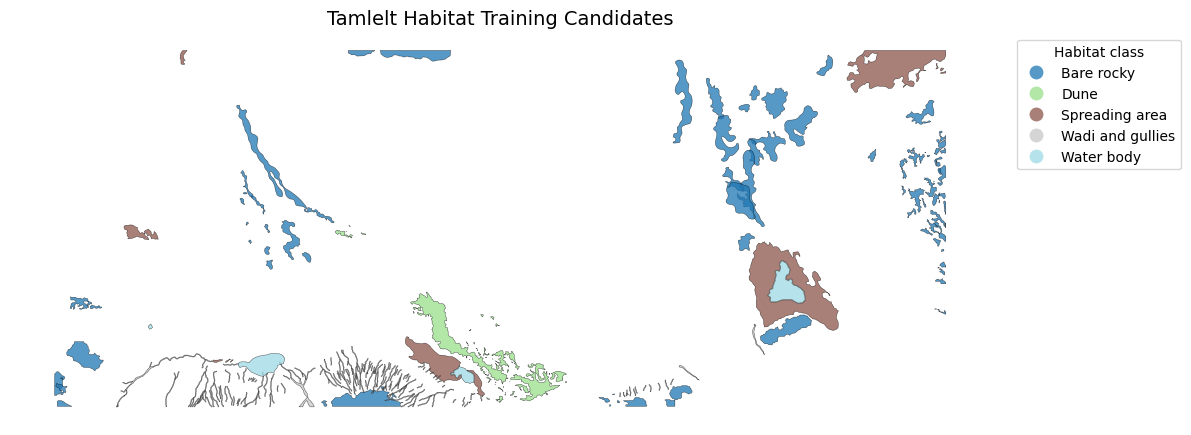

In [361]:
# 13. Visualize
fig, ax = plt.subplots(
    figsize=(12, 10)
)

tamlelt_candidates.plot(
    ax=ax,
    column="class",
    categorical=True,
    cmap="tab20",
    legend=True,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        "title":
            "Habitat class",

        "bbox_to_anchor":
            (1.02, 1),

        "loc":
            "upper left"
    }
)

ax.set_title(
    "Tamlelt Habitat Training Candidates",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [362]:
# 14. Export merge-ready Tamlelt candidates
TAMLELT_OUT = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping"
    r"\Tamlelt_Training_2025.gpkg"
)

if TAMLELT_OUT.exists():
    TAMLELT_OUT.unlink()

In [363]:
tamlelt_candidates.to_file(
    TAMLELT_OUT,
    layer="training_candidates",
    driver="GPKG"
)

tamlelt_summary.to_csv(
    TAMLELT_OUT.with_name(
        "Tamlelt_Training_2025_summary.csv"
    )
)

print("Saved:")
print(TAMLELT_OUT)

Saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\Tamlelt_Training_2025.gpkg


### Points data to polygons and harmonize: Hayat and trophic

In [305]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

BASE = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
)

HAYAT_PATH = (
    BASE
    / r"Reneco\GIS Data\Extract data Yuwen\Shapefiles"
    / r"Habitat Mapping Shapefiles"
    / "Phytosociologicalsurveys_fromHayat_edited.shp"
)

TROPHIC_PATH = (
    BASE
    / r"Reneco\Vegetation Cover and Food Availability Studies"
    / "Trophic_survey_data_114_station_habitat_26_Eastern_Morocco.shp"
)

hayat_raw = gpd.read_file(HAYAT_PATH)
trophic_raw = gpd.read_file(TROPHIC_PATH)

for name, gdf in {
    "HAYAT": hayat,
    "TROPHIC": trophic
}.items():

    print("\n" + "=" * 70)
    print(name)

    print("Rows:", len(gdf))
    print("CRS:", gdf.crs)

    print("\nGeometry:")
    print(
        gdf.geometry.geom_type
        .value_counts(dropna=False)
    )

    print("\nColumns:")
    print(gdf.columns.tolist())


HAYAT
Rows: 62
CRS: EPSG:4326

Geometry:
Point    62
Name: count, dtype: int64

Columns:
['Lat', 'Lon', 'year', 'Station_na', 'Habitat', 'Remarque', 'class', 'geometry']

TROPHIC
Rows: 101
CRS: EPSG:4326

Geometry:
Point    101
Name: count, dtype: int64

Columns:
['Station', 'Lat', 'Lon', 'Code', 'Habitat_Fr', 'Habitat', 'Habitat_f1', 'Habitat_f2', 'class', 'Work_area', 'Sub_area', 'Approach', 'Habitat_en', 'Habitat_2_', 'geometry']


In [306]:
# ============================================================
# CLEAN HAYAT + TROPHIC FIELD POINT DATA
# AND CONVERT TO PILOT TRAINING POLYGONS
# ============================================================

import geopandas as gpd
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Keep only useful fields
# ------------------------------------------------------------

HAYAT_KEEP = [
    "Station_na",
    "Lat",
    "Lon",
    "year",
    "class",
    "geometry"
]

TROPHIC_KEEP = [
    "Station",
    "Lat",
    "Lon",
    "Code",
    "class",
    "Work_area",
    "Sub_area",
    "geometry"
]


hayat_clean = (
    hayat_raw[HAYAT_KEEP]
    .copy()
)

trophic_clean = (
    trophic_raw[TROPHIC_KEEP]
    .copy()
)

In [307]:
# ============================================================
# CLASS STANDARDIZATION
# ============================================================

FIELD_CLASS_FIXES = {

    # confirmed typo in Hayat
    "Cutlivated field/fallow":
        "Cultivated field/fallow",

    # known terminology variants
    "Open woodland":
        "Wooded steppe",

    "Wadi & gullies":
        "Wadi and gullies",
}


def clean_class_field(series):

    out = (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
    )

    out = out.replace(
        FIELD_CLASS_FIXES
    )

    return out

In [308]:
for gdf in [
    hayat_clean,
    trophic_clean
]:

    gdf["class_raw"] = (
        gdf["class"]
        .astype("string")
        .str.strip()
    )

    gdf["class"] = (
        clean_class_field(
            gdf["class"]
        )
    )

In [309]:
print("=" * 60)
print("HAYAT")

print(
    hayat_clean[
        ["class_raw", "class"]
    ]
    .value_counts()
)


print("\n" + "=" * 60)
print("TROPHIC")

print(
    trophic_clean[
        ["class_raw", "class"]
    ]
    .value_counts()
)

HAYAT
class_raw                class                  
Grass steppe             Grass steppe               19
Wooded steppe            Wooded steppe              12
Shrub steppe             Shrub steppe               11
Dune                     Dune                        6
Cutlivated field/fallow  Cultivated field/fallow     4
Water body               Water body                  4
Wadi and gullies         Wadi and gullies            3
Spreading area           Spreading area              2
Bare rocky               Bare rocky                  1
Name: count, dtype: int64

TROPHIC
class_raw         class           
Shrub steppe      Shrub steppe        62
Grass steppe      Grass steppe        15
Wadi and gullies  Wadi and gullies    10
Spreading area    Spreading area       9
Salty steppe      Salty steppe         5
Name: count, dtype: int64


In [310]:
# Then check against your final legend:
FINAL_CLASSES = set(
    CLASS_DICT.keys()
)


def check_classes(
    gdf,
    name
):

    bad = sorted(
        set(
            gdf.loc[
                ~gdf["class"]
                .isin(FINAL_CLASSES),
                "class"
            ]
            .dropna()
            .astype(str)
        )
    )

    if bad:

        print(
            f"{name}: UNMAPPED CLASSES"
        )

        for x in bad:
            print("  -", x)

    else:

        print(
            f"{name}: all classes valid."
        )


check_classes(
    hayat_clean,
    "HAYAT"
)

check_classes(
    trophic_clean,
    "TROPHIC"
)

HAYAT: all classes valid.
TROPHIC: all classes valid.


In [311]:
# ============================================================
# PROJECT TO METRIC CRS
# ============================================================

hayat_poly = (
    hayat_clean
    .to_crs(work_crs)
    .copy()
)

trophic_poly = (
    trophic_clean
    .to_crs(work_crs)
    .copy()
)

In [312]:
# ============================================================
# POINT -> PILOT POLYGON
# ============================================================

BUFFER_M = 10


hayat_poly["geometry"] = (
    hayat_poly.geometry
    .buffer(BUFFER_M)
)


trophic_poly["geometry"] = (
    trophic_poly.geometry
    .buffer(BUFFER_M)
)

In [314]:
# check
print(
    hayat_poly.geometry
    .geom_type
    .value_counts()
)

print(
    trophic_poly.geometry
    .geom_type
    .value_counts()
)

Polygon    62
Name: count, dtype: int64
Polygon    101
Name: count, dtype: int64


In [318]:
# ============================================================
# Add standardized Hayat metadata
# ============================================================

hayat_poly = (
    hayat_poly
    .reset_index(drop=True)
)

hayat_poly["sample_id"] = [
    f"HAY_{i:04d}"
    for i in range(
        1,
        len(hayat_poly) + 1
    )
]

hayat_poly["source_id"] = (
    hayat_poly["Station_na"]
    .astype("string")
)

hayat_poly["site_id"] = (
    "HAY_"
    +
    hayat_poly["Station_na"]
    .astype("string")
)

hayat_poly["class_id"] = (
    hayat_poly["class"]
    .map(CLASS_DICT)
)

hayat_poly["source"] = (
    "HAYAT_PHYTO"
)

# Hayat has a year field
hayat_poly["ref_year"] = (
    pd.to_numeric(
        hayat_poly["year"],
        errors="coerce"
    )
)

hayat_poly["field_sup"] = 1

hayat_poly["confidence"] = 2

hayat_poly["geom_rule"] = (
    "POINT_BUFFER_10M_PILOT"
)

hayat_poly["qc_status"] = (
    "PILOT_UNREVIEWED"
)

hayat_poly["use_status"] = (
    "CANDIDATE"
)

hayat_poly["poly_area"] = (
    hayat_poly.geometry.area
)

# Assign grid:
hayat_poly = assign_grid(
    hayat_poly,
    field_grid
)

In [317]:
# same thing for Trophic
# ============================================================
# TROPHIC METADATA
# ============================================================

trophic_poly = (
    trophic_poly
    .reset_index(drop=True)
)

trophic_poly["sample_id"] = [
    f"TRO_{i:04d}"
    for i in range(
        1,
        len(trophic_poly) + 1
    )
]

trophic_poly["source_id"] = (
    trophic_poly["Station"]
    .astype("string")
)

trophic_poly["site_id"] = (
    "TRO_"
    +
    trophic_poly["Station"]
    .astype("string")
)

trophic_poly["class_id"] = (
    trophic_poly["class"]
    .map(CLASS_DICT)
)

trophic_poly["source"] = (
    "TROPHIC_SURVEY"
)

# No explicit year field here
trophic_poly["ref_year"] = pd.NA

trophic_poly["field_sup"] = 1

trophic_poly["confidence"] = 2

trophic_poly["geom_rule"] = (
    "POINT_BUFFER_10M_PILOT"
)

trophic_poly["qc_status"] = (
    "PILOT_UNREVIEWED"
)

trophic_poly["use_status"] = (
    "CANDIDATE"
)

trophic_poly["poly_area"] = (
    trophic_poly.geometry.area
)

# Assign grid:
trophic_poly = assign_grid(
    trophic_poly,
    field_grid
)

In [319]:
# 8. Inspect their final class contributions
print("=" * 60)
print("HAYAT")

print(
    hayat_poly["class"]
    .value_counts()
)


print("\n" + "=" * 60)
print("TROPHIC")

print(
    trophic_poly["class"]
    .value_counts()
)

HAYAT
class
Grass steppe               19
Wooded steppe              12
Shrub steppe               11
Dune                        6
Water body                  4
Cultivated field/fallow     4
Wadi and gullies            3
Spreading area              2
Bare rocky                  1
Name: count, dtype: Int64

TROPHIC
class
Shrub steppe        62
Grass steppe        15
Wadi and gullies    10
Spreading area       9
Salty steppe         5
Name: count, dtype: Int64


In [320]:
# And geographic coverage:
print(
    "\nHayat grids:",
    hayat_poly["grid_id"]
    .nunique()
)

print(
    "Trophic grids:",
    trophic_poly["grid_id"]
    .nunique()
)


Hayat grids: 7
Trophic grids: 19


In [322]:
# 9. Reduce them to the common master-training schema
# Since the master dataset does not really need Lat, Lon, Work_area, etc., use your existing helper:
MASTER_FIELDS = [
    "sample_id",
    "site_id",
    "source_id",
    "class_raw",
    "class",
    "class_id",
    "source",
    "ref_year",
    "field_sup",
    "confidence",
    "geom_rule",
    "grid_id",
    "qc_status",
    "use_status",
    "poly_area",
    "geometry"
]


def final_schema(gdf):
    """
    Reduce any harmonized training source to the common
    master-training schema.
    """

    out = gdf.copy()

    for col in MASTER_FIELDS:

        if col not in out.columns:
            out[col] = pd.NA

    return (
        out[MASTER_FIELDS]
        .copy()
    )
    
hayat_std = final_schema(
    hayat_poly
)

trophic_std = final_schema(
    trophic_poly
)

print("Hayat standardized:", len(hayat_std))
print("Trophic standardized:", len(trophic_std))

print("\nCommon fields:")
print(hayat_std.columns.tolist())

Hayat standardized: 62
Trophic standardized: 101

Common fields:
['sample_id', 'site_id', 'source_id', 'class_raw', 'class', 'class_id', 'source', 'ref_year', 'field_sup', 'confidence', 'geom_rule', 'grid_id', 'qc_status', 'use_status', 'poly_area', 'geometry']


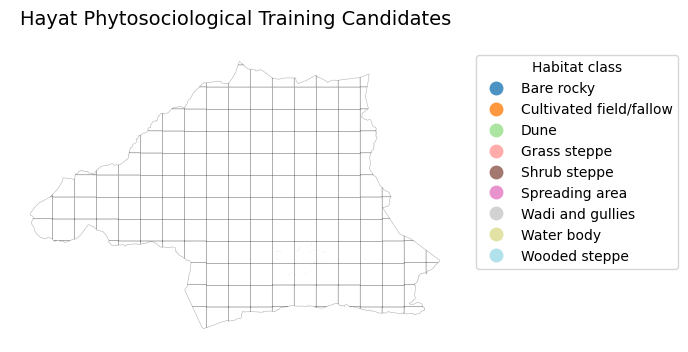

In [325]:
# ============================================================
# STEP 10A — VISUALIZE HAYAT
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(7, 5)
)

# Regional 20 x 20 km grid
field_grid.boundary.plot(
    ax=ax,
    linewidth=0.4,
    color='black',
    alpha=0.3
)

# Hayat polygons
hayat_poly.plot(
    ax=ax,
    column="class",
    categorical=True,
    cmap="tab20",
    legend=True,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.4,
    legend_kwds={
        "title": "Habitat class",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Hayat Phytosociological Training Candidates",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

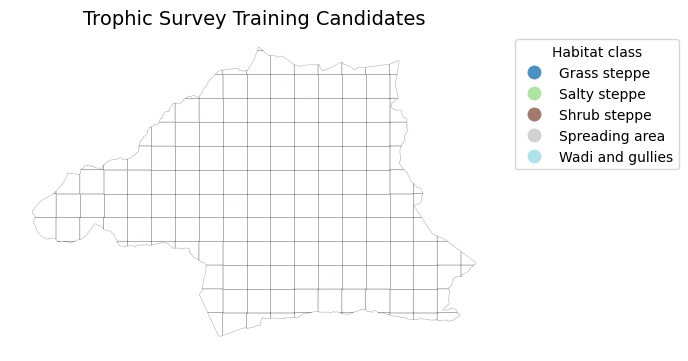

In [326]:
# ============================================================
# STEP 10B — VISUALIZE TROPHIC
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)

field_grid.boundary.plot(
    ax=ax,
    linewidth=0.4,
    color='black',
    alpha=0.3
)

trophic_poly.plot(
    ax=ax,
    column="class",
    categorical=True,
    cmap="tab20",
    legend=True,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.4,
    legend_kwds={
        "title": "Habitat class",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Trophic Survey Training Candidates",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [327]:
# ============================================================
# STEP 10C — COMBINED FIELD-SUPPORTED DATASET
# ============================================================

field_supplement = gpd.GeoDataFrame(
    pd.concat(
        [
            hayat_std,
            trophic_std
        ],
        ignore_index=True
    ),
    geometry="geometry",
    crs=work_crs
)

print(
    "Combined field-supported polygons:",
    len(field_supplement)
)

Combined field-supported polygons: 163


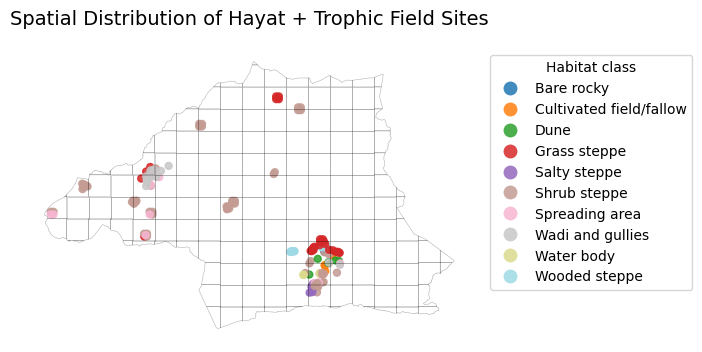

In [329]:
field_supplement_pts = (
    field_supplement.copy()
)

field_supplement_pts["geometry"] = (
    field_supplement_pts.geometry
    .representative_point()
)

fig, ax = plt.subplots(
    figsize=(7, 5)
)

field_grid.boundary.plot(
    ax=ax,
    linewidth=0.4,
    color='black',
    alpha=0.3
)

field_supplement_pts.plot(
    ax=ax,
    column="class",
    categorical=True,
    cmap="tab20",
    legend=True,
    markersize=25,
    alpha=0.85,
    legend_kwds={
        "title": "Habitat class",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Spatial Distribution of Hayat + Trophic Field Sites",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [330]:
# ============================================================
# STEP 11 — SUMMARY
# ============================================================

field_summary = (
    field_supplement
    .groupby(
        [
            "source",
            "class"
        ]
    )
    .agg(
        n_polygons=("sample_id", "size"),
        n_sites=("site_id", "nunique"),
        n_grids=("grid_id", "nunique"),
        total_area_m2=("poly_area", "sum"),
        median_area_m2=("poly_area", "median")
    )
    .reset_index()
)

display(
    field_summary.round(1)
)

,source,class,n_polygons,n_sites,n_grids,total_area_m2,median_area_m2
0,HAYAT_PHYTO,Bare rocky,1,1,1,313.7,313.7
1,HAYAT_PHYTO,Cultivated field/fallow,4,3,2,1254.6,313.7
2,HAYAT_PHYTO,Dune,6,4,3,1881.9,313.7
3,HAYAT_PHYTO,Grass steppe,19,2,2,5959.4,313.7
4,HAYAT_PHYTO,Shrub steppe,11,2,6,3450.2,313.7
5,HAYAT_PHYTO,Spreading area,2,2,2,627.3,313.7
6,HAYAT_PHYTO,Wadi and gullies,3,3,2,941.0,313.7
7,HAYAT_PHYTO,Water body,4,0,2,1254.6,313.7
8,HAYAT_PHYTO,Wooded steppe,12,0,2,3763.9,313.7
9,TROPHIC_SURVEY,Grass steppe,15,15,7,4704.8,313.7


In [331]:
# And class totals across both:
field_class_summary = (
    field_supplement
    .groupby("class")
    .agg(
        n_polygons=("sample_id", "size"),
        n_sites=("site_id", "nunique"),
        n_sources=("source", "nunique"),
        n_grids=("grid_id", "nunique")
    )
    .sort_values(
        "n_sites",
        ascending=False
    )
)

display(
    field_class_summary
)

,n_polygons,n_sites,n_sources,n_grids
class,,,,
Shrub steppe,73,64,2,19
Grass steppe,34,17,2,8
Wadi and gullies,13,13,2,6
Spreading area,11,11,2,7
Salty steppe,5,5,1,2
Dune,6,4,1,3
Cultivated field/fallow,4,3,1,2
Bare rocky,1,1,1,1
Water body,4,0,1,2


In [332]:
# ============================================================
# STEP 12 — EXPORT
# ============================================================

from pathlib import Path

FIELD_OUT = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping"
    r"\Field_Supplement_Training_2025.gpkg"
)

# Start fresh if rerunning
if FIELD_OUT.exists():
    FIELD_OUT.unlink()

In [333]:
# Export full versions first:
hayat_poly.to_file(
    FIELD_OUT,
    layer="hayat_harmonized",
    driver="GPKG"
)

trophic_poly.to_file(
    FIELD_OUT,
    layer="trophic_harmonized",
    driver="GPKG"
)

In [334]:
# Export merge-ready versions:
hayat_std.to_file(
    FIELD_OUT,
    layer="hayat_training_std",
    driver="GPKG"
)

trophic_std.to_file(
    FIELD_OUT,
    layer="trophic_training_std",
    driver="GPKG"
)

In [335]:
# And combined layer:
field_supplement.to_file(
    FIELD_OUT,
    layer="field_supplement_combined",
    driver="GPKG"
)

In [336]:
# Save summaries:
field_summary.to_csv(
    FIELD_OUT.with_name(
        "Field_Supplement_Training_2025_source_summary.csv"
    ),
    index=False
)

field_class_summary.to_csv(
    FIELD_OUT.with_name(
        "Field_Supplement_Training_2025_class_summary.csv"
    )
)

print("Saved:")
print(FIELD_OUT)

print("\nLayers:")
print("  hayat_harmonized")
print("  trophic_harmonized")
print("  hayat_training_std")
print("  trophic_training_std")
print("  field_supplement_combined")

Saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\Field_Supplement_Training_2025.gpkg

Layers:
  hayat_harmonized
  trophic_harmonized
  hayat_training_std
  trophic_training_std
  field_supplement_combined


# Finally merge

In [420]:
cfg = mt.FinalMergeConfig()

paths = {
    "Phytosociological":
        cfg.phyto_path,

    "Hayat + Trophic":
        cfg.field_supplement_path,

    "Cultivated":
        cfg.cultivated_path,

    "Built-up":
        cfg.builtup_path,

    "Al Baten areal":
        cfg.albaten_areal_path,

    "Al Baten Wadi":
        cfg.albaten_wadi_path,

    "Tamlelt":
        cfg.tamlelt_path,

    "Grid":
        cfg.grid_path,

    "Waterways":
        cfg.waterways_path
}


print("=" * 80)
print("FINAL INPUT PATH CHECK")
print("=" * 80)

for name, path in paths.items():

    status = (
        "OK"
        if path.exists()
        else "MISSING"
    )

    print(
        f"{status:8s} | "
        f"{name:22s} | "
        f"{path}"
    )

FINAL INPUT PATH CHECK
OK       | Phytosociological      | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Eastern_Morocco_Field_Footprints.gpkg
OK       | Hayat + Trophic        | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\Field_Supplement_Training_2025.gpkg
OK       | Cultivated             | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Eastern_Morocco_Cultivated_Training_2024.gpkg
OK       | Built-up               | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg
OK       | Al Baten areal         | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\Al_Baten_Training_2025.gpkg
OK       | Al Baten Wadi          | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\

EASTERN MOROCCO - FINAL TRAINING DATA MERGE
Working CRS: EPSG:32630
20-km grid cells: 160

[1/9] Phytosociological footprints
    retained: 1246

[2/9] Hayat field supplement
    retained: 62

[3/9] Trophic field supplement
    retained: 101

[4/9] Reviewed Al Baten cultivated polygons
    retained: 153

[5/9] Reviewed Bouarfa 2024 cultivated polygons
    retained: 606

[6/9] HOT OSM built-up candidates
    retained: 107

[7/9] Al Baten areal habitat candidates
    retained: 789

[8/9] Al Baten Wadi candidates
    retained: 89

[9/9] Tamlelt interpreted habitat candidates
    retained: 282

FINAL MERGE SUMMARY

Source counts:
  PHYTOSOC                             1246
  HAYAT_PHYTO                            62
  TROPHIC_SURVEY                        101
  ALBATEN_FARMS_2024                    153
  BOUARFA_ANTHRO_2024                   606
  HOT_OSM_BUILDINGS                     107
  ALBATEN_INTERPRETED_MAP               789
  ALBATEN_INTERPRETED_MAP_WADI           89
  TAMLELT_INTE

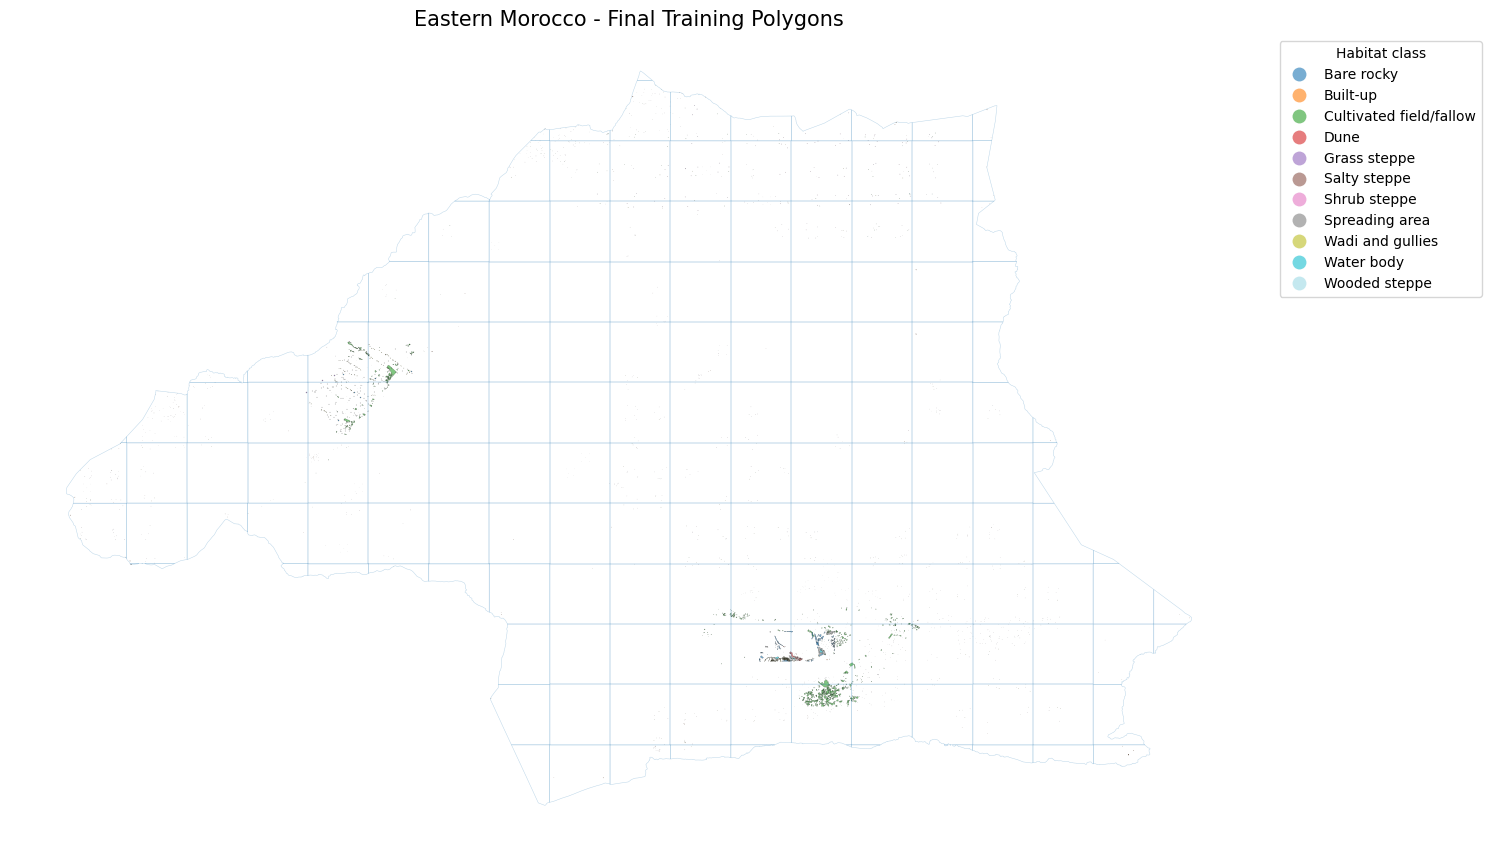

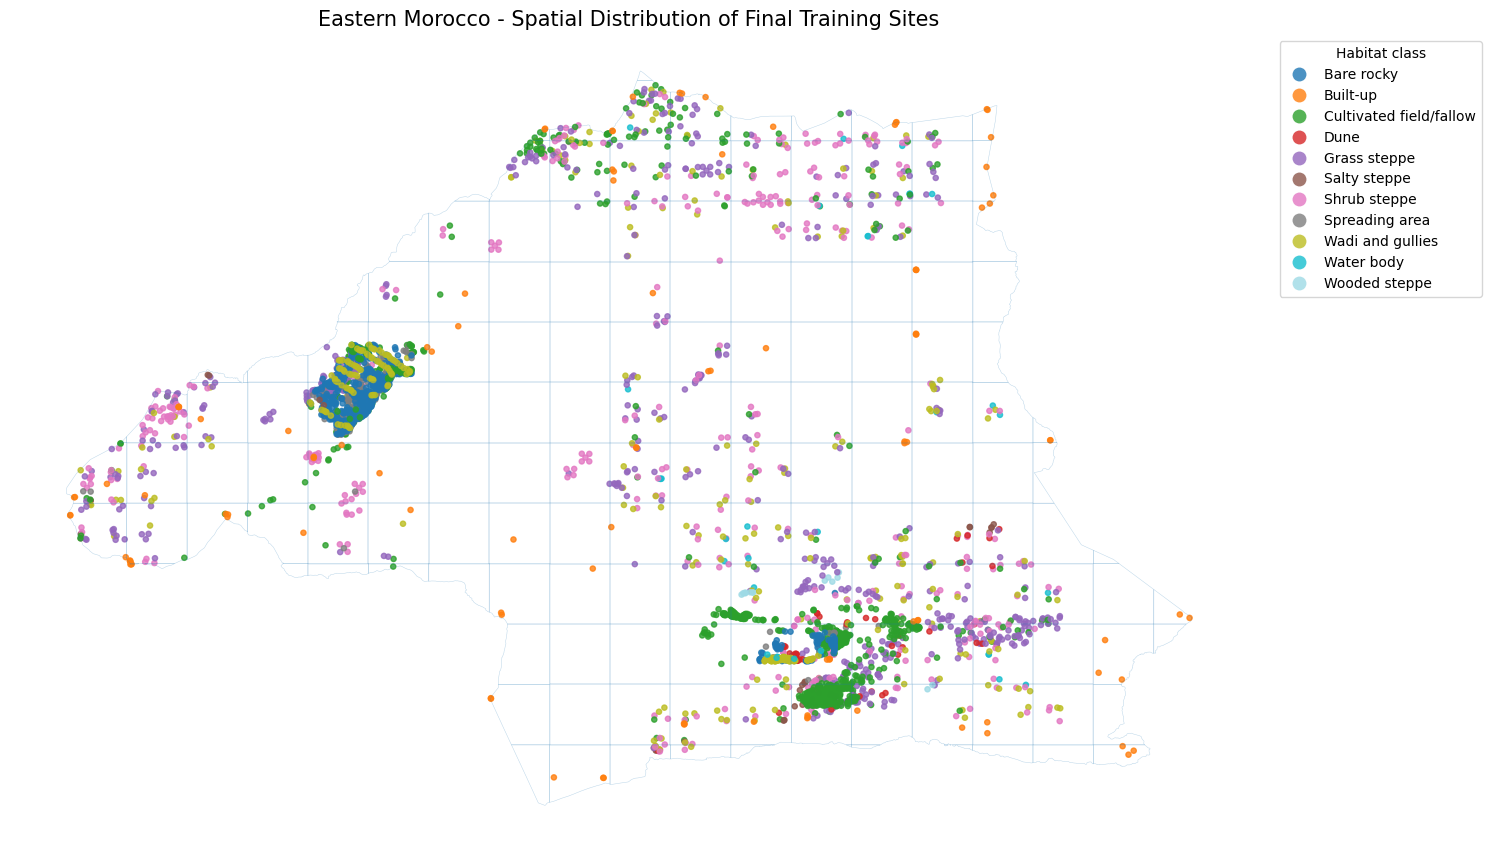

In [419]:
import importlib
import merge_eastern_morocco_training_final_v2 as mt

importlib.reload(mt)

result = mt.build_final_training(
    conflict_policy="flag_only",
    export=True,
    make_plots=True
)

In [426]:
result.keys()

dict_keys(['training_final', 'training_all_flagged', 'class_summary', 'source_summary', 'conflicts', 'grid', 'waterways', 'source_counts', 'config'])

In [425]:
training_final = result["training_final"]

training_all = result["training_all_flagged"]

class_summary = result["class_summary"]

source_summary = result["source_summary"]

conflicts = result["conflicts"]

In [432]:
display(class_summary.round(1))

,n_polygons,n_sites,n_sources,n_grids,total_area_m2,median_area_m2
class,,,,,,
Cultivated field/fallow,1031,1011,5,68,58312895.1,18799.3
Grass steppe,552,503,4,70,1249463.3,1600.0
Wadi and gullies,461,460,5,68,2944563.1,3993.6
Bare rocky,568,407,4,7,9467391.2,1600.0
Shrub steppe,400,389,3,78,1064921.0,1747.2
Spreading area,183,140,5,10,6099921.7,1600.0
Built-up,107,107,1,53,484485.2,2717.3
Dune,52,52,3,14,1853318.7,1497.6
Water body,39,39,3,19,1318388.4,1597.4


In [430]:
training_final.head()

,sample_id,site_id,source_id,class_raw,class,class_id,source,ref_year,field_sup,confidence,geom_rule,grid_id,source_qc_status,source_use_status,qc_status,use_status,poly_area,conflict_flag,geometry
0,PHY_00001,PHY_34883,34883,Grass steppe,Grass steppe,0,PHYTOSOC,<NA>,1,2,AREA_EQUIV_BUFFER,G113,<NA>,<NA>,FINAL_READY,TRAIN,119.807327,0,"POLYGON ((576812.723 3583027.571, 576812.693 3..."
1,PHY_00002,PHY_100281,100281,Water body,Water body,9,PHYTOSOC,<NA>,1,2,AREA_EQUIV_BUFFER,G137,<NA>,<NA>,FINAL_READY,TRAIN,119.807327,0,"POLYGON ((620993.546 3587338.083, 620993.516 3..."
2,PHY_00003,PHY_176637,176637,Wadi and gullies,Wadi and gullies,7,PHYTOSOC,<NA>,1,2,AREA_EQUIV_BUFFER,G126,<NA>,<NA>,FINAL_READY,TRAIN,149.759159,0,"POLYGON ((602207.934 3597474.787, 602207.901 3..."
3,PHY_00004,PHY_74289,74289,Grass steppe,Grass steppe,0,PHYTOSOC,<NA>,1,2,AREA_EQUIV_BUFFER,G100,<NA>,<NA>,FINAL_READY,TRAIN,149.759159,0,"POLYGON ((574108.155 3571731.841, 574108.122 3..."
4,PHY_00005,PHY_81553,81553,Water body,Water body,9,PHYTOSOC,<NA>,1,2,AREA_EQUIV_BUFFER,G110,<NA>,<NA>,FINAL_READY,TRAIN,149.759159,0,"POLYGON ((572938.688 3757982.676, 572938.655 3..."
